# Predictive Maintenance on C-MAPSS (PyTorch)
- Hybrid regression model
- Multi-condition scaling with KMeans clustering

## 0. Imports & Seeds

In [1]:
%pip install captum -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 12.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import subprocess, sys
try:
    from captum.attr import IntegratedGradients, LayerGradCam
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'captum', '-q'])
    from captum.attr import IntegratedGradients, LayerGradCam

In [3]:
SEED = 42

def reset_seeds(seed_value=42):
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

reset_seeds(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


## 1. Column Names & Feature Selection

In [4]:
index_names   = ['unit_number', 'time_in_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names  = ['s_{}'.format(i) for i in range(1, 22)]
col_names     = index_names + setting_names + sensor_names

features = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9',
            's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

path = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/'

## 2. Dataset Configurations

In [5]:
# Huber loss with delta=15 for multi-condition datasets 
DATASET_CONFIGS = {
    'FD001': {
        'multi_condition': False, 'n_clusters': 1, 'alpha': 0.1,
        'seq_length': 30, 'batch_size': 32, 'loss_func': 'huber'
    },
    'FD002': {
        'multi_condition': True, 'n_clusters': 6, 'alpha': 0.1,
        'seq_length': 30, 'batch_size': 128, 'loss_func': 'huber'
    },
    'FD003': {
        'multi_condition': False, 'n_clusters': 1, 'alpha': 0.1,
        'seq_length': 30, 'batch_size': 32, 'loss_func': 'huber'
    },
    'FD004': {
        'multi_condition': True, 'n_clusters': 6, 'alpha': 0.1,
        'seq_length': 30, 'batch_size': 128, 'loss_func': 'huber'
    },
}

## 3. Data Loading & Preprocessing Functions

In [6]:
def load_data(dataset_name):
    train_df  = pd.read_csv(f'{path}train_{dataset_name}.txt', sep=r'\s+', header=None, names=col_names)
    test_df   = pd.read_csv(f'{path}test_{dataset_name}.txt',  sep=r'\s+', header=None, names=col_names)
    y_test_df = pd.read_csv(f'{path}RUL_{dataset_name}.txt',   sep=r'\s+', header=None, names=['RUL'])
    print(f"{dataset_name} Loaded — Train: {train_df.shape}, Test: {test_df.shape}")
    return train_df, test_df, y_test_df


def add_rul(df):
    max_cycle = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycle.columns = ['unit_number', 'max_of_unit']
    df = pd.merge(df, max_cycle, on='unit_number')
    df['RUL'] = df['max_of_unit'] - df['time_in_cycles']
    df.drop('max_of_unit', axis=1, inplace=True)
    df['RUL'] = df['RUL'].clip(upper=125)
    return df


def scale_data_strict(train_df, test_df, config):
    """Scale features. For single-condition: RobustScaler.
    For multi-condition: KMeans clustering then per-cluster RobustScaler."""
    if not config['multi_condition']:
        scaler = RobustScaler()
        train_df[features] = scaler.fit_transform(train_df[features])
        test_df[features] = scaler.transform(test_df[features])
        fitted_scalers = scaler                        # single RobustScaler
    else:
        kmeans = KMeans(n_clusters=config['n_clusters'], n_init=10, random_state=SEED)
        train_df = train_df.copy()
        test_df  = test_df.copy()
        train_df['cluster'] = kmeans.fit_predict(train_df[setting_names])
        test_df['cluster'] = kmeans.predict(test_df[setting_names])

        scalers = {}
        for i in range(config['n_clusters']):
            scaler = RobustScaler()
            train_mask = (train_df['cluster'] == i)
            if train_mask.any():
                train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
                scalers[i] = scaler
            test_mask = (test_df['cluster'] == i)
            if test_mask.any() and i in scalers:
                test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])
        fitted_scalers = (kmeans, scalers)             # (KMeans, dict[int->RobustScaler])
    print("Scaling Complete")
    return train_df, test_df, fitted_scalers           # <── now returns scalers too


def apply_source_scaler(test_df, fitted_scalers, src_config):
    test_df = test_df.copy()
    if not src_config['multi_condition']:
        # Single-condition: apply the single fitted scaler directly
        scaler = fitted_scalers
        test_df[features] = scaler.transform(test_df[features])
    else:
        # Multi-condition: re-cluster using SOURCE KMeans, then apply
        # the per-cluster scalers that were fitted on source training data
        kmeans, scalers = fitted_scalers
        test_df['cluster'] = kmeans.predict(test_df[setting_names])
        for i, scaler in scalers.items():
            mask = (test_df['cluster'] == i)
            if mask.any():
                test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
    return test_df


def apply_smoothing(df, alpha):
    """Exponential Weighted Moving Average smoothing per engine unit."""
    df_smooth = df.copy()
    for unit, group in df_smooth.groupby('unit_number'):
        df_smooth.loc[group.index, features] = group[features].ewm(alpha=alpha, adjust=False).mean()
    return df_smooth


def create_sequences(df, seq_length):
    """Create sliding-window sequences for CNN-LSTM training."""
    x_list, y_list = [], []
    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit]
        if len(unit_data) >= seq_length:
            data = unit_data[features].values
            target = unit_data['RUL'].values
            for i in range(len(unit_data) - seq_length + 1):
                x_list.append(data[i:i+seq_length])
                y_list.append(target[i+seq_length-1])
    return np.array(x_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def split_units(df, val_split=0.2, split_seed=SEED):
    """Partition unique engine unit_numbers into train/validation
    sets at the engine level. Called before any windowing takes place, so
    no sliding window from a given engine can appear on both sides of the
    split (avoids the overlapping-window leakage of splitting pooled
    windows after the fact)."""
    units = np.sort(df['unit_number'].unique())
    rng = np.random.RandomState(split_seed)
    shuffled = rng.permutation(units)
    n_val = max(1, int(round(len(shuffled) * val_split)))
    val_units = set(shuffled[:n_val].tolist())
    train_units = set(shuffled[n_val:].tolist())
    return train_units, val_units


def create_train_val_sequences(df, seq_length, val_split=0.2, split_seed=SEED):
    """Engine-level train/validation split + windowing. Splits units first
    (split_units), then windows each half independently with the existing
    per-unit create_sequences logic so train and validation windows
    always come from disjoint engines, never overlapping/adjacent windows
    of the same engine."""
    train_units, val_units = split_units(df, val_split=val_split, split_seed=split_seed)
    train_df = df[df['unit_number'].isin(train_units)]
    val_df = df[df['unit_number'].isin(val_units)]
    X_train, y_train = create_sequences(train_df, seq_length)
    X_val, y_val   = create_sequences(val_df, seq_length)
    return X_train, y_train, X_val, y_val


def prepare_test(test_df, seq_length):
    """Prepare fixed-length windows for the test set (last window per engine)."""
    X_test_list = []
    for unit in sorted(test_df['unit_number'].unique()):
        unit_data = test_df[test_df['unit_number'] == unit]
        if len(unit_data) >= seq_length:
            window = unit_data[features].values[-seq_length:]
        else:
            padding = np.zeros((seq_length - len(unit_data), len(features)))
            window  = np.vstack((padding, unit_data[features].values))
        X_test_list.append(window)
    return np.array(X_test_list, dtype=np.float32)

## 4. Hybrid Model 

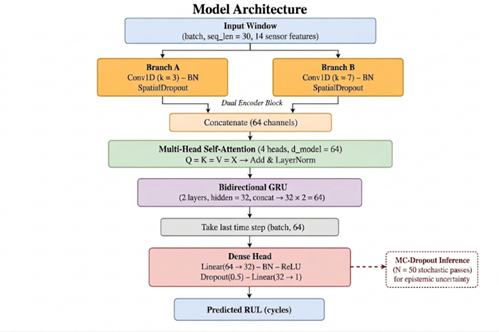

In [7]:
class DualEncoderBlock(nn.Module):
    """
    Two parallel Conv1D branches with different receptive fields.
      Branch A (kernel=3): captures short-range degradation oscillations
      Branch B (kernel=7): captures longer-range trend patterns
    Both branches share the same output channels so they can be concatenated
    directly on the channel dimension --> 128 channels total.
    """
    def __init__(self, n_features: int, out_channels: int = 64, spatial_drop: float = 0.1):
        super().__init__()

        # Branch A — local patterns
        self.conv_a = nn.Conv1d(n_features, out_channels, kernel_size=3, padding=1)
        self.bn_a = nn.BatchNorm1d(out_channels)
        self.sdrop_a = nn.Dropout2d(p=spatial_drop)   

        # Branch B — global trends
        self.conv_b = nn.Conv1d(n_features, out_channels, kernel_size=7, padding=3)
        self.bn_b = nn.BatchNorm1d(out_channels)
        self.sdrop_b = nn.Dropout2d(p=spatial_drop)


        self.relu = nn.ReLU()

    def _branch(self, x, conv, bn, sdrop):
        x = self.relu(bn(conv(x)))          
        x = x.unsqueeze(3)                 
        x = sdrop(x)
        return x.squeeze(3)                

    def forward(self, x):
        x = x.permute(0, 2, 1)             
        xa = self._branch(x, self.conv_a, self.bn_a, self.sdrop_a)
        xb = self._branch(x, self.conv_b, self.bn_b, self.sdrop_b)
        out = torch.cat([xa, xb], dim=1)   
        return out.permute(0, 2, 1)        


class SaCnnGruDE(nn.Module):
    def __init__(self, seq_length, n_features, cnn_channels=32, attn_heads=4, gru_hidden=32,
        fc_hidden=32,spatial_drop=0.3, attn_drop=0.2, gru_drop=0.3, fc_drop=0.5):
        super().__init__()

        d_model = cnn_channels * 2              # 128 after concat

        # ── Dual encoder ──────────────────────────────────────────────────
        self.dual_enc = DualEncoderBlock(n_features, cnn_channels, spatial_drop)

        # ── Multi-head self-attention + residual + norm ───────────────────
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=attn_heads, 
            dropout=attn_drop, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

        # ── Bidirectional GRU ─────────────────────────────────────────────
        self.gru = nn.GRU(input_size=d_model, hidden_size=gru_hidden, num_layers=2, batch_first=True,
            dropout=0, bidirectional=True)
        self.gru_drop = nn.Dropout(p=gru_drop)
        gru_out_dim = gru_hidden * 2          

        # ── Dense regression head ─────────────────────────────────────────
        self.fc1 = nn.Linear(gru_out_dim, fc_hidden)
        self.bn = nn.BatchNorm1d(fc_hidden)
        self.drop = nn.Dropout(p=fc_drop)
        self.fc2 = nn.Linear(fc_hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # 1. Dual encoder
        x = self.dual_enc(x)                   

        # 2. Multi-head self-attention with residual connection
        attn_out, _ = self.attn(x, x, x)      
        x = self.norm(x + attn_out)             

        # 3. Bidirectional GRU — take only the last timestep
        x, _ = self.gru(x)                     
        x = self.gru_drop(x)
        x = x[:, -1, :]                         

        # 4. Dense head
        x = self.relu(self.bn(self.fc1(x)))     
        x = self.drop(x)
        x = self.fc2(x)                         
        return x


def build_model(seq_length, n_features, loss_func = 'mse'):
    model     = SaCnnGruDE(seq_length, n_features).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.HuberLoss(delta=15.0) if loss_func == 'huber' else nn.MSELoss()
    return model, optimizer, criterion

## 5. Training Loop (with Early Stopping & LR Scheduler)

In [8]:
def train_model(model, optimizer, criterion, X_train, y_train, X_val, y_val, epochs=100,
    batch_size=32, val_split=0.15, patience=20, lr_patience=10, lr_factor=0.5, min_lr=1e-7, verbose=True):
    
    X_t = torch.tensor(X_train)
    y_t = torch.tensor(y_train).unsqueeze(1)          
    train_ds = TensorDataset(X_t, y_t)
    n_train = len(train_ds)
    Xv_t = torch.tensor(X_val)
    yv_t = torch.tensor(y_val).unsqueeze(1)
    val_ds = TensorDataset(Xv_t, yv_t)
    n_val = len(val_ds)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=lr_factor,
        patience=lr_patience, min_lr=min_lr)

    history = {'loss': [], 'val_loss': [], 'mae': [], 'val_mae': []}
    best_val = float('inf')
    best_wts = None
    patience_ctr = 0

    for epoch in range(epochs):
        # ---------- Train ----------
        model.train()
        train_loss, train_mae = 0.0, 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(Xb)
            train_mae += torch.mean(torch.abs(pred.detach() - yb)).item() * len(Xb)

        train_loss /= n_train
        train_mae  /= n_train

        # ---------- Validate ----------
        model.eval()
        val_loss, val_mae = 0.0, 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                pred = model(Xb)
                val_loss += criterion(pred, yb).item() * len(Xb)
                val_mae += torch.mean(torch.abs(pred - yb)).item() * len(Xb)

        val_loss /= n_val
        val_mae /= n_val

        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['mae'].append(train_mae)
        history['val_mae'].append(val_mae)
        if verbose:
            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"loss={train_loss:.4f} "
                f"val_loss={val_loss:.4f} "
                f"mae={train_mae:.4f} "
                f"val_mae={val_mae:.4f}"
            )

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    # Restore best weights
    if best_wts is not None:
        model.load_state_dict(best_wts)

    return history


@torch.no_grad()
def predict(model, X_np, batch_size=256):
    """Run inference and return numpy predictions."""
    model.eval()
    X_t = torch.tensor(X_np)
    preds = []
    for i in range(0, len(X_t), batch_size):
        Xb = X_t[i:i+batch_size].to(DEVICE)
        preds.append(model(Xb).cpu().numpy())
    return np.concatenate(preds, axis=0).flatten()

# ── MC Dropout: Epistemic Uncertainty Quantification ──────────────────────────
def enable_dropout(model):
    """Set all Dropout and Dropout2d layers to train mode so they remain active
    during inference. BatchNorm and other layers stay in eval mode."""
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()


def predict_mc_dropout(model, X_np, n_passes=50, batch_size=256):
    """
    Monte-Carlo Dropout inference: run N stochastic forward passes with dropout
    active to estimate epistemic (model) uncertainty.
    The architecture is completely unchanged — we simply keep the existing
    dropout layers open during inference instead of closing them.
    """
    model.eval()                       
    enable_dropout(model)              

    X_t = torch.tensor(X_np, dtype=torch.float32)
    all_preds = []

    with torch.no_grad():
        for _ in range(n_passes):
            pass_preds = []
            for i in range(0, len(X_t), batch_size):
                Xb = X_t[i:i + batch_size].to(DEVICE)
                pass_preds.append(model(Xb).cpu().numpy())
            all_preds.append(np.concatenate(pass_preds).flatten())

    all_preds = np.stack(all_preds, axis=0)    
    mean_pred = all_preds.mean(axis=0)
    std_pred = all_preds.std(axis=0)
    return mean_pred, std_pred, all_preds


def plot_mc_uncertainty(y_true, mean_pred, std_pred, dataset_name, n_passes=50, save_dir='.'):
    """
    Visualise MC-Dropout epistemic uncertainty alongside the RUL prediction.
    """
    os.makedirs(save_dir, exist_ok=True)

    abs_err = np.abs(y_true - mean_pred)
    n = len(y_true)
    x = np.arange(n)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12))

    # ── Panel 1: Prediction + uncertainty bands ──────────────────────────
    ax = axes[0]
    ax.plot(x, y_true,     color='#1f77b4', linewidth=2.0, label='Actual RUL')
    ax.plot(x, mean_pred,  color='#d62728', linewidth=1.5, label=f'MC mean ({n_passes} passes)')
    ax.fill_between(x, mean_pred - std_pred,   mean_pred + std_pred,
                    alpha=0.30, color='#d62728', label='±1σ epistemic')
    ax.fill_between(x, mean_pred - 2*std_pred, mean_pred + 2*std_pred,
                    alpha=0.12, color='#d62728', label='±2σ epistemic')
    ax.set_title(f'{dataset_name} — MC-Dropout RUL Prediction + Epistemic Uncertainty',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Unit Index', fontsize=10)
    ax.set_ylabel('RUL (Cycles)', fontsize=10)
    ax.legend(fontsize=9, frameon=True)
    ax.grid(True, linestyle='--', alpha=0.4)

    # ── Panel 2: Uncertainty vs error ────────────────────────────────────
    ax = axes[1]
    sc = ax.scatter(x, std_pred, c=abs_err, cmap='RdYlGn_r', s=18, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='|Absolute Error|')
    ax.set_title('Epistemic Uncertainty (σ) coloured by Absolute Error',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Unit Index', fontsize=10)
    ax.set_ylabel('MC-Dropout σ', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

    # ── Panel 3: Calibration scatter ─────────────────────────────────────
    ax = axes[2]
    ax.scatter(std_pred, abs_err, alpha=0.5, s=18, color='#2ca02c')
    # Ideal calibration line
    lim = max(std_pred.max(), abs_err.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Perfect calibration')
    corr = np.corrcoef(std_pred, abs_err)[0, 1]
    ax.set_title(f'Calibration: Uncertainty vs |Error|  (r={corr:.3f})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('MC-Dropout σ (epistemic uncertainty)', fontsize=10)
    ax.set_ylabel('|Absolute Error|', fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(f'SA-CNN-GRU-DE  |  MC-Dropout Epistemic Uncertainty  |  {dataset_name}',
        fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    fname = os.path.join(save_dir, f'mc_uncertainty_{dataset_name}.png')
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved → {fname}")
    return fig

## 6. Evaluation Metrics

In [9]:
def compute_s_score(y_true, y_pred):
    d = y_pred - y_true
    score = 0
    for i in d:
        score += np.exp(-i / 13) - 1 if i < 0 else np.exp(i / 10) - 1
    return score

def compute_accuracy(y_true, y_pred):
    errors = np.abs(y_true - y_pred)
    return (1 - np.mean(errors / 125.0)) * 100

## 7. Baseline Models for Comparison (LSTM, BiLSTM, CNN-LSTM, Transformer)
Definitions only — these are trained together with SA-CNN-GRU-DE in Section 8's multi-seed loop, not separately.

In [10]:
class LSTMRegressor(nn.Module):
    """Vanilla stacked (unidirectional) LSTM baseline."""
    def __init__(self, seq_length, n_features, hidden_size=64, num_layers=2,
                 fc_hidden=32, lstm_drop=0.3, fc_drop=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=lstm_drop, bidirectional=False)
        self.fc1 = nn.Linear(hidden_size, fc_hidden)
        self.bn = nn.BatchNorm1d(fc_hidden)
        self.drop = nn.Dropout(p=fc_drop)
        self.fc2 = nn.Linear(fc_hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        x = self.drop(x)
        return self.fc2(x)


class BiLSTMRegressor(nn.Module):
    """Bidirectional LSTM baseline."""
    def __init__(self, seq_length, n_features, hidden_size=32, num_layers=2,
                 fc_hidden=32, lstm_drop=0.3, fc_drop=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=lstm_drop, bidirectional=True)
        lstm_out_dim = hidden_size * 2   
        self.fc1 = nn.Linear(lstm_out_dim, fc_hidden)
        self.bn = nn.BatchNorm1d(fc_hidden)
        self.drop = nn.Dropout(p=fc_drop)
        self.fc2 = nn.Linear(fc_hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        x = self.drop(x)
        return self.fc2(x)


class CNNLSTMRegressor(nn.Module):
    """Single-branch Conv1D feature extractor feeding an LSTM — no
    attention, no dual encoder, no bidirectionality. A lighter-weight
    comparison point against the dual-encoder + attention design."""
    def __init__(self, seq_length, n_features, cnn_channels=64, hidden_size=64, num_layers=1,
                 fc_hidden=32, spatial_drop=0.3, fc_drop=0.5):
        super().__init__()
        self.conv = nn.Conv1d(n_features, cnn_channels, kernel_size=5, padding=2)
        self.bn_c = nn.BatchNorm1d(cnn_channels)
        self.relu = nn.ReLU()
        self.sdrop = nn.Dropout(p=spatial_drop)
        self.lstm = nn.LSTM(input_size=cnn_channels, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, bidirectional=False)
        self.fc1  = nn.Linear(hidden_size, fc_hidden)
        self.bn = nn.BatchNorm1d(fc_hidden)
        self.drop = nn.Dropout(p=fc_drop)
        self.fc2 = nn.Linear(fc_hidden, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)               
        x = self.relu(self.bn_c(self.conv(x)))
        x = self.sdrop(x)
        x = x.permute(0, 2, 1)               
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        x = self.drop(x)
        return self.fc2(x)


class TransformerRegressor(nn.Module):
    """Transformer-encoder baseline: linear input projection + stacked
    self-attention encoder layers + dense head."""
    def __init__(self, seq_length, n_features, d_model=64, n_heads=4, n_layers=2,
                 ff_dim=128, fc_hidden=32, attn_drop=0.2, fc_drop=0.5):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=attn_drop, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc1 = nn.Linear(d_model, fc_hidden)
        self.bn = nn.BatchNorm1d(fc_hidden)
        self.drop = nn.Dropout(p=fc_drop)
        self.fc2 = nn.Linear(fc_hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.input_proj(x)
        x = self.encoder(x)
        x = x[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        x = self.drop(x)
        return self.fc2(x)


def build_lstm_model(seq_length, n_features, loss_func='mse'):
    model = LSTMRegressor(seq_length, n_features).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.HuberLoss(delta=15.0) if loss_func == 'huber' else nn.MSELoss()
    return model, optimizer, criterion


def build_bilstm_model(seq_length, n_features, loss_func='mse'):
    model = BiLSTMRegressor(seq_length, n_features).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.HuberLoss(delta=15.0) if loss_func == 'huber' else nn.MSELoss()
    return model, optimizer, criterion


def build_cnnlstm_model(seq_length, n_features, loss_func='mse'):
    model = CNNLSTMRegressor(seq_length, n_features).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.HuberLoss(delta=15.0) if loss_func == 'huber' else nn.MSELoss()
    return model, optimizer, criterion


def build_transformer_model(seq_length, n_features, loss_func='mse'):
    model = TransformerRegressor(seq_length, n_features).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.HuberLoss(delta=15.0) if loss_func == 'huber' else nn.MSELoss()
    return model, optimizer, criterion


BASELINE_MODEL_BUILDERS = {
    'LSTM': build_lstm_model,
    'BiLSTM': build_bilstm_model,
    'CNN-LSTM': build_cnnlstm_model,
    'Transformer': build_transformer_model,
}

print("Baseline models registered:", list(BASELINE_MODEL_BUILDERS.keys()))


Baseline models registered: ['LSTM']


## 8. Multi-Seed Training — SA-CNN-GRU-DE + All Baselines (4 Subsets x 5 Seeds)

This is the **single training pass used throughout the rest of the notebook**. SA-CNN-GRU-DE and
every baseline (LSTM, BiLSTM, CNN-LSTM, Transformer) are trained once per dataset per seed (5 seeds).
Downstream sections: cross-dataset generalisation, baseline comparison, the ablation study's full-model row, and the Deep-Ensemble uncertainty
baseline reuse these stored models/metrics instead of retraining, to stay within a limited GPU budget.

In [11]:
from scipy import stats

N_SEEDS = 7
SEEDS   = [42, 123, 7, 99, 1]    

MODEL_BUILDERS_ALL = {'SA-CNN-GRU-DE': build_model}
MODEL_BUILDERS_ALL.update(BASELINE_MODEL_BUILDERS)

METRIC_NAMES = ['RMSE', 'MAE', 'R2', 'S-Score', 'Accuracy']

# multi_seed_metrics[model_name][dataset_name][metric] -> list of per-seed values (ordered like SEEDS)
multi_seed_metrics = {m: {ds: {met: [] for met in METRIC_NAMES} for ds in DATASET_CONFIGS} for m in MODEL_BUILDERS_ALL}
multi_seed_models = {m: {ds: [] for ds in DATASET_CONFIGS} for m in MODEL_BUILDERS_ALL}
multi_seed_histories = {m: {ds: [] for ds in DATASET_CONFIGS} for m in MODEL_BUILDERS_ALL}
multi_seed_predictions = {m: {ds: [] for ds in DATASET_CONFIGS} for m in MODEL_BUILDERS_ALL}
test_arrays = {}
all_scalers = {}

for dataset_name, config in DATASET_CONFIGS.items():
    print(f"\n{'='*70}\n MULTI-SEED RUNS — DATASET: {dataset_name}\n{'='*70}")

    # Data preprocessing depends only on the dataset, not the seed 
    train_df, test_df, y_test_df = load_data(dataset_name)
    train_df = add_rul(train_df)
    train_df, test_df, fitted_scalers = scale_data_strict(train_df, test_df, config)
    all_scalers[dataset_name] = fitted_scalers
    train_df = apply_smoothing(train_df, config['alpha'])
    test_df  = apply_smoothing(test_df,  config['alpha'])
    seq_length = config['seq_length']
    # Engine-level train/validation split, performed BEFORE windowing
    # (see create_train_val_sequences) so no engine's windows can appear
    # on both sides of the split. split_seed is fixed at the global SEED
    # (42) rather than the per-run training seed, so every model and every
    # one of the 5 training seeds sees the exact same train/val partition
    X_train, y_train, X_val, y_val = create_train_val_sequences(train_df, seq_length, val_split=0.2, split_seed=SEED)
    X_test_final   = prepare_test(test_df, seq_length)
    y_true_clipped = np.clip(y_test_df['RUL'].values, 0, 125)
    test_arrays[dataset_name] = X_test_final

    for model_name, builder in MODEL_BUILDERS_ALL.items():
        for seed in SEEDS:
            reset_seeds(seed)
            model, optimizer, criterion = builder(seq_length, len(features), config['loss_func'])
            history = train_model(model, optimizer, criterion, X_train, y_train,
                X_val=X_val, y_val=y_val, epochs=100,batch_size=config['batch_size'],
                patience=20, lr_patience=10, verbose=False)
            y_pred = np.clip(predict(model, X_test_final), 0, 125)
            rmse = np.sqrt(mean_squared_error(y_true_clipped, y_pred))
            mae = mean_absolute_error(y_true_clipped, y_pred)
            r2 = r2_score(y_true_clipped, y_pred)
            s_score = compute_s_score(y_true_clipped, y_pred)
            accuracy = compute_accuracy(y_true_clipped, y_pred)

            for met, val in zip(METRIC_NAMES, [rmse, mae, r2, s_score, accuracy]):
                multi_seed_metrics[model_name][dataset_name][met].append(val)
            multi_seed_models[model_name][dataset_name].append(model)
            multi_seed_histories[model_name][dataset_name].append(history)
            multi_seed_predictions[model_name][dataset_name].append(
                {'seed': seed, 'y_true': y_true_clipped, 'y_pred': y_pred}
            )

            print(f"  {model_name:14s} | seed={seed:<5d} | RMSE={rmse:.2f} MAE={mae:.2f} "
                  f"R2={r2:.4f} S={s_score:.1f} Acc={accuracy:.2f}%")

print("\nMulti-seed training complete.")



 MULTI-SEED RUNS — DATASET: FD001
FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
Scaling Complete
  SA-CNN-GRU-DE  | seed=42    | RMSE=12.53 MAE=8.92 R2=0.9023 S=339.7 Acc=92.87%
  SA-CNN-GRU-DE  | seed=123   | RMSE=12.70 MAE=9.33 R2=0.8996 S=252.4 Acc=92.54%
  SA-CNN-GRU-DE  | seed=7     | RMSE=12.78 MAE=9.32 R2=0.8982 S=291.3 Acc=92.54%
  SA-CNN-GRU-DE  | seed=99    | RMSE=12.70 MAE=9.03 R2=0.8995 S=298.9 Acc=92.77%
  SA-CNN-GRU-DE  | seed=1     | RMSE=12.61 MAE=9.44 R2=0.9010 S=301.3 Acc=92.45%
  LSTM           | seed=42    | RMSE=14.82 MAE=10.37 R2=0.8632 S=422.7 Acc=91.71%
  LSTM           | seed=123   | RMSE=13.25 MAE=10.04 R2=0.8906 S=300.4 Acc=91.97%
  LSTM           | seed=7     | RMSE=15.00 MAE=10.95 R2=0.8598 S=381.2 Acc=91.24%
  LSTM           | seed=99    | RMSE=14.27 MAE=10.11 R2=0.8732 S=432.9 Acc=91.91%
  LSTM           | seed=1     | RMSE=14.70 MAE=10.43 R2=0.8655 S=379.7 Acc=91.65%

 MULTI-SEED RUNS — DATASET: FD002
FD002 Loaded — Train: (53759, 26), Test: (339

/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5 -1.  -0.5 ...  1.5  1.5  1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
  SA-CNN-GRU-DE  | seed=42    | RMSE=13.04 MAE=9.37 R2=0.9077 S=855.6 Acc=92.51%
  SA-CNN-GRU-DE  | seed=123   | RMSE=13.07 MAE=9.64 R2=0.9074 S=679.0 Acc=92.29%
  SA-CNN-GRU-DE  | seed=7     | RMSE=13.03 MAE=9.36 R2=0.9080 S=712.3 Acc=92.51%
  SA-CNN-GRU-DE  | seed=99    | RMSE=12.86 MAE=9.25 R2=0.9103 S=660.2 Acc=92.60%
  SA-CNN-GRU-DE  | seed=1     | RMSE=12.94 MAE=8.91 R2=0.9092 S=861.9 Acc=92.87%
  LSTM           | seed=42    | RMSE=13.73 MAE=10.13 R2=0.8978 S=717.8 Acc=91.89%
  LSTM           | seed=123   | RMSE=13.39 MAE=9.78 R2=0.9027 S=728.7 Acc=92.18%
  LSTM           | seed=7     | RMSE=13.23 MAE=9.55 R2=0.9051 S=858.3 Acc=92.36%
  LSTM           | seed=99    | RMSE=13.11 MAE=9.48 R2=0.9068 S=698.0 Acc=92.42%
  LSTM           | seed=1     | RMSE=12.61 MAE=9.05 R2=0.9138 S=757.7 Acc=92.76%

 MULTI-SEED RUNS — DATASET: FD003
FD003 Loaded — Train: (24720, 26), Test: (16596, 26)
Scaling Complete
  SA-CNN-GRU-DE  | seed=42    | RMSE=12.57 MAE=8.98 R2=0.8970 S=294

/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.         -0.33333333 -0.66666667 ...  1.33333333  1.
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.66666667 -0.66666667 -0.66666667 ...  0.66666667  0.66666667
  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
  SA-CNN-GRU-DE  | seed=42    | RMSE=14.70 MAE=10.34 R2=0.8831 S=1153.2 Acc=91.73%
  SA-CNN-GRU-DE  | seed=123   | RMSE=14.10 MAE=9.72 R2=0.8923 S=1959.4 Acc=92.22%
  SA-CNN-GRU-DE  | seed=7     | RMSE=13.62 MAE=10.49 R2=0.8996 S=788.6 Acc=91.61%
  SA-CNN-GRU-DE  | seed=99    | RMSE=15.34 MAE=10.77 R2=0.8727 S=1748.8 Acc=91.39%
  SA-CNN-GRU-DE  | seed=1     | RMSE=16.05 MAE=11.42 R2=0.8605 S=2143.7 Acc=90.87%
  LSTM           | seed=42    | RMSE=14.39 MAE=10.01 R2=0.8878 S=941.2 Acc=92.00%
  LSTM           | seed=123   | RMSE=14.70 MAE=9.53 R2=0.8831 S=1340.5 Acc=92.37%
  LSTM           | seed=7     | RMSE=13.95 MAE=9.70 R2=0.8947 S=986.1 Acc=92.24%
  LSTM           | seed=99    | RMSE=14.39 MAE=10.06 R2=0.8879 S=1184.9 Acc=91.95%
  LSTM           | seed=1     | RMSE=14.54 MAE=9.95 R2=0.8856 S=1311.6 Acc=92.04%

Multi-seed training complete.


## 9. Multi-Seed Mean +/- Std Summary
Mean and standard deviation, across the 7 seeds in Section 8, for RMSE, MAE, S-Score, and Accuracy (R2 included for reference) — for SA-CNN-GRU-DE and every baseline, on all four subsets.


 MEAN ± STD ACROSS 7 SEEDS
SA-CNN-GRU-DE  FD001: RMSE=12.66±0.10  MAE=9.21±0.22  R2=0.9001±0.0015  S-Score=296.7±31.1  Accuracy=92.63±0.18%
SA-CNN-GRU-DE  FD002: RMSE=12.99±0.09  MAE=9.30±0.26  R2=0.9085±0.0012  S-Score=753.8±97.6  Accuracy=92.56±0.21%
SA-CNN-GRU-DE  FD003: RMSE=12.84±0.67  MAE=9.22±0.41  R2=0.8923±0.0113  S-Score=401.9±192.2  Accuracy=92.62±0.33%
SA-CNN-GRU-DE  FD004: RMSE=14.76±0.97  MAE=10.55±0.62  R2=0.8817±0.0155  S-Score=1558.7±569.3  Accuracy=91.56±0.50%
LSTM           FD001: RMSE=14.41±0.70  MAE=10.38±0.36  R2=0.8705±0.0123  S-Score=383.4±52.2  Accuracy=91.70±0.29%
LSTM           FD002: RMSE=13.21±0.41  MAE=9.60±0.40  R2=0.9052±0.0058  S-Score=752.1±63.2  Accuracy=92.32±0.32%
LSTM           FD003: RMSE=14.52±0.87  MAE=10.19±0.65  R2=0.8621±0.0169  S-Score=815.6±335.8  Accuracy=91.85±0.52%
LSTM           FD004: RMSE=14.39±0.28  MAE=9.85±0.22  R2=0.8878±0.0043  S-Score=1152.9±183.0  Accuracy=92.12±0.18%

Saved -> multiseed_mean_std_summary.csv


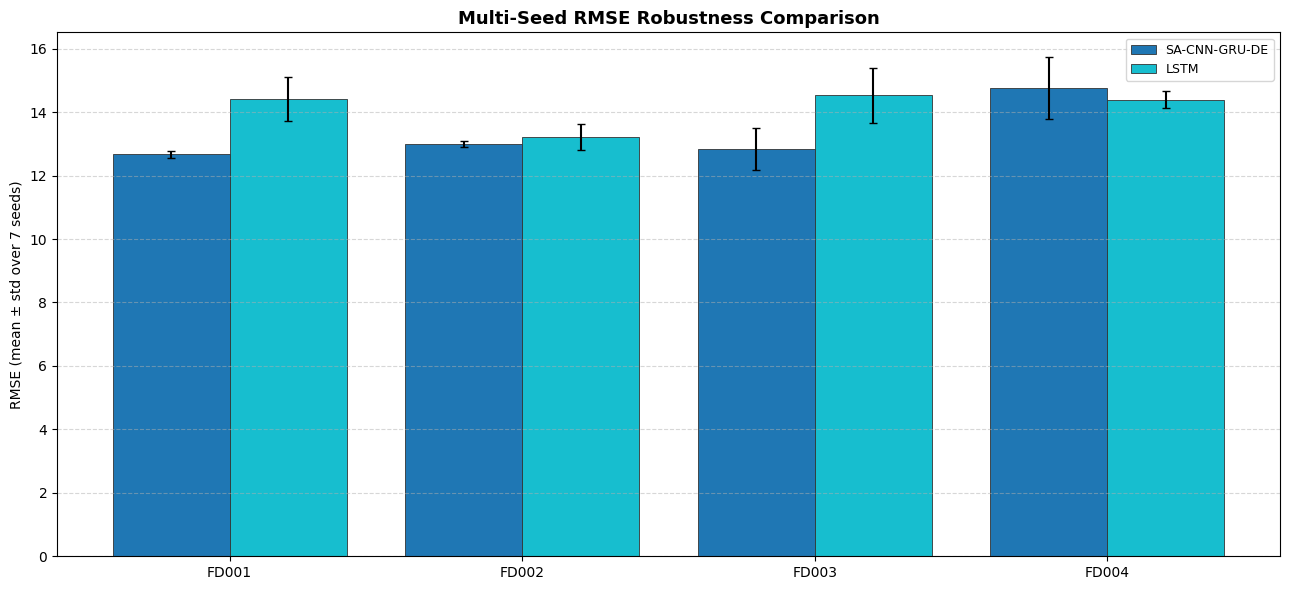

Saved -> multiseed_rmse_comparison.png


In [12]:
# ══════════════════════════════════════════════════════════════════════
# 9. MEAN ± STD SUMMARY ACROSS SEEDS
# ══════════════════════════════════════════════════════════════════════
summary_rows = []
for model_name in MODEL_BUILDERS_ALL:
    for dataset_name in DATASET_CONFIGS:
        row = {'Model': model_name, 'Dataset': dataset_name}
        for met in METRIC_NAMES:
            vals = multi_seed_metrics[model_name][dataset_name][met]
            row[f'{met}_mean'] = np.mean(vals)
            row[f'{met}_std'] = np.std(vals, ddof=1)
        summary_rows.append(row)

multiseed_summary_df = pd.DataFrame(summary_rows)

print(f"\n MEAN ± STD ACROSS {N_SEEDS} SEEDS")
for _, r in multiseed_summary_df.iterrows():
    print(f"{r['Model']:14s} {r['Dataset']}: "
          f"RMSE={r['RMSE_mean']:.2f}±{r['RMSE_std']:.2f}  "
          f"MAE={r['MAE_mean']:.2f}±{r['MAE_std']:.2f}  "
          f"R2={r['R2_mean']:.4f}±{r['R2_std']:.4f}  "
          f"S-Score={r['S-Score_mean']:.1f}±{r['S-Score_std']:.1f}  "
          f"Accuracy={r['Accuracy_mean']:.2f}±{r['Accuracy_std']:.2f}%")

multiseed_summary_df.to_csv('multiseed_mean_std_summary.csv', index=False)
print("\nSaved -> multiseed_mean_std_summary.csv")

fig, ax = plt.subplots(figsize=(13, 6))
model_names_ms = list(MODEL_BUILDERS_ALL.keys())
ds_order = list(DATASET_CONFIGS.keys())
n_models = len(model_names_ms)
bar_width = 0.8 / n_models
x              = np.arange(len(ds_order))
colours_ms     = plt.cm.tab10(np.linspace(0, 1, n_models))

for i, model_name in enumerate(model_names_ms):
    means = [multiseed_summary_df[(multiseed_summary_df.Model == model_name) &
                                   (multiseed_summary_df.Dataset == ds)]['RMSE_mean'].values[0]
             for ds in ds_order]
    stds  = [multiseed_summary_df[(multiseed_summary_df.Model == model_name) &
                                   (multiseed_summary_df.Dataset == ds)]['RMSE_std'].values[0]
             for ds in ds_order]
    ax.bar(x + i * bar_width, means, width=bar_width, yerr=stds, capsize=3,
           label=model_name, color=colours_ms[i], edgecolor='#333', linewidth=0.6)

ax.set_xticks(x + bar_width * (n_models - 1) / 2)
ax.set_xticklabels(ds_order)
ax.set_ylabel(f'RMSE (mean ± std over {N_SEEDS} seeds)')
ax.set_title('Multi-Seed RMSE Robustness Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('multiseed_rmse_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved -> multiseed_rmse_comparison.png")


## 10. Statistical Significance — SA-CNN-GRU-DE vs. Baselines
Paired (by seed) t-test + Wilcoxon signed-rank test, per dataset and pooled across all datasets/seeds. Used again by the Section 14 model-comparison summary and referenced by the Section 15 ablation-study significance test.

In [13]:
# ══════════════════════════════════════════════════════════════════════
# 10. STATISTICAL SIGNIFICANCE — SA-CNN-GRU-DE vs. each baseline
#      Paired (by seed) t-test + Wilcoxon signed-rank test, per dataset
#      and pooled across all datasets/seeds.
# ══════════════════════════════════════════════════════════════════════
def sig_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'

primary_model = 'SA-CNN-GRU-DE'
sig_rows = []

for baseline_name in BASELINE_MODEL_BUILDERS:
    for metric in ['RMSE', 'MAE', 'S-Score']:
        # --- per-dataset paired test ---
        for dataset_name in DATASET_CONFIGS:
            a = np.array(multi_seed_metrics[primary_model][dataset_name][metric])
            b = np.array(multi_seed_metrics[baseline_name][dataset_name][metric])
            t_stat, t_p = stats.ttest_rel(a, b)
            try:
                w_stat, w_p = stats.wilcoxon(a, b)
            except ValueError:
                w_stat, w_p = np.nan, np.nan
            sig_rows.append({
                'Baseline': baseline_name, 'Metric': metric, 'Dataset': dataset_name,
                f'{primary_model}_mean': a.mean(), f'{baseline_name}_mean': b.mean(),
                't_stat': t_stat, 't_pvalue': t_p,
                'wilcoxon_stat': w_stat, 'wilcoxon_pvalue': w_p,
            })

        # --- pooled across all datasets (seed x dataset pairs) ---
        a_all = np.concatenate([multi_seed_metrics[primary_model][ds][metric] for ds in DATASET_CONFIGS])
        b_all = np.concatenate([multi_seed_metrics[baseline_name][ds][metric] for ds in DATASET_CONFIGS])
        t_stat, t_p = stats.ttest_rel(a_all, b_all)
        try:
            w_stat, w_p = stats.wilcoxon(a_all, b_all)
        except ValueError:
            w_stat, w_p = np.nan, np.nan
        sig_rows.append({
            'Baseline': baseline_name, 'Metric': metric, 'Dataset': 'ALL (pooled)',
            f'{primary_model}_mean': a_all.mean(), f'{baseline_name}_mean': b_all.mean(),
            't_stat': t_stat, 't_pvalue': t_p,
            'wilcoxon_stat': w_stat, 'wilcoxon_pvalue': w_p,
        })

sig_df = pd.DataFrame(sig_rows)
sig_df['t_sig']        = sig_df['t_pvalue'].apply(sig_stars)
sig_df['wilcoxon_sig'] = sig_df['wilcoxon_pvalue'].apply(sig_stars)

print(f"\n STATISTICAL SIGNIFICANCE: {primary_model} vs. Baselines")
print(f"  (paired t-test & Wilcoxon signed-rank test across {N_SEEDS} seeds; "
      "* p<.05  ** p<.01  *** p<.001  n.s.=not significant)")
print(sig_df.round(4).to_string(index=False))
sig_df.to_csv('statistical_significance_vs_baselines.csv', index=False)
print("\nSaved -> statistical_significance_vs_baselines.csv")



 STATISTICAL SIGNIFICANCE: SA-CNN-GRU-DE vs. Baselines
  (paired t-test & Wilcoxon signed-rank test across 7 seeds; * p<.05  ** p<.01  *** p<.001  n.s.=not significant)
Baseline  Metric      Dataset  SA-CNN-GRU-DE_mean  LSTM_mean  t_stat  t_pvalue  wilcoxon_stat  wilcoxon_pvalue t_sig wilcoxon_sig
    LSTM    RMSE        FD001             12.6645    14.4093 -5.3959    0.0057            0.0           0.0625    **         n.s.
    LSTM    RMSE        FD002             12.9879    13.2140 -1.3859    0.2380            4.0           0.4375  n.s.         n.s.
    LSTM    RMSE        FD003             12.8372    14.5243 -5.7263    0.0046            0.0           0.0625    **         n.s.
    LSTM    RMSE        FD004             14.7608    14.3935  0.9396    0.4006            5.0           0.6250  n.s.         n.s.
    LSTM    RMSE ALL (pooled)             13.3126    14.1353 -3.2555    0.0042           33.0           0.0056    **           **
    LSTM     MAE        FD001              9.2072 

## 11. Seed-42 Reference Model — Extraction & MC-Dropout Uncertainty

A handful of downstream analyses (learning-curve plots, feature attribution/interpretability, and
the MC-Dropout panel reused in Section 17) are inherently single-model analyses. Per the multi-seed
protocol, **seed 42 is used as the single reference model** everywhere a single model is unavoidable.
The model, its training history and its test predictions are *extracted* from Section 8's multi-seed
run below — nothing is retrained here. Only the (cheap, inference-only) MC-Dropout pass is run fresh.

MC-Dropout uncertainty estimation for FD001 (seed 42)...


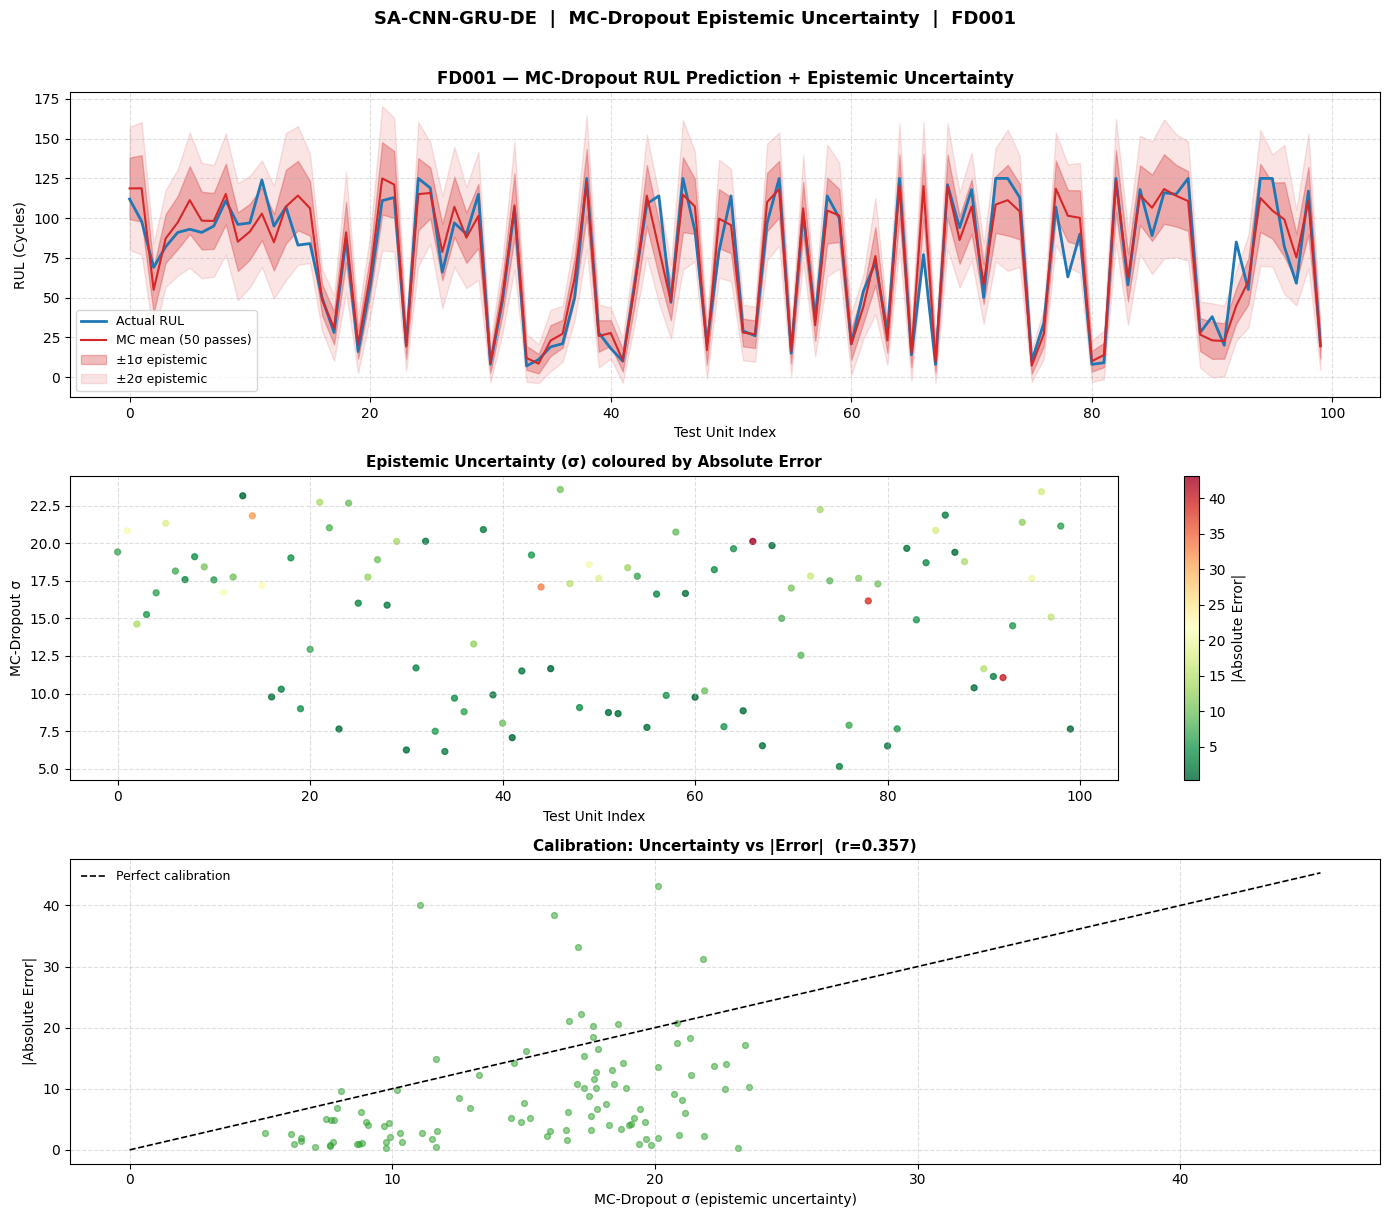

  Saved → ./mc_uncertainty_FD001.png

 SEED-42 REFERENCE RESULTS FOR FD001:
   RMSE     : 12.53
   MAE      : 8.92
   R2       : 0.9023
   S-Score  : 339.67
   Accuracy : 92.87%
MC-Dropout uncertainty estimation for FD002 (seed 42)...


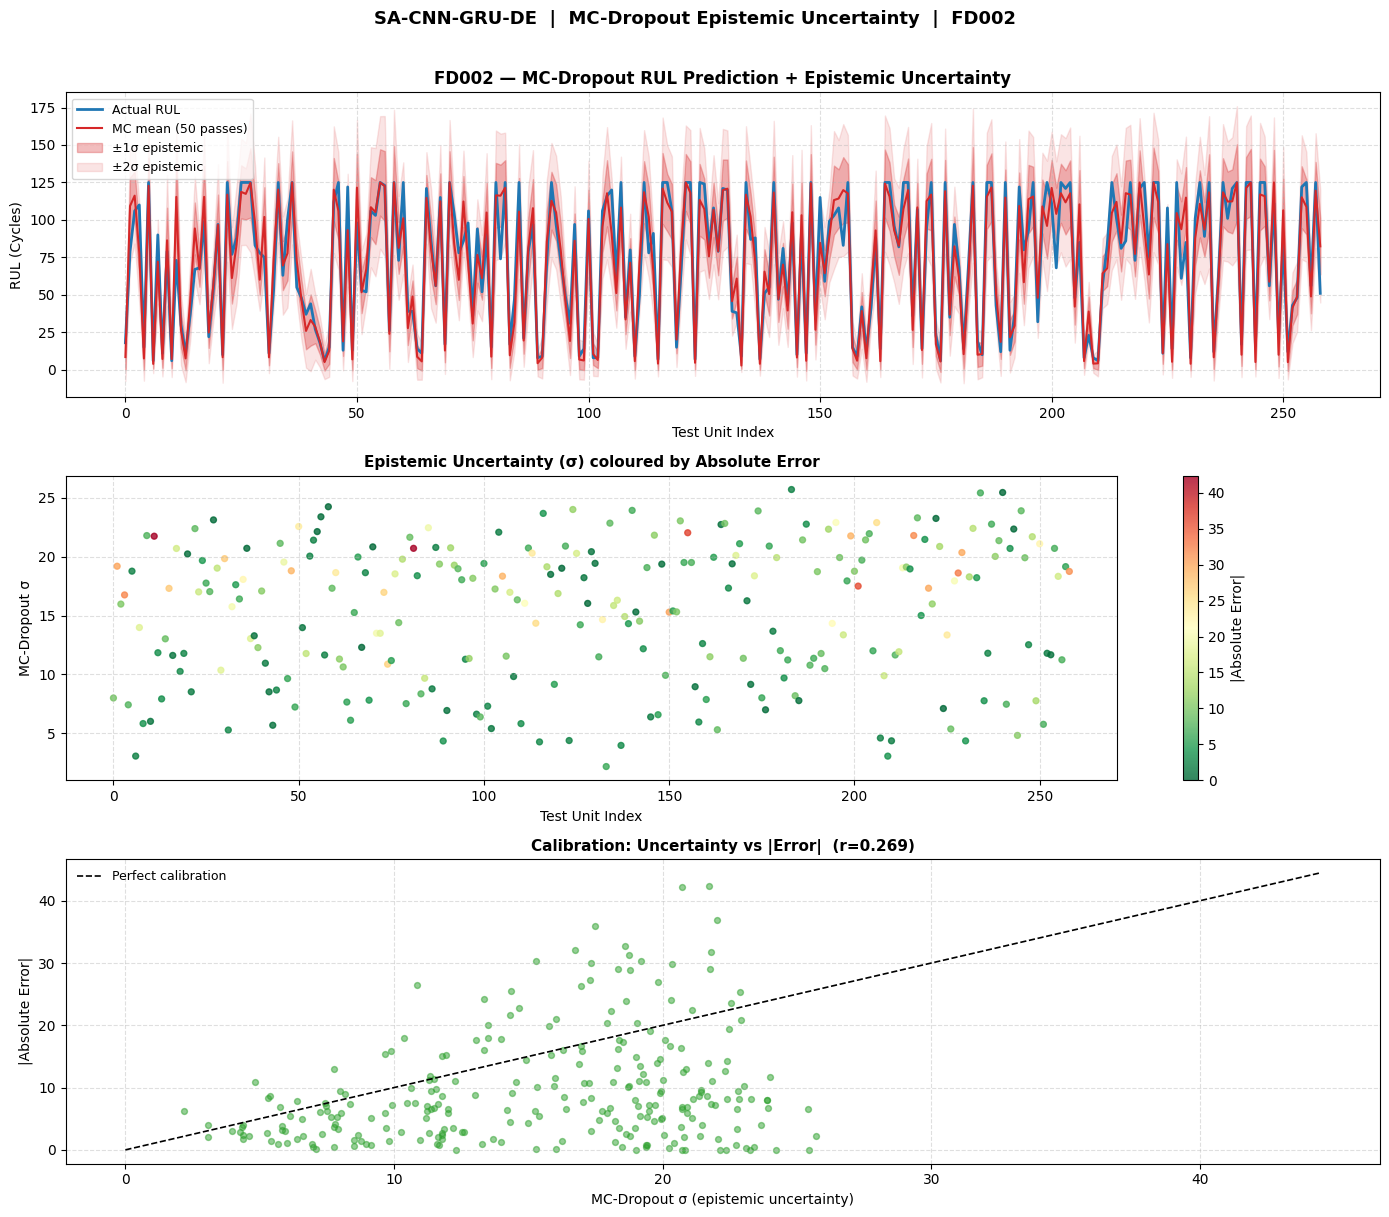

  Saved → ./mc_uncertainty_FD002.png

 SEED-42 REFERENCE RESULTS FOR FD002:
   RMSE     : 13.04
   MAE      : 9.37
   R2       : 0.9077
   S-Score  : 855.61
   Accuracy : 92.51%
MC-Dropout uncertainty estimation for FD003 (seed 42)...


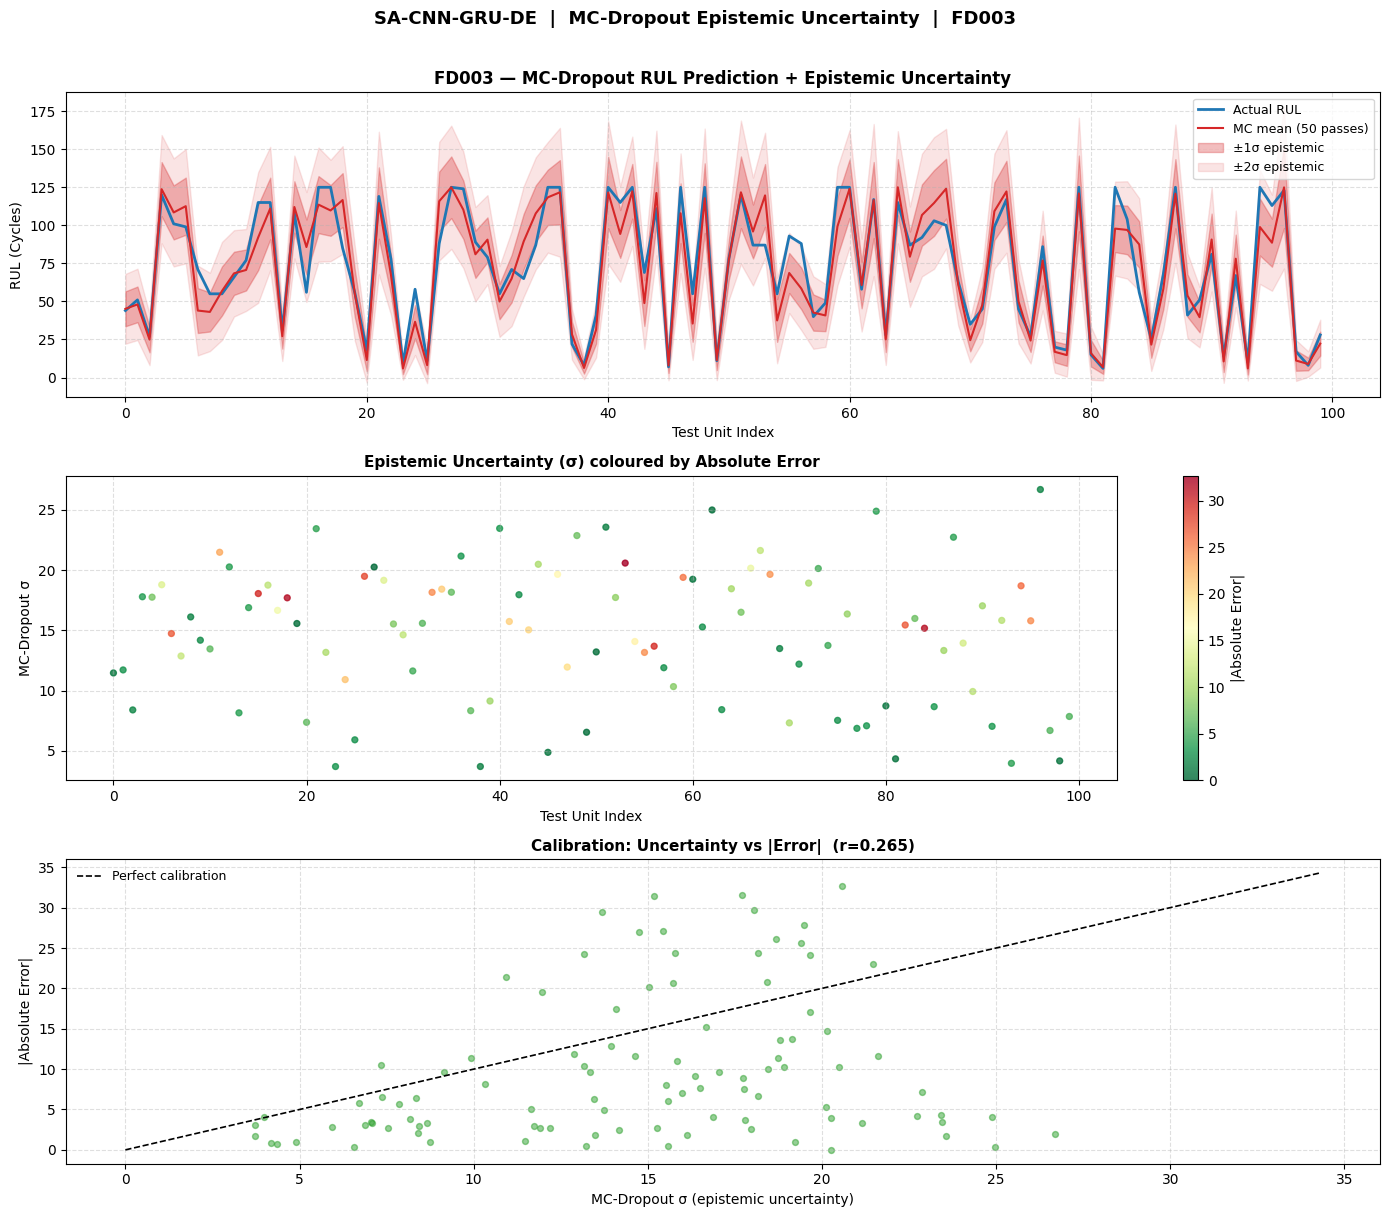

  Saved → ./mc_uncertainty_FD003.png

 SEED-42 REFERENCE RESULTS FOR FD003:
   RMSE     : 12.57
   MAE      : 8.98
   R2       : 0.8970
   S-Score  : 294.28
   Accuracy : 92.81%
MC-Dropout uncertainty estimation for FD004 (seed 42)...


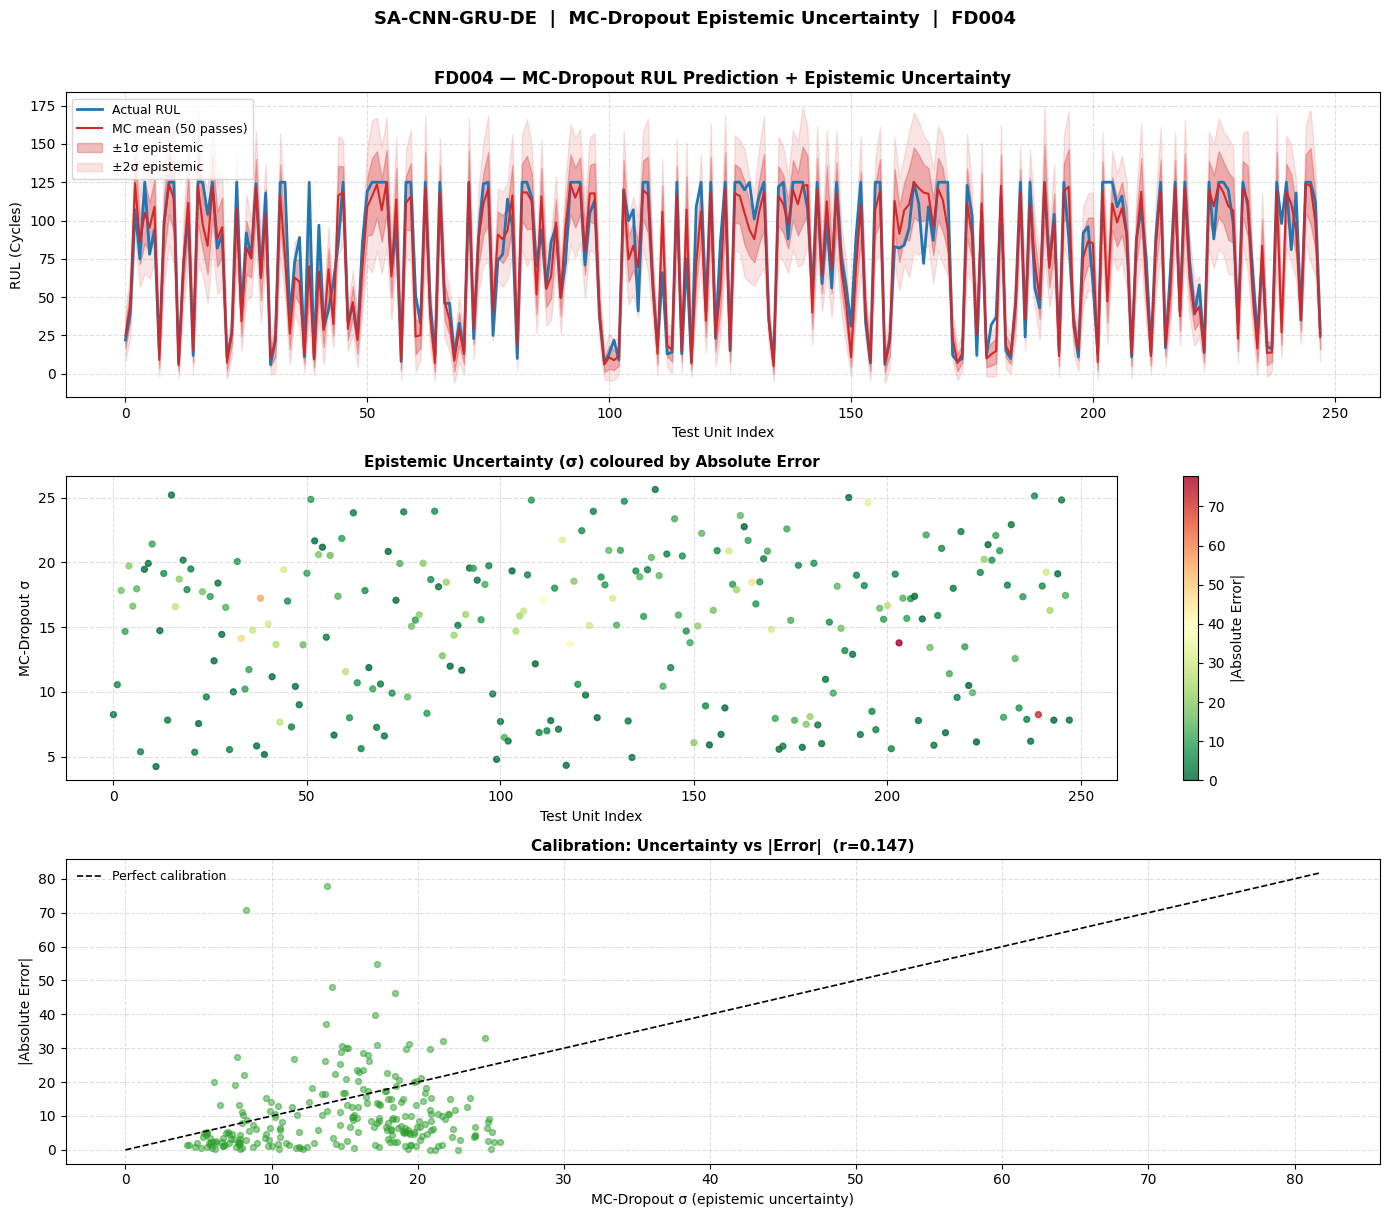

  Saved → ./mc_uncertainty_FD004.png

 SEED-42 REFERENCE RESULTS FOR FD004:
   RMSE     : 14.70
   MAE      : 10.34
   R2       : 0.8831
   S-Score  : 1153.19
   Accuracy : 91.73%

 SEED-42 REFERENCE SUMMARY (single model — see Section 9 for the robust multi-seed mean ± std)
        RMSE    MAE    R2  S-Score  Accuracy
FD001  12.53   8.92  0.90   339.67     92.87
FD002  13.04   9.37  0.91   855.61     92.51
FD003  12.57   8.98  0.90   294.28     92.81
FD004  14.70  10.34  0.88  1153.19     91.73


In [14]:
# ══════════════════════════════════════════════════════════════════════
# 11. SEED-42 REFERENCE MODEL — extracted from Section 8 (no retraining)
# ══════════════════════════════════════════════════════════════════════
REFERENCE_SEED = 42
_ref_idx = SEEDS.index(REFERENCE_SEED)

all_results     = {}   # dataset -> metric dict (seed-42 model)
all_histories   = {}   # dataset -> training history (seed-42 model)
all_models      = {}   # dataset -> trained SA-CNN-GRU-DE model (seed-42)
all_predictions = {}   # dataset -> {'y_true','y_pred','mc_mean','mc_std','mc_all'}

for dataset_name, config in DATASET_CONFIGS.items():
    model    = multi_seed_models['SA-CNN-GRU-DE'][dataset_name][_ref_idx]
    history  = multi_seed_histories['SA-CNN-GRU-DE'][dataset_name][_ref_idx]
    pred_rec = multi_seed_predictions['SA-CNN-GRU-DE'][dataset_name][_ref_idx]
    y_true_clipped, y_pred = pred_rec['y_true'], pred_rec['y_pred']
    X_test_final = test_arrays[dataset_name]

    all_models[dataset_name]    = model
    all_histories[dataset_name] = history

    # MC-Dropout epistemic uncertainty — inference-only, no training
    print(f"MC-Dropout uncertainty estimation for {dataset_name} (seed {REFERENCE_SEED})...")
    mc_mean, mc_std, mc_all = predict_mc_dropout(model, X_test_final, n_passes=50)
    mc_mean_clipped = np.clip(mc_mean, 0, 125)
    plot_mc_uncertainty(y_true_clipped, mc_mean_clipped, mc_std,
                        dataset_name=dataset_name, n_passes=50)

    all_predictions[dataset_name] = {
        'y_true':  y_true_clipped,
        'y_pred':  y_pred,
        'mc_mean': mc_mean_clipped,
        'mc_std':  mc_std,
        'mc_all':  mc_all,
    }

    rmse     = np.sqrt(mean_squared_error(y_true_clipped, y_pred))
    mae      = mean_absolute_error(y_true_clipped, y_pred)
    r2       = r2_score(y_true_clipped, y_pred)
    s_score  = compute_s_score(y_true_clipped, y_pred)
    accuracy = compute_accuracy(y_true_clipped, y_pred)

    all_results[dataset_name] = {
        'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'S-Score': s_score, 'Accuracy': accuracy
    }

    print(f"\n SEED-{REFERENCE_SEED} REFERENCE RESULTS FOR {dataset_name}:")
    print(f"   RMSE     : {rmse:.2f}")
    print(f"   MAE      : {mae:.2f}")
    print(f"   R2       : {r2:.4f}")
    print(f"   S-Score  : {s_score:.2f}")
    print(f"   Accuracy : {accuracy:.2f}%")

print("\n SEED-42 REFERENCE SUMMARY (single model — see Section 9 for the robust multi-seed mean ± std)")
results_df = pd.DataFrame(all_results).T.round(2)
print(results_df.to_string())


## 12. Learning Curves & Predicted vs. Actual RUL (Seed 42)
Plotted from the seed-42 reference model extracted in Section 11 — per the notebook's single-seed-plot policy, no separate model is trained for these curves.

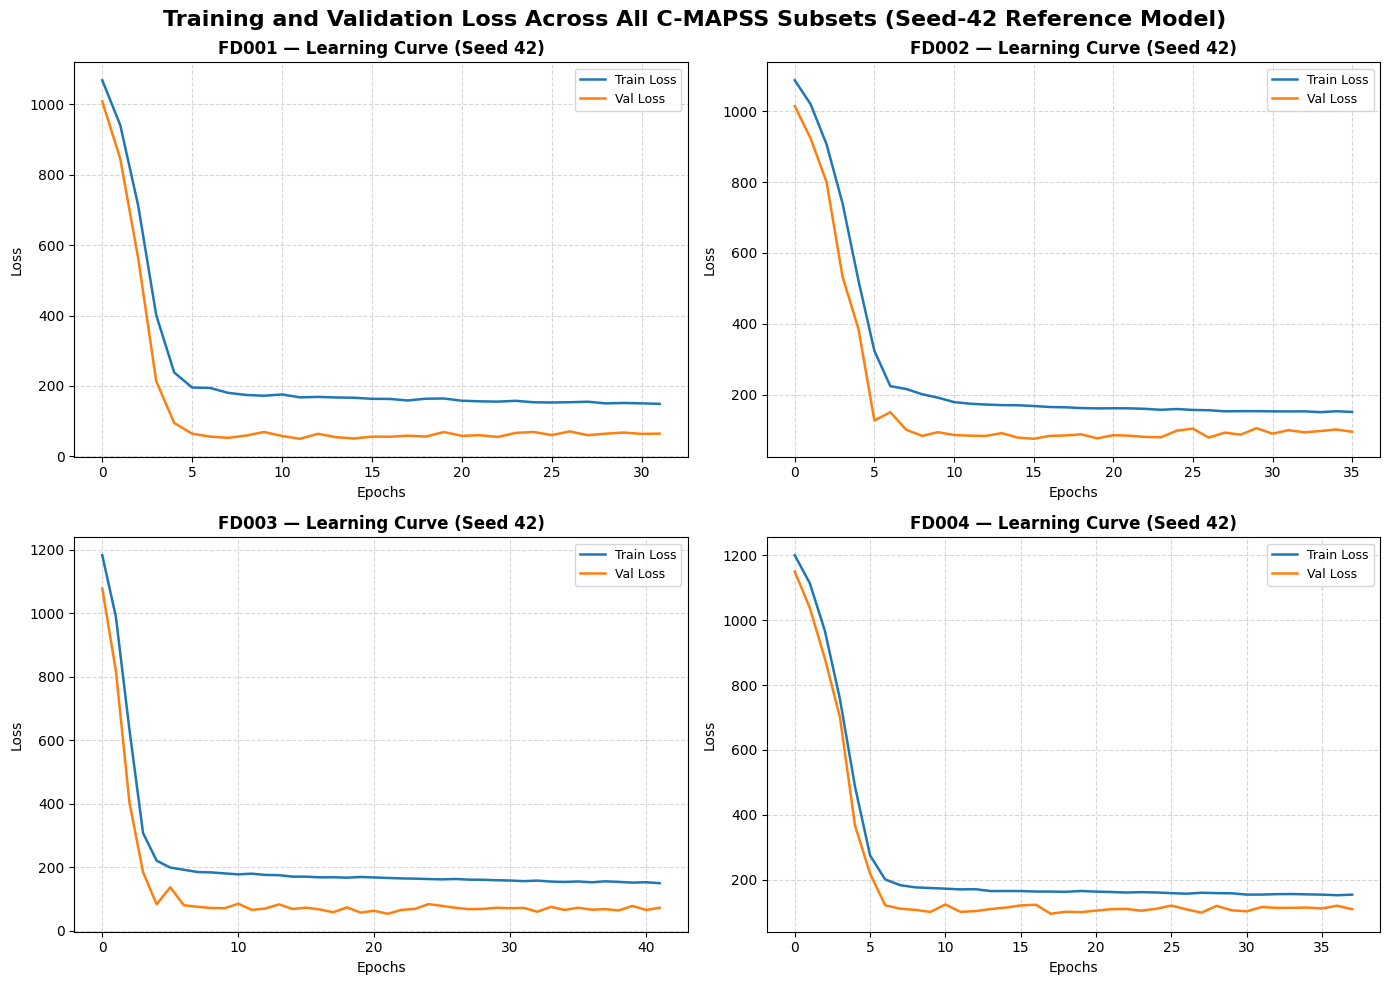

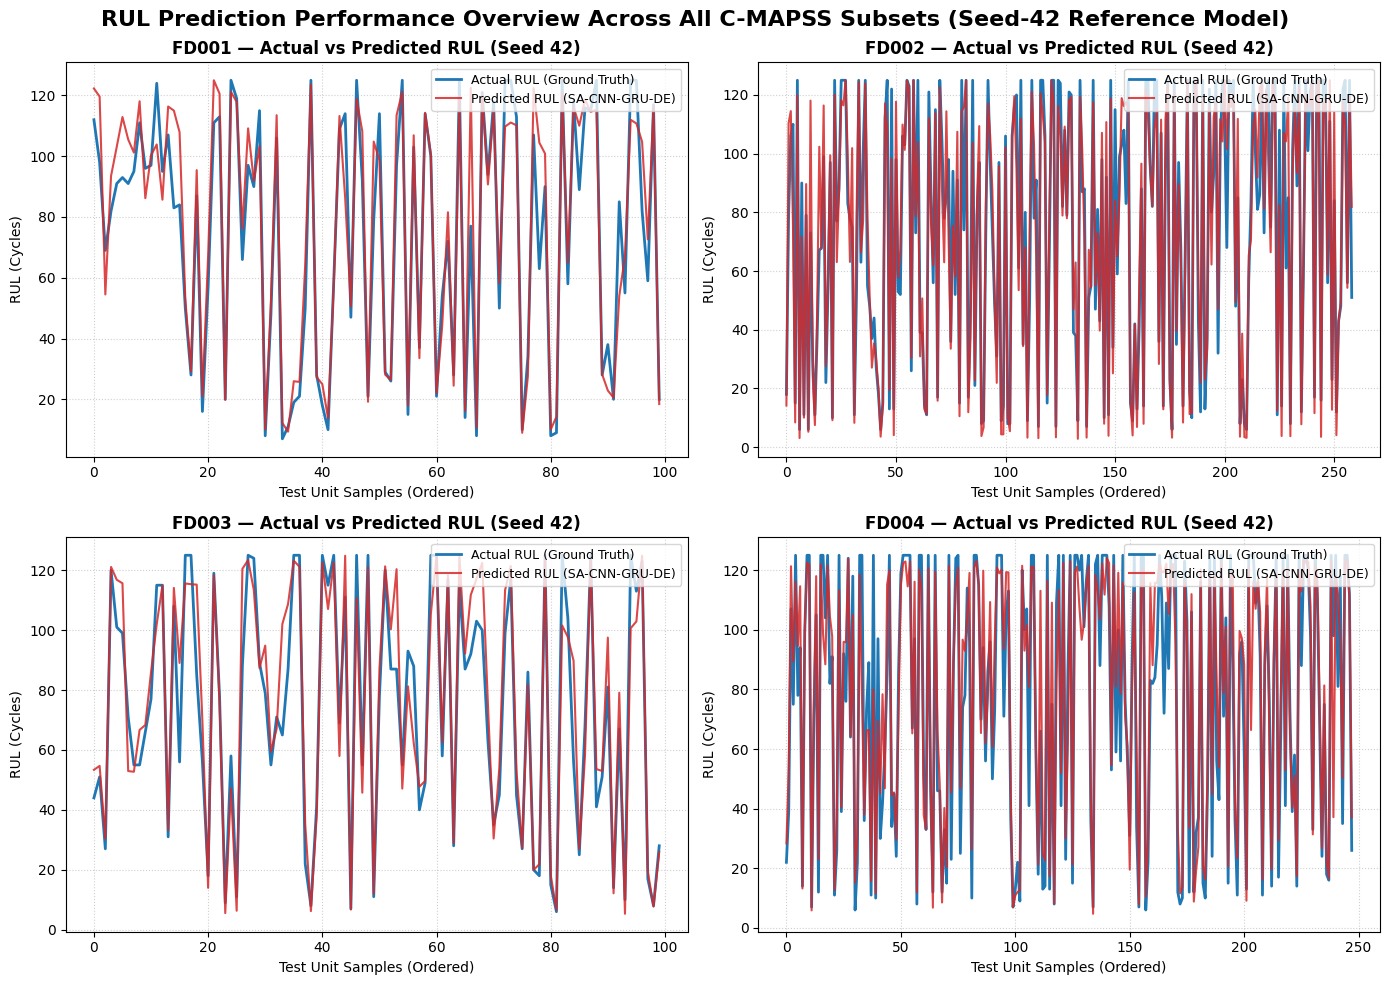

In [15]:
if len(all_histories) == 4 and len(all_predictions) == 4:
    datasets = ['FD001', 'FD002', 'FD003', 'FD004']

    # ── Learning curves (seed 42) ──
    fig_loss, axes_loss = plt.subplots(2, 2, figsize=(14, 10))
    axes_loss = axes_loss.flatten()

    for idx, ds in enumerate(datasets):
        ax = axes_loss[idx]
        ax.plot(all_histories[ds]['loss'],     label='Train Loss', color='#1f77b4', linewidth=1.8)
        ax.plot(all_histories[ds]['val_loss'], label='Val Loss',   color='#ff7f0e', linewidth=1.8)
        ax.set_title(f'{ds} — Learning Curve (Seed 42)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epochs', fontsize=10)
        ax.set_ylabel('Loss', fontsize=10)
        ax.legend(frameon=True, shadow=False, fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(
        "Training and Validation Loss Across All C-MAPSS Subsets (Seed-42 Reference Model)",
        fontsize=16, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    plt.savefig('all_datasets_learning_curves.png', dpi=300)
    plt.show()

    # ── Predicted vs Actual (seed 42) ──
    fig_pred, axes_pred = plt.subplots(2, 2, figsize=(14, 10))
    axes_pred = axes_pred.flatten()

    for idx, ds in enumerate(datasets):
        ax = axes_pred[idx]
        y_true_plot = all_predictions[ds]['y_true']
        y_pred_plot = all_predictions[ds]['y_pred']
        ax.plot(y_true_plot, label='Actual RUL (Ground Truth)', color='#1f77b4', linestyle='-', linewidth=2.0)
        ax.plot(y_pred_plot, label='Predicted RUL (SA-CNN-GRU-DE)',  color='#d62728', linestyle='-', linewidth=1.5, alpha=0.85)
        ax.set_title(f'{ds} — Actual vs Predicted RUL (Seed 42)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Test Unit Samples (Ordered)', fontsize=10)
        ax.set_ylabel('RUL (Cycles)', fontsize=10)
        ax.legend(loc='upper right', frameon=True, shadow=False, fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(
        "RUL Prediction Performance Overview Across All C-MAPSS Subsets (Seed-42 Reference Model)",
        fontsize=16, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    plt.savefig('all_datasets_predict_vs_true.png', dpi=300)
    plt.show()


## 13. Cross-Dataset Generalisation Evaluation (Multi-Seed)

Uses the 7 seed-diverse SA-CNN-GRU-DE models stored in Section 8 — **no retraining**. For every
(source, target) pair, all 7 source-seed models are evaluated on the target test set and results are
reported as mean ± std across seeds. The heatmaps below display the **mean**.

FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
FD002 Loaded — Train: (53759, 26), Test: (33991, 26)
FD003 Loaded — Train: (24720, 26), Test: (16596, 26)
FD004 Loaded — Train: (61249, 26), Test: (41214, 26)
Raw (unscaled) test sets loaded.



/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5  0.   0.  ...  1.   1.   1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.  -1.  -1.  ...  0.5  1.  -0.5]' has dtype incompatible with int64, please explicitly cast to a c

  CROSS-DATASET EVALUATION  (rows = train source, cols = test target)
  mean ± std over 7 seeds; [target test data scaled with SOURCE model's scaler]

── RMSE ──
Train ↓  Test →       FD001       FD002       FD003       FD004
FD001            12.66±0.10  54.13±5.08  46.81±2.00  53.13±4.39
FD002            13.04±0.33  12.99±0.09  42.36±6.25  37.04±3.16
FD003            12.67±0.47  61.91±4.40  12.84±0.67  59.77±3.44
FD004            14.58±1.22  15.26±1.03  14.13±1.36  14.76±0.97

── MAE ──
Train ↓  Test →       FD001       FD002       FD003       FD004
FD001             9.21±0.22  43.01±2.76  29.78±1.00  41.97±2.00
FD002             9.21±0.49   9.30±0.26  27.85±3.14  23.11±1.37
FD003             9.28±0.24  47.85±3.07   9.22±0.41  45.38±1.43
FD004            11.41±0.98  11.58±0.88  10.65±0.77  10.55±0.62

── R2 ──
Train ↓  Test →      FD001       FD002       FD003       FD004
FD001            0.90±0.00  -0.60±0.30  -0.43±0.12  -0.54±0.25
FD002            0.89±0.01   0.91±0.00  -0.19±0.33 

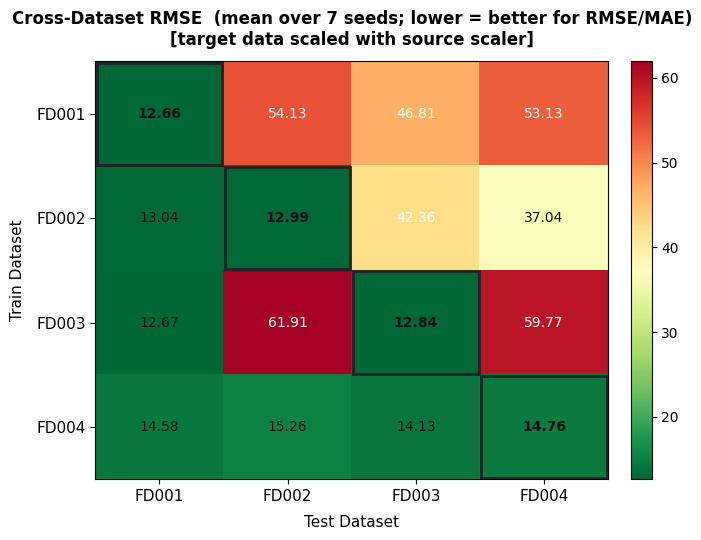

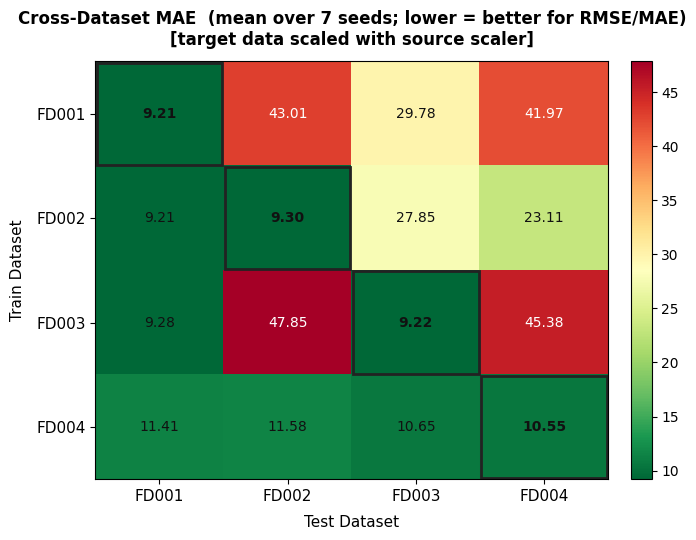

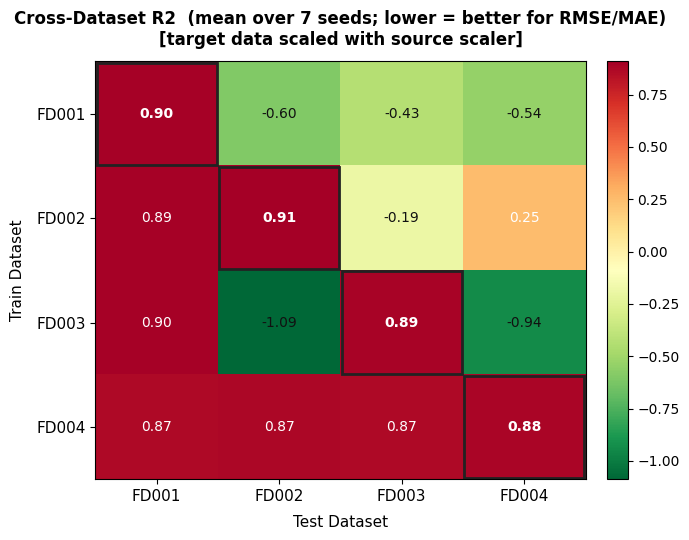

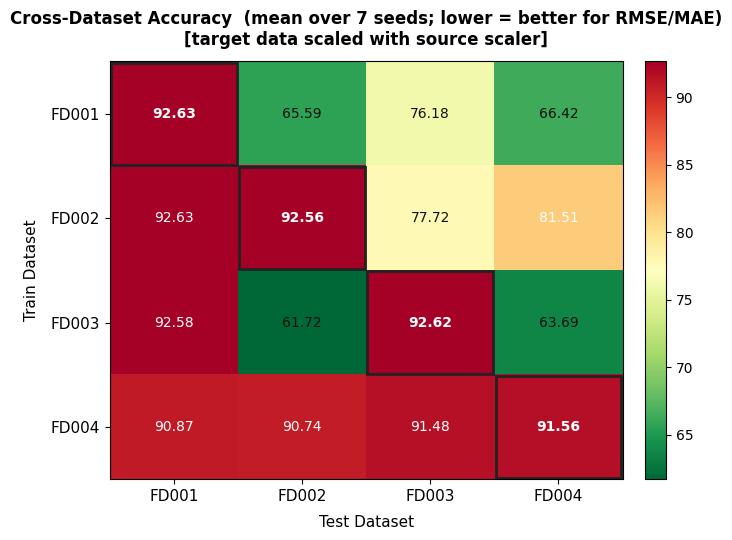


── Generalisation Gap (mean RMSE) ──
  = mean(off-diagonal RMSE) − in-distribution RMSE

  FD001:  in-dist=12.66  mean-OOD=51.36  gap=+38.70
  FD002:  in-dist=12.99  mean-OOD=30.82  gap=+17.83
  FD003:  in-dist=12.84  mean-OOD=44.79  gap=+31.95
  FD004:  in-dist=14.76  mean-OOD=14.66  gap=-0.10


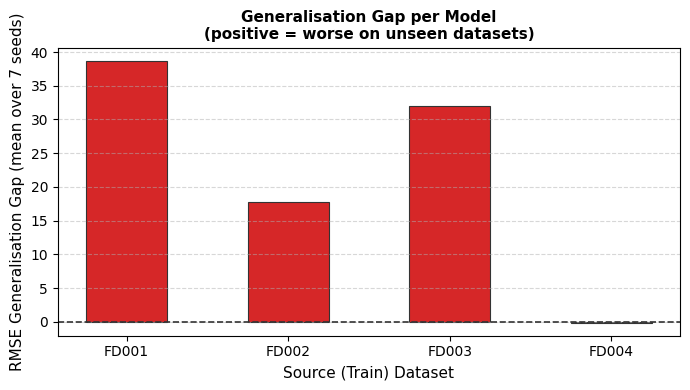

In [16]:
# ══════════════════════════════════════════════════════════════════════
# CROSS-DATASET GENERALISATION EVALUATION (Multi-Seed, source-scaler corrected)
# ──────────────────────────────────────────────────────────────────────
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']

# ── 1. Pre-load raw (unscaled) test data and RUL labels for every dataset ──
raw_test_dfs       = {}
cross_test_labels  = {}

for tgt in DATASETS:
    _, test_df_raw, y_test_tmp = load_data(tgt)
    raw_test_dfs[tgt]      = test_df_raw
    cross_test_labels[tgt] = np.clip(y_test_tmp['RUL'].values, 0, 125)

print("Raw (unscaled) test sets loaded.\n")

# ── 2. Evaluate every (source seed model) × (target dataset) pair ─────
metrics_keys = ['RMSE', 'MAE', 'R2', 'S-Score', 'Accuracy']

# cross_seed_results[(src, tgt)][metric] -> list of per-seed values (7 seeds)
cross_seed_results = {}
# cross_results[(src, tgt)][metric] -> {'mean': ..., 'std': ...}
cross_results = {}

for src in DATASETS:
    src_config = DATASET_CONFIGS[src]
    src_seq    = src_config['seq_length']
    src_models = multi_seed_models['SA-CNN-GRU-DE'][src]     # 7 seed-diverse models

    for tgt in DATASETS:
        tgt_config = DATASET_CONFIGS[tgt]
        tgt_seq    = tgt_config['seq_length']
        y_true     = cross_test_labels[tgt]

        # ── Scale target test data with SOURCE scaler (dataset-level, seed-independent) ──
        test_df_scaled = apply_source_scaler(
            raw_test_dfs[tgt], all_scalers[src], src_config
        )
        test_df_scaled = apply_smoothing(test_df_scaled, tgt_config['alpha'])
        X_tgt = prepare_test(test_df_scaled, tgt_seq)

        # ── Sequence-length mismatch handling ─────────────────────────
        if tgt_seq != src_seq:
            if tgt_seq > src_seq:
                X_eval = X_tgt[:, -src_seq:, :]
            else:
                pad = np.zeros((X_tgt.shape[0], src_seq - tgt_seq, X_tgt.shape[2]), dtype=np.float32)
                X_eval = np.concatenate([pad, X_tgt], axis=1)
        else:
            X_eval = X_tgt

        seed_metrics = {m: [] for m in metrics_keys}
        for seed_model in src_models:
            y_pred = np.clip(predict(seed_model, X_eval), 0, 125)
            seed_metrics['RMSE'].append(float(np.sqrt(mean_squared_error(y_true, y_pred))))
            seed_metrics['MAE'].append(float(mean_absolute_error(y_true, y_pred)))
            seed_metrics['R2'].append(float(r2_score(y_true, y_pred)))
            seed_metrics['S-Score'].append(float(compute_s_score(y_true, y_pred)))
            seed_metrics['Accuracy'].append(float(compute_accuracy(y_true, y_pred)))

        cross_seed_results[(src, tgt)] = seed_metrics
        cross_results[(src, tgt)] = {
            m: {'mean': float(np.mean(v)), 'std': float(np.std(v, ddof=1))}
            for m, v in seed_metrics.items()
        }

# ── 3. Pretty-print summary tables (mean ± std across the 7 seeds) ────
print("=" * 78)
print("  CROSS-DATASET EVALUATION  (rows = train source, cols = test target)")
print(f"  mean ± std over {N_SEEDS} seeds; [target test data scaled with SOURCE model's scaler]")
print("=" * 78)

for metric in metrics_keys:
    mat = pd.DataFrame(
        {tgt: {src: f"{cross_results[(src, tgt)][metric]['mean']:.2f}±{cross_results[(src, tgt)][metric]['std']:.2f}"
               for src in DATASETS}
         for tgt in DATASETS},
        index=DATASETS
    ).rename_axis("Train ↓  Test →", axis='columns')

    print(f"\n── {metric} ──")
    print(mat.to_string())

# ── 4. Structured DataFrame for downstream use / export ───────────────
records = []
for (src, tgt), mdict in cross_results.items():
    row = {'Train': src, 'Test': tgt}
    for m in metrics_keys:
        row[f'{m}_mean'] = mdict[m]['mean']
        row[f'{m}_std']  = mdict[m]['std']
    records.append(row)

cross_df = pd.DataFrame(records).set_index(['Train', 'Test']).round(3)
print("\n\n── Full Cross-Dataset Results Table (mean ± std over 7 seeds) ──")
print(cross_df.to_string())
cross_df.to_csv('cross_dataset_results_multiseed.csv')
print("\nSaved to cross_dataset_results_multiseed.csv")

# ── 5. Heatmap visualisation (MEAN values) ─────────────────────────────
def plot_cross_heatmap(metric='RMSE', cmap_name='RdYlGn_r', figsize=(7, 5.5)):
    matrix = np.array([
        [cross_results[(src, tgt)][metric]['mean'] for tgt in DATASETS]
        for src in DATASETS
    ], dtype=float)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap_name, aspect='auto')

    ax.set_xticks(range(4)); ax.set_xticklabels(DATASETS, fontsize=11)
    ax.set_yticks(range(4)); ax.set_yticklabels(DATASETS, fontsize=11)
    ax.set_xlabel('Test Dataset',  fontsize=11, labelpad=8)
    ax.set_ylabel('Train Dataset', fontsize=11, labelpad=8)
    ax.set_title(f'Cross-Dataset {metric}  (mean over {N_SEEDS} seeds; lower = better for RMSE/MAE)\n'
                 f'[target data scaled with source scaler]',
                 fontsize=12, fontweight='bold', pad=12)

    # Annotate cells
    vmin, vmax = matrix.min(), matrix.max()
    for i in range(4):
        for j in range(4):
            val    = matrix[i, j]
            colour = 'white' if (val - vmin) / max(vmax - vmin, 1e-9) > 0.6 else '#111'
            weight = 'bold' if i == j else 'normal'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=10, color=colour, fontweight=weight)

    # Mark diagonal
    for d in range(4):
        ax.add_patch(mpatches.FancyBboxPatch(
            (d - 0.49, d - 0.49), 0.98, 0.98,
            boxstyle="square,pad=0", linewidth=2,
            edgecolor='#222', facecolor='none'
        ))

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(f'cross_dataset_{metric.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

for m in ['RMSE', 'MAE', 'R2', 'Accuracy']:
    plot_cross_heatmap(metric=m)

# ── 6. Generalisation gap bar chart (based on mean RMSE across seeds) ─
print("\n── Generalisation Gap (mean RMSE) ──")
print("  = mean(off-diagonal RMSE) − in-distribution RMSE")
print()

fig, ax = plt.subplots(figsize=(7, 4))
gap_vals, labels = [], []

for src in DATASETS:
    in_dist  = cross_results[(src, src)]['RMSE']['mean']
    off_diag = [cross_results[(src, tgt)]['RMSE']['mean']
                for tgt in DATASETS if tgt != src]
    gap      = np.mean(off_diag) - in_dist
    gap_vals.append(gap)
    labels.append(src)
    print(f"  {src}:  in-dist={in_dist:.2f}  "
          f"mean-OOD={np.mean(off_diag):.2f}  gap={gap:+.2f}")

colours = ['#d62728' if g > 0 else '#2ca02c' for g in gap_vals]
ax.bar(labels, gap_vals, color=colours, width=0.5, edgecolor='#333', linewidth=0.8)
ax.axhline(0, color='#333', linewidth=1.2, linestyle='--')
ax.set_xlabel('Source (Train) Dataset', fontsize=11)
ax.set_ylabel('RMSE Generalisation Gap (mean over 7 seeds)', fontsize=11)
ax.set_title('Generalisation Gap per Model\n(positive = worse on unseen datasets)',
             fontsize=11, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cross_dataset_generalisation_gap.png', dpi=300)
plt.show()


## 14. Model Comparison — SA-CNN-GRU-DE vs. Baselines (Multi-Seed)

Consumes the mean ± std already computed in Section 9 — **no model here is retrained**; baselines
and SA-CNN-GRU-DE both come from the single multi-seed pass in Section 8. Statistical significance
of SA-CNN-GRU-DE vs. each baseline was already computed in Section 10.


 PER-DATASET MODEL COMPARISON (mean over 7 seeds)
        Model Dataset  RMSE   MAE   R2  S-Score  Accuracy
SA-CNN-GRU-DE   FD001 12.66  9.21 0.90   296.73     92.63
SA-CNN-GRU-DE   FD002 12.99  9.30 0.91   753.82     92.56
SA-CNN-GRU-DE   FD003 12.84  9.22 0.89   401.94     92.62
SA-CNN-GRU-DE   FD004 14.76 10.55 0.88  1558.73     91.56
         LSTM   FD001 14.41 10.38 0.87   383.38     91.70
         LSTM   FD002 13.21  9.60 0.91   752.09     92.32
         LSTM   FD003 14.52 10.19 0.86   815.58     91.85
         LSTM   FD004 14.39  9.85 0.89  1152.87     92.12

 AVERAGE PERFORMANCE ACROSS ALL DATASETS (mean over 7 seeds, averaged over datasets)
                RMSE    MAE    R2  S-Score  Accuracy
Model                                               
SA-CNN-GRU-DE  13.31   9.57  0.90   752.80     92.34
LSTM           14.14  10.01  0.88   775.98     92.00

Saved -> model_comparison_per_dataset_multiseed.csv, model_comparison_average_multiseed.csv


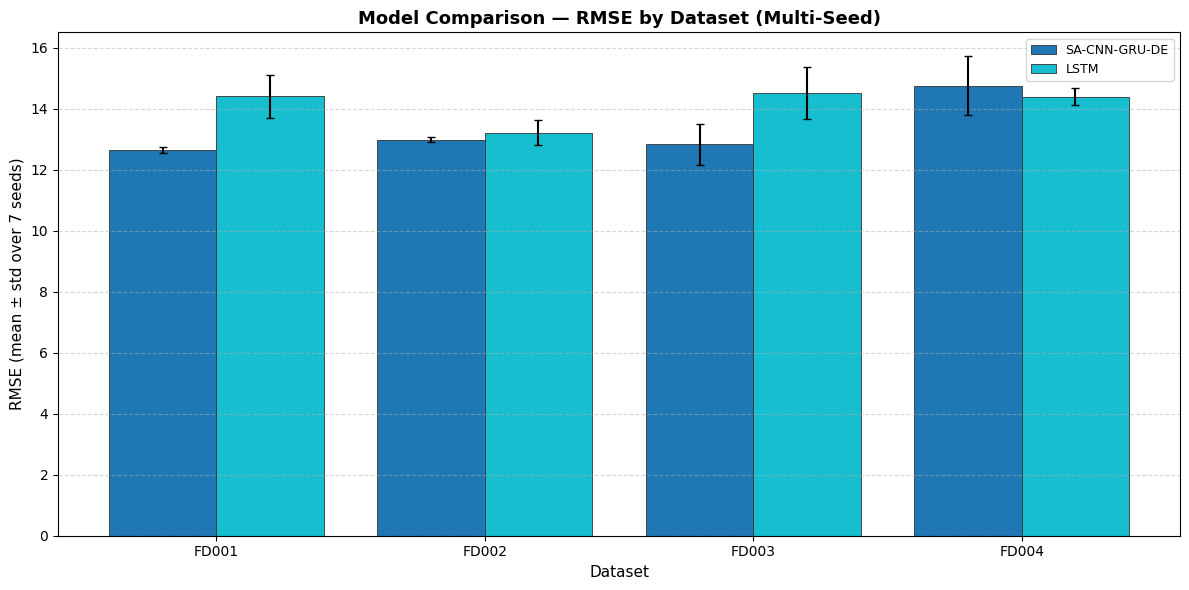

  Saved -> model_comparison_rmse_multiseed.png


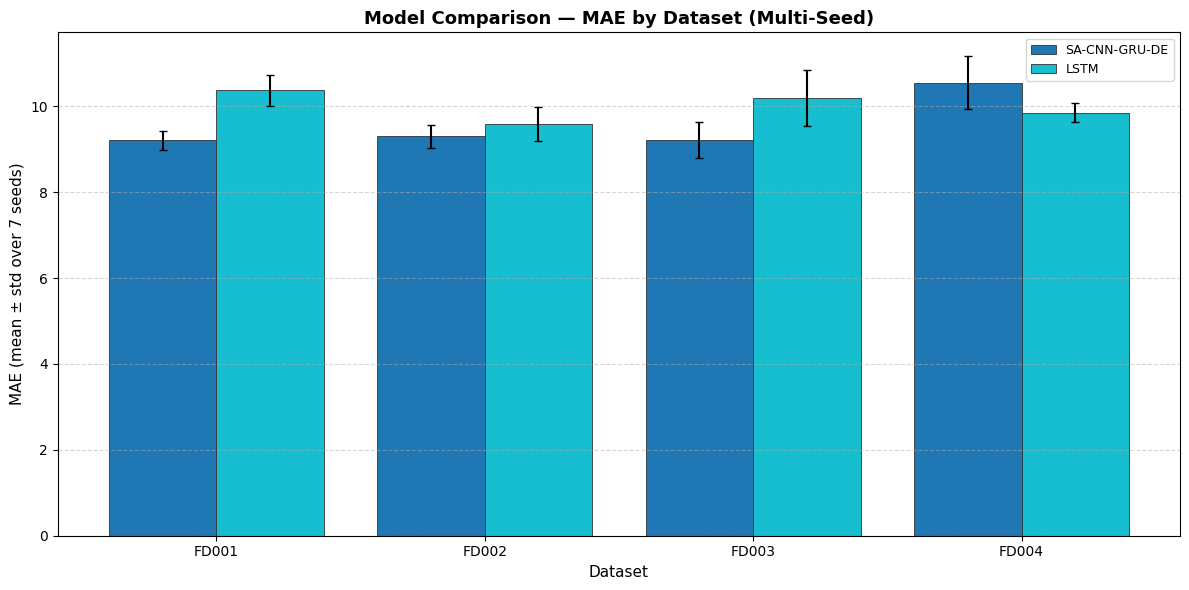

  Saved -> model_comparison_mae_multiseed.png


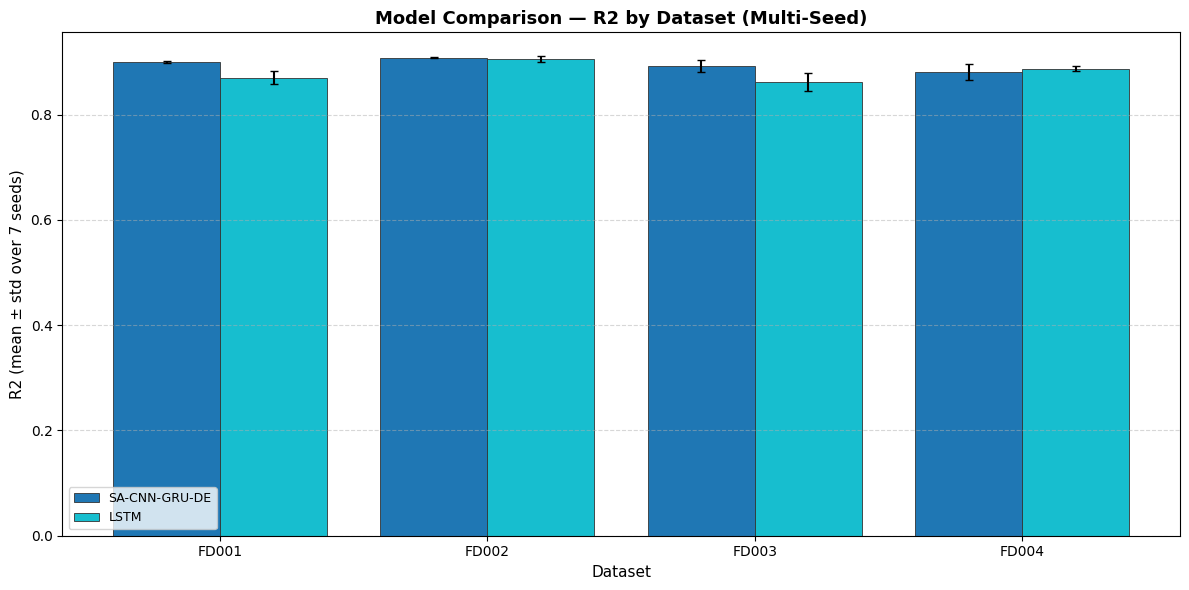

  Saved -> model_comparison_r2_multiseed.png


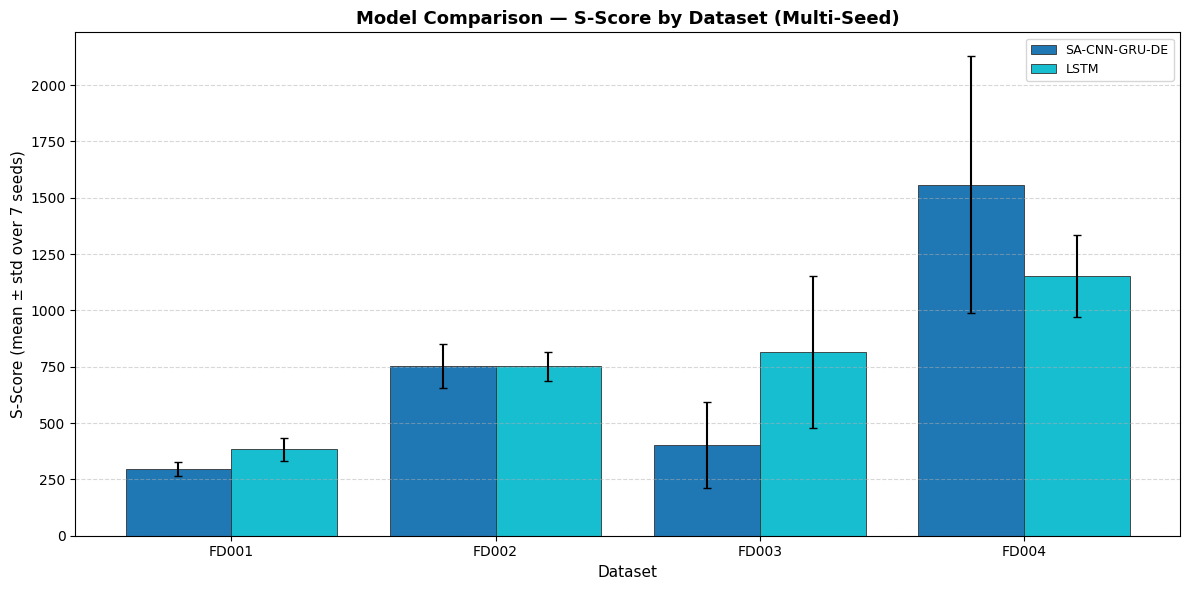

  Saved -> model_comparison_s_score_multiseed.png


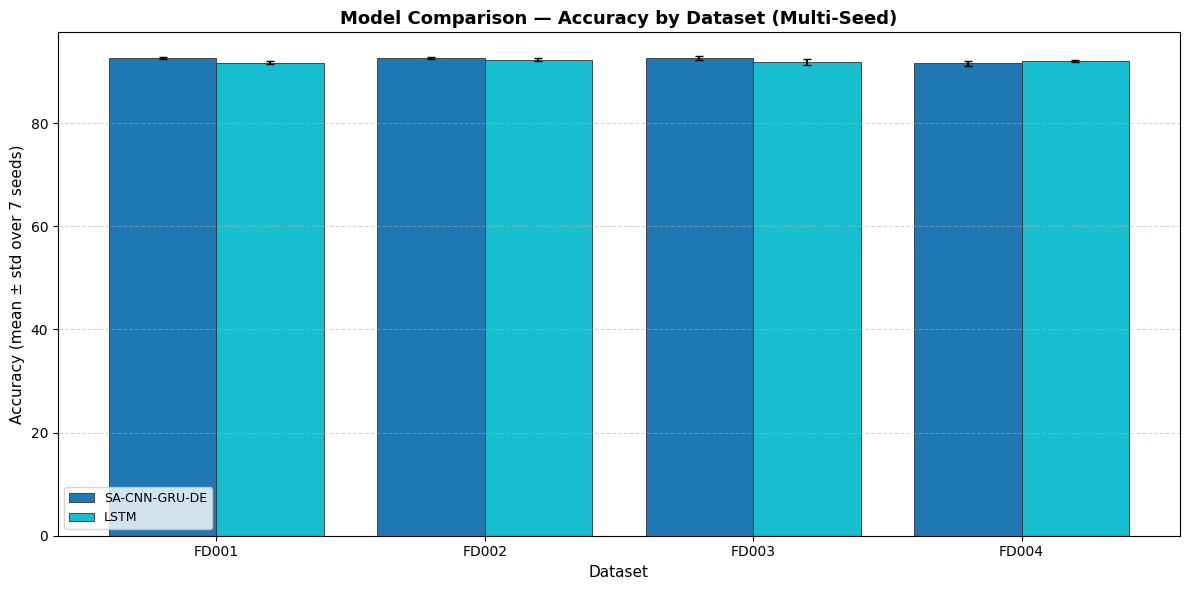

  Saved -> model_comparison_accuracy_multiseed.png


/tmp/ipykernel_23/453345451.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_23/453345451.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_23/453345451.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_23/453345451.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=8)
/tmp/ipykernel_23/453345451.py:74: UserWarning: set_ticklabels()

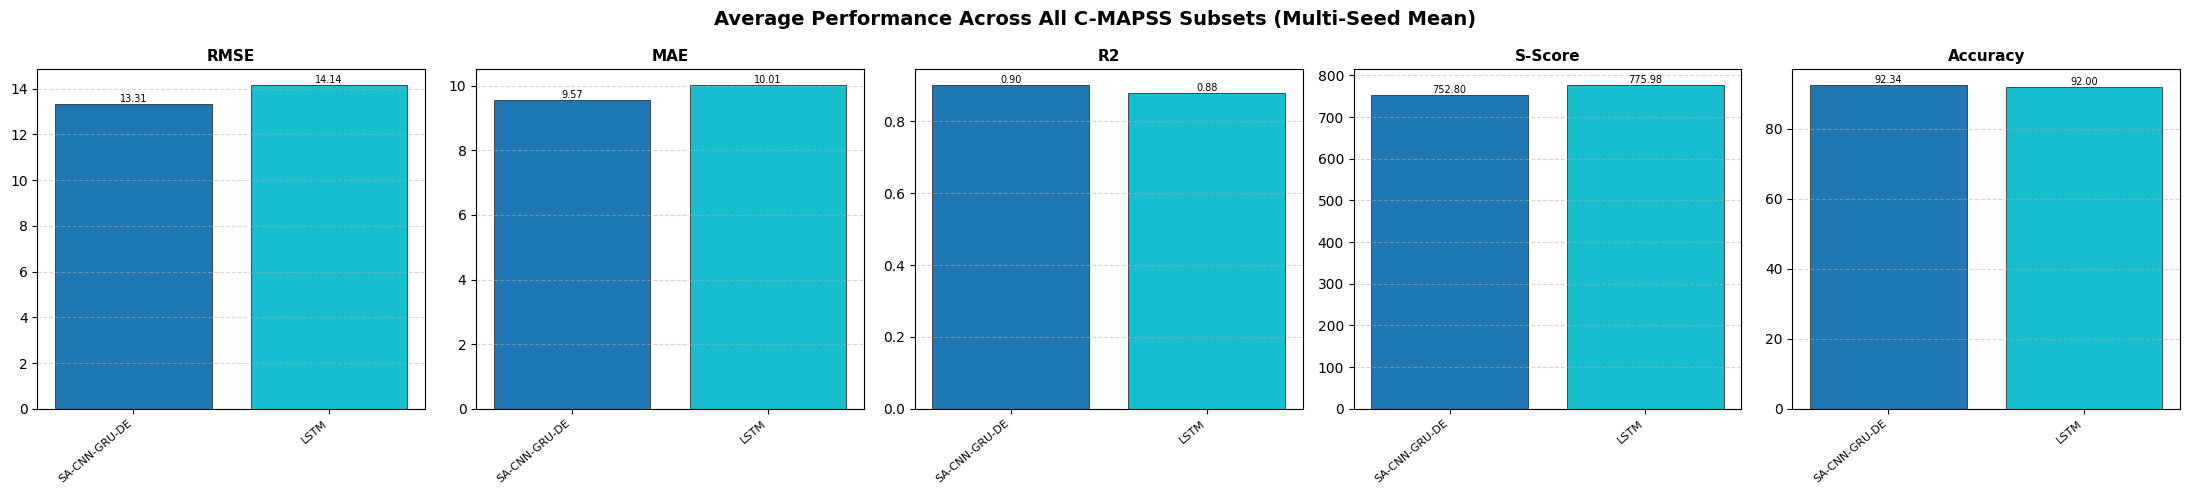

  Saved -> model_comparison_average_all_metrics_multiseed.png

Statistical significance of SA-CNN-GRU-DE vs. each baseline (paired t-test / Wilcoxon across the same 7 seeds) was computed in Section 10 — see `sig_df` / statistical_significance_vs_baselines.csv.


In [17]:
# ══════════════════════════════════════════════════════════════════════
# 14. MODEL COMPARISON — TABLE & PLOTS (Multi-Seed)
# ══════════════════════════════════════════════════════════════════════
METRICS_TO_COMPARE = ['RMSE', 'MAE', 'R2', 'S-Score', 'Accuracy']
DATASET_ORDER       = list(DATASET_CONFIGS.keys())
model_names         = list(MODEL_BUILDERS_ALL.keys())   # SA-CNN-GRU-DE first, then baselines

def _mean_std(model_name, dataset_name, metric):
    vals = multi_seed_metrics[model_name][dataset_name][metric]
    return float(np.mean(vals)), float(np.std(vals, ddof=1))

# --- Long-form table: rows = (Model, Dataset), columns = metrics (+ std) ---
rows = []
for model_name in model_names:
    for dataset_name in DATASET_ORDER:
        row = {'Model': model_name, 'Dataset': dataset_name}
        for metric in METRICS_TO_COMPARE:
            m, s = _mean_std(model_name, dataset_name, metric)
            row[metric] = m
            row[f'{metric}_std'] = s
        rows.append(row)

comparison_df = pd.DataFrame(rows)

print("\n PER-DATASET MODEL COMPARISON (mean over 7 seeds)")
print(comparison_df[['Model', 'Dataset'] + METRICS_TO_COMPARE].round(2).to_string(index=False))

# --- Averaged-across-datasets summary table ---
avg_df = comparison_df.groupby('Model')[METRICS_TO_COMPARE].mean().round(2)
avg_df = avg_df.reindex(model_names)
print("\n AVERAGE PERFORMANCE ACROSS ALL DATASETS (mean over 7 seeds, averaged over datasets)")
print(avg_df.to_string())

# --- Save tables for reference ---
comparison_df.to_csv('model_comparison_per_dataset_multiseed.csv', index=False)
avg_df.to_csv('model_comparison_average_multiseed.csv')
print("\nSaved -> model_comparison_per_dataset_multiseed.csv, model_comparison_average_multiseed.csv")

# --- Plots: grouped bar chart per metric, datasets on x-axis, models grouped, error bars = std ---
colours = plt.cm.tab10(np.linspace(0, 1, len(model_names)))

for metric in METRICS_TO_COMPARE:
    fig, ax = plt.subplots(figsize=(12, 6))
    n_models   = len(model_names)
    n_datasets = len(DATASET_ORDER)
    bar_width  = 0.8 / n_models
    x = np.arange(n_datasets)

    for i, model_name in enumerate(model_names):
        means = [_mean_std(model_name, ds, metric)[0] for ds in DATASET_ORDER]
        stds  = [_mean_std(model_name, ds, metric)[1] for ds in DATASET_ORDER]
        ax.bar(x + i * bar_width, means, width=bar_width, yerr=stds, capsize=3,
               label=model_name, color=colours[i], edgecolor='#333', linewidth=0.6)

    ax.set_xticks(x + bar_width * (n_models - 1) / 2)
    ax.set_xticklabels(DATASET_ORDER)
    ax.set_xlabel('Dataset', fontsize=11)
    ax.set_ylabel(f'{metric} (mean ± std over {N_SEEDS} seeds)', fontsize=11)
    ax.set_title(f'Model Comparison — {metric} by Dataset (Multi-Seed)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, frameon=True)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    fname = f'model_comparison_{metric.lower().replace("-", "_")}_multiseed.png'
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  Saved -> {fname}")

# --- Plot: average performance across all metrics, one bar-panel per metric ---
fig, axes = plt.subplots(1, len(METRICS_TO_COMPARE), figsize=(22, 5))
for ax, metric in zip(axes, METRICS_TO_COMPARE):
    vals = avg_df[metric].values
    bars = ax.bar(model_names, vals, color=colours, edgecolor='#333', linewidth=0.6)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=40, ha='right', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Average Performance Across All C-MAPSS Subsets (Multi-Seed Mean)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_average_all_metrics_multiseed.png', dpi=300, bbox_inches='tight')
plt.show()
print("  Saved -> model_comparison_average_all_metrics_multiseed.png")

print("\nStatistical significance of SA-CNN-GRU-DE vs. each baseline (paired t-test / Wilcoxon "
      "across the same 7 seeds) was computed in Section 10 — see `sig_df` / "
      "statistical_significance_vs_baselines.csv.")


## 15. Ablation Study (Multi-Seed Protocol + Statistical Significance)

The four ablated variants (M1-M4) are trained with the **same 7-seed protocol** as Section 8.
**M5 (the full architecture, SA-CNN-GRU-DE) is *not* retrained here** — its per-seed results are
pulled directly from Section 8/9 to save GPU time. A paired t-test and Wilcoxon signed-rank test
(across the 7 shared seeds) is reported for every variant against the full model.

In [18]:
# ══════════════════════════════════════════════════════════════════════
# ABLATION STUDY — fully self-contained (no relative imports)
# ══════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════
# 1.  ABLATION VARIANT MODELS
#     DualEncoderBlock is copied inline so there are no imports needed.
#     Every variant is anchored to SA-CNN-GRU-DE's (M5) exact
#     hyperparameters below, and only the single named component is
#     changed per variant. M1 is the one exception that needs care: a
#     single Conv1D branch is deliberately WIDENED to _D_MODEL so it still
#     hands attention/GRU/FC a 64-dim representation, isolating "two
#     receptive fields vs. one" from "less total capacity." M2-M4 are pure
#     component deletions/substitutions with no compensating width change,
#     so any remaining parameter-count difference from M5 is a direct,
#     disclosed consequence of the one component being tested.
# ══════════════════════════════════════════════════════════════════════

_CNN_CH     = 32          # per branch; matches SaCnnGruDE(cnn_channels=32)
_D_MODEL    = _CNN_CH * 2 # 64, matches SaCnnGruDE's post-concat width
_HEADS      = 4
_GRU_H      = 32          # matches SaCnnGruDE(gru_hidden=32)
_GRU_LAYERS = 2            # matches SaCnnGruDE's nn.GRU(num_layers=2)
_FC_H       = 32          # matches SaCnnGruDE(fc_hidden=32)
_SDROP, _ADROP, _RDROP, _FDROP = 0.3, 0.2, 0.3, 0.5   # match SaCnnGruDE's dropout rates


class _DualEncoderBlock(nn.Module):
    """Shared building block — two parallel Conv1D branches."""
    def __init__(self, n_features, out_channels=_CNN_CH, spatial_drop=_SDROP):
        super().__init__()
        self.conv_a  = nn.Conv1d(n_features, out_channels, kernel_size=3, padding=1)
        self.bn_a    = nn.BatchNorm1d(out_channels)
        self.sdrop_a = nn.Dropout2d(p=spatial_drop)
        self.conv_b  = nn.Conv1d(n_features, out_channels, kernel_size=7, padding=3)
        self.bn_b    = nn.BatchNorm1d(out_channels)
        self.sdrop_b = nn.Dropout2d(p=spatial_drop)
        self.relu    = nn.ReLU()

    def _branch(self, x, conv, bn, sdrop):
        x = self.relu(bn(conv(x)))
        x = sdrop(x.unsqueeze(3)).squeeze(3)
        return x

    def forward(self, x):
        x = x.permute(0, 2, 1)
        xa = self._branch(x, self.conv_a, self.bn_a, self.sdrop_a)
        xb = self._branch(x, self.conv_b, self.bn_b, self.sdrop_b)
        return torch.cat([xa, xb], dim=1).permute(0, 2, 1)


class M1_SingleEncoderGRU(nn.Module):
    """ABLATION: single Conv1D branch (kernel=3) instead of the dual k=3/k=7
    encoder, WIDENED to out_channels=_D_MODEL (64) so it still hands the
    same-width representation to attention/GRU/FC as the full model does.
    This isolates the effect of having two parallel receptive fields vs.
    one, rather than confounding it with an unrelated width change —
    attention, GRU (2-layer, bidirectional, hidden=32) and the FC head are
    all identical in size to M5."""
    def __init__(self, seq_length, n_features,
                 cnn_ch=_D_MODEL, heads=_HEADS, gru_h=_GRU_H, gru_layers=_GRU_LAYERS,
                 fc_h=_FC_H, sdrop=_SDROP, adrop=_ADROP, gdrop=_RDROP, fdrop=_FDROP):
        super().__init__()
        self.conv  = nn.Conv1d(n_features, cnn_ch, kernel_size=3, padding=1)
        self.bn    = nn.BatchNorm1d(cnn_ch)
        self.sdrop = nn.Dropout2d(p=sdrop)
        self.relu  = nn.ReLU()
        self.attn  = nn.MultiheadAttention(cnn_ch, heads, dropout=adrop, batch_first=True)
        self.norm  = nn.LayerNorm(cnn_ch)
        self.gru   = nn.GRU(cnn_ch, gru_h, num_layers=gru_layers, batch_first=True, bidirectional=True)
        self.gdrop = nn.Dropout(p=gdrop)
        self.fc1   = nn.Linear(gru_h * 2, fc_h)
        self.bn2   = nn.BatchNorm1d(fc_h)
        self.fdrop = nn.Dropout(p=fdrop)
        self.fc2   = nn.Linear(fc_h, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.bn(self.conv(x)))
        x = self.sdrop(x.unsqueeze(3)).squeeze(3)
        x = x.permute(0, 2, 1)
        a, _ = self.attn(x, x, x)
        x = self.norm(x + a)
        x, _ = self.gru(x)
        x = self.gdrop(x)[:, -1, :]
        x = self.relu(self.bn2(self.fc1(x)))
        return self.fc2(self.fdrop(x))


class M2_DualEncNoAttnGRU(nn.Module):
    """ABLATION: dual encoder (unchanged, matches M5) feeding directly into
    the same 2-layer bidirectional GRU + FC head — self-attention and its
    LayerNorm are removed entirely, with no compensating width change
    elsewhere. This is a pure component deletion: parameter count is
    exactly M5's minus the attention block's own parameters."""
    def __init__(self, seq_length, n_features,
                 cnn_ch=_CNN_CH, gru_h=_GRU_H, gru_layers=_GRU_LAYERS, fc_h=_FC_H,
                 sdrop=_SDROP, gdrop=_RDROP, fdrop=_FDROP):
        super().__init__()
        self.enc   = _DualEncoderBlock(n_features, cnn_ch, sdrop)
        self.gru   = nn.GRU(cnn_ch * 2, gru_h, num_layers=gru_layers, batch_first=True, bidirectional=True)
        self.gdrop = nn.Dropout(p=gdrop)
        self.fc1   = nn.Linear(gru_h * 2, fc_h)
        self.bn    = nn.BatchNorm1d(fc_h)
        self.fdrop = nn.Dropout(p=fdrop)
        self.fc2   = nn.Linear(fc_h, 1)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.enc(x)
        x, _ = self.gru(x)
        x = self.gdrop(x)[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        return self.fc2(self.fdrop(x))


class M3_DualEncAttnUniGRU(nn.Module):
    """ABLATION: identical dual encoder + attention as M5, but the GRU is
    UNIDIRECTIONAL instead of bidirectional (still 2 layers, still
    hidden=32 — no compensating widening). This is a pure component
    deletion: it naturally has FEWER parameters than M5 (roughly half the
    GRU block, plus a narrower FC1 input), which is the expected direction
    for removing bidirectionality rather than an inflated variant."""
    def __init__(self, seq_length, n_features,
                 cnn_ch=_CNN_CH, heads=_HEADS, gru_h=_GRU_H, gru_layers=_GRU_LAYERS,
                 fc_h=_FC_H, sdrop=_SDROP, adrop=_ADROP, gdrop=_RDROP, fdrop=_FDROP):
        super().__init__()
        self.enc   = _DualEncoderBlock(n_features, cnn_ch, sdrop)
        d = cnn_ch * 2
        self.attn  = nn.MultiheadAttention(d, heads, dropout=adrop, batch_first=True)
        self.norm  = nn.LayerNorm(d)
        self.gru   = nn.GRU(d, gru_h, num_layers=gru_layers, batch_first=True, bidirectional=False)
        self.gdrop = nn.Dropout(p=gdrop)
        self.fc1   = nn.Linear(gru_h, fc_h)
        self.bn    = nn.BatchNorm1d(fc_h)
        self.fdrop = nn.Dropout(p=fdrop)
        self.fc2   = nn.Linear(fc_h, 1)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.enc(x)
        a, _ = self.attn(x, x, x)
        x = self.norm(x + a)
        x, _ = self.gru(x)
        x = self.gdrop(x)[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        return self.fc2(self.fdrop(x))


class M4_DualEncAttnBiLSTM(nn.Module):
    """ABLATION: identical dual encoder + attention as M5, with the GRU
    replaced by an LSTM of the SAME hidden size (32), SAME depth (2 layers)
    and SAME bidirectionality — no other width change. An LSTM cell has 4
    gates vs. a GRU cell's 3, so at matched hidden size/depth this variant
    has intrinsically ~1.2-1.3x M5's parameter count; that increase is a
    direct, disclosed, and unavoidable consequence of comparing GRU vs.
    LSTM at equal capacity settings (not an arbitrary width inflation)."""
    def __init__(self, seq_length, n_features,
                 cnn_ch=_CNN_CH, heads=_HEADS, lstm_h=_GRU_H, lstm_layers=_GRU_LAYERS,
                 fc_h=_FC_H, sdrop=_SDROP, adrop=_ADROP, ldrop=_RDROP, fdrop=_FDROP):
        super().__init__()
        self.enc   = _DualEncoderBlock(n_features, cnn_ch, sdrop)
        d = cnn_ch * 2
        self.attn  = nn.MultiheadAttention(d, heads, dropout=adrop, batch_first=True)
        self.norm  = nn.LayerNorm(d)
        self.lstm  = nn.LSTM(d, lstm_h, num_layers=lstm_layers, batch_first=True, bidirectional=True)
        self.ldrop = nn.Dropout(p=ldrop)
        self.fc1   = nn.Linear(lstm_h * 2, fc_h)
        self.bn    = nn.BatchNorm1d(fc_h)
        self.fdrop = nn.Dropout(p=fdrop)
        self.fc2   = nn.Linear(fc_h, 1)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.enc(x)
        a, _ = self.attn(x, x, x)
        x = self.norm(x + a)
        x, _ = self.lstm(x)
        x = self.ldrop(x)[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        return self.fc2(self.fdrop(x))


# Registry of TRAINABLE ablation variants (M1-M4). M5 = the full architecture
# (SA-CNN-GRU-DE) is intentionally excluded — its results are reused from
# Section 8/9 instead of being retrained (see Section 3 below).
ABLATION_TRAINABLE_VARIANTS = {
    'M1_NoDualEnc':   lambda sl, nf: M1_SingleEncoderGRU(sl, nf),
    'M2_NoAttention': lambda sl, nf: M2_DualEncNoAttnGRU(sl, nf),
    'M3_UniGRU':      lambda sl, nf: M3_DualEncAttnUniGRU(sl, nf),
    'M4_BiLSTM':      lambda sl, nf: M4_DualEncAttnBiLSTM(sl, nf),
}

VARIANT_ORDER  = ['M1_NoDualEnc', 'M2_NoAttention', 'M3_UniGRU', 'M4_BiLSTM', 'M5_FullModel']
VARIANT_COLORS = ['#888780', '#AFA9EC', '#AFA9EC', '#AFA9EC', '#1D9E75']


# ══════════════════════════════════════════════════════════════════════
# 2.  TRAINING & INFERENCE HELPERS
# ══════════════════════════════════════════════════════════════════════

def _get_criterion(loss_func):
    return nn.HuberLoss(delta=15.0) if loss_func == 'huber' else nn.MSELoss()


def _train(model, criterion, X_train, y_train, seed,
           X_val=None, y_val=None,
           batch_size=32, epochs=100, val_split=0.2,
           patience=20, lr=0.0005, lr_patience=10, lr_factor=0.5, min_lr=1e-7):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=lr_patience, min_lr=min_lr)

    X_t = torch.tensor(X_train)
    y_t = torch.tensor(y_train).unsqueeze(1)
    train_ds = TensorDataset(X_t, y_t)
    n_train  = len(train_ds)

    if X_val is not None and y_val is not None:
        # Engine-level split supplied upstream (create_train_val_sequences) --
        # use it directly instead of re-splitting the pooled window array.
        Xv_t   = torch.tensor(X_val)
        yv_t   = torch.tensor(y_val).unsqueeze(1)
        val_ds = TensorDataset(Xv_t, yv_t)
        n_val  = len(val_ds)
    else:
        # Legacy fallback (window-level random split) -- kept only for
        # backward compatibility; not used by the current pipeline.
        ds  = TensorDataset(X_t, y_t)
        n_val   = int(len(ds) * val_split)
        n_train = len(ds) - n_val
        train_ds, val_ds = random_split(
            ds, [n_train, n_val],
            generator=torch.Generator().manual_seed(seed))

    # drop_last=True on the TRAINING loader only -- see train_model() for
    # why (BatchNorm1d cannot train on a final batch of size 1).
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)

    best_val, best_wts, no_imp = float('inf'), None, 0

    for _ in range(epochs):
        model.train()
        for Xb, yb in train_dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for Xb, yb in val_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                vl += criterion(model(Xb), yb).item() * len(Xb)
        vl /= n_val
        scheduler.step(vl)

        if vl < best_val:
            best_val = vl
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                break

    if best_wts:
        model.load_state_dict(best_wts)


@torch.no_grad()
def _infer(model, X_np, batch_size=512):
    model.eval()
    X_t = torch.tensor(X_np)
    out = [model(X_t[i:i+batch_size].to(DEVICE)).cpu().numpy()
           for i in range(0, len(X_t), batch_size)]
    return np.concatenate(out).flatten()


In [19]:
# ══════════════════════════════════════════════════════════════════════
# 3.  MAIN ABLATION LOOP — multi-seed for M1-M4; M5 reused from Section 8/9
# ══════════════════════════════════════════════════════════════════════

def run_ablation_study(dataset_names=None, variants=None, save_dir='./ablation_results'):
    os.makedirs(save_dir, exist_ok=True)
    if dataset_names is None:
        dataset_names = list(DATASET_CONFIGS.keys())
    if variants is None:
        variants = ABLATION_TRAINABLE_VARIANTS

    raw_records = []   # one row per (variant, dataset, seed)
    # ablation_seed_metrics[variant][dataset][metric] -> list of per-seed values
    ablation_seed_metrics = {
        v: {ds: {m: [] for m in ['RMSE', 'MAE', 'R2', 'S_Score', 'Accuracy']}
            for ds in dataset_names}
        for v in variants
    }
    # ablation_trained_models[variant][dataset] -> list of 7 seed-trained models.
    # Kept (not deleted) so the cross-dataset generalisation cell can reuse them
    # directly instead of retraining M1-M4 from scratch.
    ablation_trained_models = {v: {ds: [] for ds in dataset_names} for v in variants}

    for dataset_name in dataset_names:
        config = DATASET_CONFIGS[dataset_name]
        print(f"\n{'━'*55}\n  Dataset: {dataset_name}\n{'━'*55}")

        train_df, test_df, y_test_df = load_data(dataset_name)
        train_df = add_rul(train_df)
        train_df, test_df, _ = scale_data_strict(train_df, test_df, config)
        train_df = apply_smoothing(train_df, config['alpha'])
        test_df  = apply_smoothing(test_df,  config['alpha'])

        sl = config['seq_length']
        # Engine-level split (same split_seed=SEED convention as Section 8,
        # so every variant and every one of the 7 training seeds sees the
        # same train/val partition -- and it is now identical in kind to
        # what Section 8 uses, resolving the earlier per-seed-split
        # inconsistency between the two sections).
        X_train, y_train, X_val, y_val = create_train_val_sequences(
            train_df, sl, val_split=0.2, split_seed=SEED)
        X_test            = prepare_test(test_df, sl)
        y_true            = np.clip(y_test_df['RUL'].values, 0, 125)
        criterion         = _get_criterion(config['loss_func'])

        for vname, constructor in variants.items():
            print(f"\n  ▸ {vname}")

            for seed in SEEDS:
                reset_seeds(seed)

                model    = constructor(sl, len(features)).to(DEVICE)
                n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

                _train(model, criterion, X_train, y_train, seed,
                       X_val=X_val, y_val=y_val,
                       batch_size=config['batch_size'],
                       epochs=100, patience=20,
                       lr=0.0005, lr_patience=10,
                       lr_factor=0.5, min_lr=1e-7)

                y_pred = np.clip(_infer(model, X_test), 0, 125)

                rec = dict(
                    dataset=dataset_name, variant=vname, seed=seed,
                    n_params=n_params,
                    RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
                    MAE=float(mean_absolute_error(y_true, y_pred)),
                    R2=float(r2_score(y_true, y_pred)),
                    S_Score=float(compute_s_score(y_true, y_pred)),
                    Accuracy=float(compute_accuracy(y_true, y_pred)),
                )
                raw_records.append(rec)
                for m in ['RMSE', 'MAE', 'R2', 'S_Score', 'Accuracy']:
                    ablation_seed_metrics[vname][dataset_name][m].append(rec[m])
                ablation_trained_models[vname][dataset_name].append(model)

                print(f"    seed={seed:<5d}  RMSE={rec['RMSE']:.2f}  "
                      f"MAE={rec['MAE']:.2f}  R²={rec['R2']:.4f}")

    # ── Fold in M5_FullModel from the already-trained Section 8/9 results ──
    # (No retraining — SA-CNN-GRU-DE was already trained with these exact
    #  7 seeds in Section 8.)
    ablation_seed_metrics['M5_FullModel'] = {}
    for dataset_name in dataset_names:
        # seed-42 model, straight from Section 8's multi_seed_models
        # (SEEDS[0] == 42) -- avoids depending on the disabled Section 11
        # cell, which used to be the only place all_models[] was built.
        _m5_ref_model = multi_seed_models['SA-CNN-GRU-DE'][dataset_name][0]
        n_params_full = sum(p.numel() for p in _m5_ref_model.parameters()
                             if p.requires_grad)
        rmse_list = multi_seed_metrics['SA-CNN-GRU-DE'][dataset_name]['RMSE']
        mae_list  = multi_seed_metrics['SA-CNN-GRU-DE'][dataset_name]['MAE']
        r2_list   = multi_seed_metrics['SA-CNN-GRU-DE'][dataset_name]['R2']
        s_list    = multi_seed_metrics['SA-CNN-GRU-DE'][dataset_name]['S-Score']
        acc_list  = multi_seed_metrics['SA-CNN-GRU-DE'][dataset_name]['Accuracy']

        ablation_seed_metrics['M5_FullModel'][dataset_name] = {
            'RMSE': rmse_list, 'MAE': mae_list, 'R2': r2_list,
            'S_Score': s_list, 'Accuracy': acc_list,
        }

        for seed, r, m, r2v, s, a in zip(SEEDS, rmse_list, mae_list, r2_list, s_list, acc_list):
            raw_records.append(dict(
                dataset=dataset_name, variant='M5_FullModel', seed=seed,
                n_params=n_params_full,
                RMSE=r, MAE=m, R2=r2v, S_Score=s, Accuracy=a,
            ))

    df  = pd.DataFrame(raw_records)
    agg = (df.groupby(['variant', 'dataset'])
             [['RMSE', 'MAE', 'R2', 'S_Score', 'Accuracy', 'n_params']]
             .agg(['mean', 'std'])
             .round(3))

    agg.to_csv(os.path.join(save_dir, 'ablation_summary_multiseed.csv'))
    return agg, raw_records, ablation_seed_metrics, ablation_trained_models


In [20]:
# ══════════════════════════════════════════════════════════════════════
# 4.  PLOTS
# ══════════════════════════════════════════════════════════════════════

def plot_metric_comparison(raw_records, metric='RMSE', save_dir='./ablation_results'):
    df       = pd.DataFrame(raw_records)
    datasets = sorted(df['dataset'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for idx, ds in enumerate(datasets):
        ax   = axes[idx]
        grp  = df[df['dataset'] == ds].groupby('variant')[metric]
        mean = grp.mean().reindex(VARIANT_ORDER)
        std  = grp.std().reindex(VARIANT_ORDER)

        x = np.arange(len(VARIANT_ORDER))
        bars = ax.bar(x, mean, yerr=std, capsize=3, color=VARIANT_COLORS, width=0.6)
        ax.set_title(ds, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([v.replace('_', '\n') for v in VARIANT_ORDER], fontsize=8)
        ax.set_ylabel(f'{metric} (mean ± std, {N_SEEDS} seeds)', fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        for bar, value in zip(bars, mean):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.2,
                    f"{value:.2f}",
                    ha='center', va='bottom', fontsize=7.5)

    fig.suptitle(f'Ablation — {metric} (Multi-Seed)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    path = os.path.join(save_dir, f'ablation_{metric.lower()}.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_delta_heatmap(agg_df, metric='RMSE', save_dir='./ablation_results'):
    datasets = ['FD001', 'FD002', 'FD003', 'FD004']
    variants = [v for v in VARIANT_ORDER if v != 'M5_FullModel']

    full = {ds: agg_df.loc[('M5_FullModel', ds), (metric, 'mean')]
            for ds in datasets}

    matrix = np.array([
        [agg_df.loc[(v, ds), (metric, 'mean')] - full[ds]
         for ds in datasets]
        for v in variants
    ])

    fig, ax = plt.subplots(figsize=(8, 5))
    vmax = max(np.abs(matrix).max(), 0.5)
    im   = ax.imshow(matrix, cmap='RdYlGn_r', vmin=-vmax, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(datasets)))
    ax.set_xticklabels(datasets, fontsize=11)
    ax.set_yticks(range(len(variants)))
    ax.set_yticklabels([v.replace('_', ' ') for v in variants], fontsize=10)

    for i in range(len(variants)):
        for j in range(len(datasets)):
            ax.text(j, i, f'{matrix[i,j]:+.2f}',
                    ha='center', va='center', fontsize=10,
                    color='#111' if abs(matrix[i,j]) < vmax * 0.6 else 'white')

    plt.colorbar(im, ax=ax, label=f'Δ{metric} vs M5 full model')
    ax.set_title(f'Δ{metric}: variant − M5  (positive = worse; means over {N_SEEDS} seeds)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(save_dir, f'ablation_delta_{metric.lower()}.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_param_efficiency(raw_records, metric='RMSE', save_dir='./ablation_results'):
    df  = pd.DataFrame(raw_records)
    agg = (df.groupby(['variant', 'dataset'])
             .agg(mean_metric=(metric, 'mean'), mean_params=('n_params', 'mean'))
             .reset_index())

    markers  = ['o', 's', 'D', '^']
    datasets = sorted(agg['dataset'].unique())
    fig, ax  = plt.subplots(figsize=(9, 5))

    for var, grp in agg.groupby('variant'):
        col = VARIANT_COLORS[VARIANT_ORDER.index(var)]
        for j, ds in enumerate(datasets):
            row = grp[grp['dataset'] == ds]
            if row.empty:
                continue
            ax.scatter(row['mean_params'].values[0] / 1e3,
                       row['mean_metric'].values[0],
                       color=col, marker=markers[j], s=90, zorder=3)
            ax.annotate(f"{var.split('_')[0]}/{ds}",
                        xy=(row['mean_params'].values[0] / 1e3,
                            row['mean_metric'].values[0]),
                        fontsize=7, xytext=(4, 4), textcoords='offset points')

    ax.set_xlabel('Trainable parameters (×10³)', fontsize=11)
    ax.set_ylabel(f'Mean {metric}', fontsize=11)
    ax.set_title(f'Parameter efficiency — {metric} vs model size (Multi-Seed Mean)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    path = os.path.join(save_dir, f'ablation_param_efficiency.png')
    plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


def print_ablation_table(agg_df):
    metrics  = ['RMSE', 'MAE', 'R2', 'S_Score', 'Accuracy']
    datasets = ['FD001', 'FD002', 'FD003', 'FD004']
    for ds in datasets:
        print(f"\n{'─'*72}\n  {ds}\n{'─'*72}")
        print(f"{'Variant':<22}" + "".join(f"{m:>14}" for m in metrics))
        print('─' * 72)
        for var in VARIANT_ORDER:
            row = f"{var:<22}"
            for m in metrics:
                mn = agg_df.loc[(var, ds), (m, 'mean')]
                row += f"  {mn:>12.2f}"
            print(row)


def sig_stars(p):
    """Significance-level marker for a p-value (matches Section 10's convention)."""
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def ablation_significance(ablation_seed_metrics, save_dir='./ablation_results'):
    """Paired t-test + Wilcoxon signed-rank test (across the same 7 seeds)
    for every ablated variant (M1-M4) vs. the full model (M5 / SA-CNN-GRU-DE)."""
    sig_rows = []
    for variant in VARIANT_ORDER:
        if variant == 'M5_FullModel':
            continue
        for metric_key, metric_label in [('RMSE', 'RMSE'), ('MAE', 'MAE'), ('S_Score', 'S-Score')]:
            for ds in DATASET_CONFIGS:
                a = np.array(ablation_seed_metrics['M5_FullModel'][ds][metric_key])
                b = np.array(ablation_seed_metrics[variant][ds][metric_key])
                t_stat, t_p = stats.ttest_rel(a, b)
                try:
                    w_stat, w_p = stats.wilcoxon(a, b)
                except ValueError:
                    w_stat, w_p = np.nan, np.nan
                sig_rows.append({
                    'Variant': variant, 'Metric': metric_label, 'Dataset': ds,
                    'M5_FullModel_mean': a.mean(), f'{variant}_mean': b.mean(),
                    't_stat': t_stat, 't_pvalue': t_p,
                    'wilcoxon_stat': w_stat, 'wilcoxon_pvalue': w_p,
                })

            a_all = np.concatenate([ablation_seed_metrics['M5_FullModel'][ds][metric_key]
                                     for ds in DATASET_CONFIGS])
            b_all = np.concatenate([ablation_seed_metrics[variant][ds][metric_key]
                                     for ds in DATASET_CONFIGS])
            t_stat, t_p = stats.ttest_rel(a_all, b_all)
            try:
                w_stat, w_p = stats.wilcoxon(a_all, b_all)
            except ValueError:
                w_stat, w_p = np.nan, np.nan
            sig_rows.append({
                'Variant': variant, 'Metric': metric_label, 'Dataset': 'ALL (pooled)',
                'M5_FullModel_mean': a_all.mean(), f'{variant}_mean': b_all.mean(),
                't_stat': t_stat, 't_pvalue': t_p,
                'wilcoxon_stat': w_stat, 'wilcoxon_pvalue': w_p,
            })

    sig_df = pd.DataFrame(sig_rows)
    sig_df['t_sig']        = sig_df['t_pvalue'].apply(sig_stars)
    sig_df['wilcoxon_sig'] = sig_df['wilcoxon_pvalue'].apply(sig_stars)

    print("\n STATISTICAL SIGNIFICANCE: Ablation Variants vs. M5_FullModel (SA-CNN-GRU-DE)")
    print(f"  (paired t-test & Wilcoxon signed-rank test across {N_SEEDS} shared seeds; "
          "* p<.05  ** p<.01  *** p<.001  n.s.=not significant)")
    print(sig_df.round(4).to_string(index=False))
    sig_df.to_csv(os.path.join(save_dir, 'ablation_statistical_significance.csv'), index=False)
    print("\nSaved -> ablation_results/ablation_statistical_significance.csv")
    return sig_df



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset: FD001
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
Scaling Complete

  ▸ M1_NoDualEnc
    seed=42     RMSE=12.48  MAE=9.05  R²=0.9031
    seed=123    RMSE=13.88  MAE=10.08  R²=0.8800
    seed=7      RMSE=13.17  MAE=9.49  R²=0.8920
    seed=99     RMSE=12.42  MAE=9.19  R²=0.9040
    seed=1      RMSE=11.99  MAE=9.26  R²=0.9105

  ▸ M2_NoAttention
    seed=42     RMSE=12.58  MAE=9.77  R²=0.9014
    seed=123    RMSE=12.61  MAE=9.27  R²=0.9010
    seed=7      RMSE=12.77  MAE=9.72  R²=0.8985
    seed=99     RMSE=13.72  MAE=10.06  R²=0.8828
    seed=1      RMSE=12.88  MAE=9.76  R²=0.8967

  ▸ M3_UniGRU
    seed=42     RMSE=12.76  MAE=9.27  R²=0.8987
    seed=123    RMSE=12.98  MAE=9.62  R²=0.8951
    seed=7      RMSE=12.51  MAE=9.37  R²=0.9026
    seed=99     RMSE=13.31  MAE=9.85  R²=0.8897
    seed=1      RMSE=13.57  MAE=9.67  R²=0.8854

  ▸ M4_BiLSTM
    seed=4

/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5 -1.  -0.5 ...  1.5  1.5  1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete

  ▸ M1_NoDualEnc
    seed=42     RMSE=13.05  MAE=9.33  R²=0.9077
    seed=123    RMSE=12.71  MAE=9.63  R²=0.9123
    seed=7      RMSE=13.45  MAE=9.66  R²=0.9019
    seed=99     RMSE=13.11  MAE=9.84  R²=0.9068
    seed=1      RMSE=12.20  MAE=8.97  R²=0.9192

  ▸ M2_NoAttention
    seed=42     RMSE=13.51  MAE=9.98  R²=0.9010
    seed=123    RMSE=12.94  MAE=9.51  R²=0.9092
    seed=7      RMSE=13.56  MAE=10.38  R²=0.9002
    seed=99     RMSE=12.80  MAE=9.04  R²=0.9112
    seed=1      RMSE=13.79  MAE=10.58  R²=0.8969

  ▸ M3_UniGRU
    seed=42     RMSE=13.02  MAE=9.64  R²=0.9081
    seed=123    RMSE=13.07  MAE=9.79  R²=0.9074
    seed=7      RMSE=13.22  MAE=9.82  R²=0.9052
    seed=99     RMSE=13.04  MAE=9.54  R²=0.9077
    seed=1      RMSE=13.21  MAE=9.94  R²=0.9054

  ▸ M4_BiLSTM
    seed=42     RMSE=13.79  MAE=10.47  R²=0.8968
    seed=123    RMSE=13.16  MAE=9.30  R²=0.9061
    seed=7      RMSE=12.94  MAE=9.51  R²=0.9092
    seed=99     RMSE=12.79  MAE=9.42  R²=0.9113


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.         -0.33333333 -0.66666667 ...  1.33333333  1.
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.66666667 -0.66666667 -0.66666667 ...  0.66666667  0.66666667
  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete

  ▸ M1_NoDualEnc
    seed=42     RMSE=15.28  MAE=10.82  R²=0.8735
    seed=123    RMSE=14.73  MAE=10.60  R²=0.8826
    seed=7      RMSE=14.52  MAE=10.55  R²=0.8859
    seed=99     RMSE=14.04  MAE=9.92  R²=0.8934
    seed=1      RMSE=15.02  MAE=10.68  R²=0.8778

  ▸ M2_NoAttention
    seed=42     RMSE=15.71  MAE=11.82  R²=0.8664
    seed=123    RMSE=16.10  MAE=12.10  R²=0.8597
    seed=7      RMSE=15.01  MAE=11.39  R²=0.8780
    seed=99     RMSE=14.03  MAE=10.02  R²=0.8935
    seed=1      RMSE=14.67  MAE=10.21  R²=0.8835

  ▸ M3_UniGRU
    seed=42     RMSE=14.48  MAE=10.67  R²=0.8865
    seed=123    RMSE=14.11  MAE=10.20  R²=0.8922
    seed=7      RMSE=15.30  MAE=10.77  R²=0.8732
    seed=99     RMSE=14.29  MAE=9.76  R²=0.8895
    seed=1      RMSE=14.96  MAE=11.22  R²=0.8788

  ▸ M4_BiLSTM
    seed=42     RMSE=15.28  MAE=10.47  R²=0.8737
    seed=123    RMSE=14.65  MAE=9.96  R²=0.8839
    seed=7      RMSE=14.84  MAE=10.63  R²=0.8807
    seed=99     RMSE=14.76  MAE=10.2

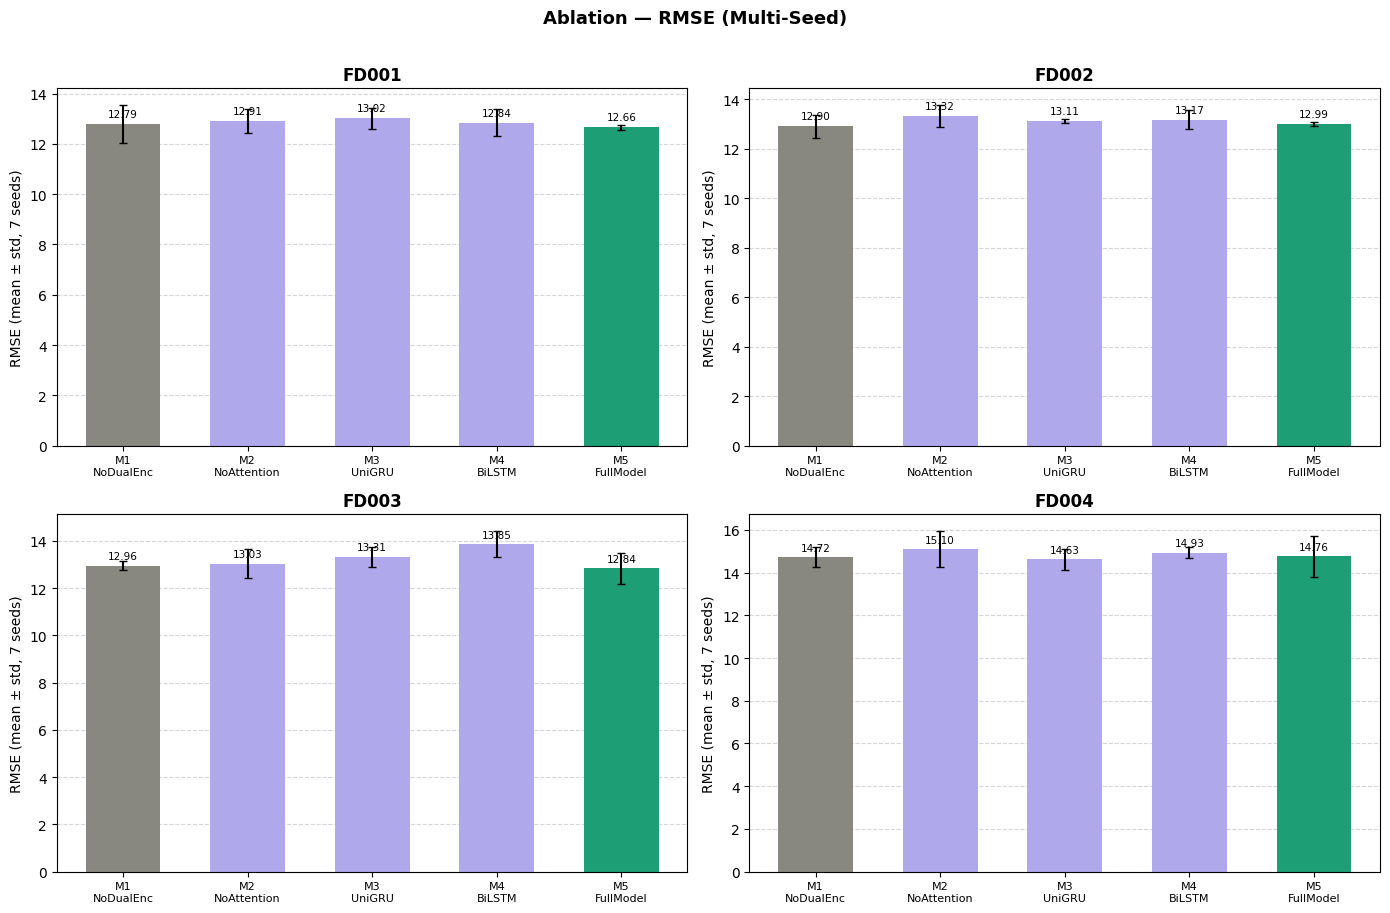

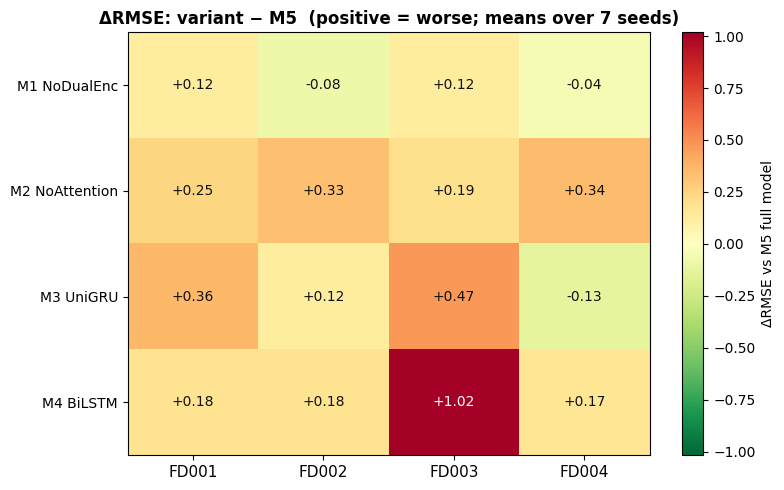

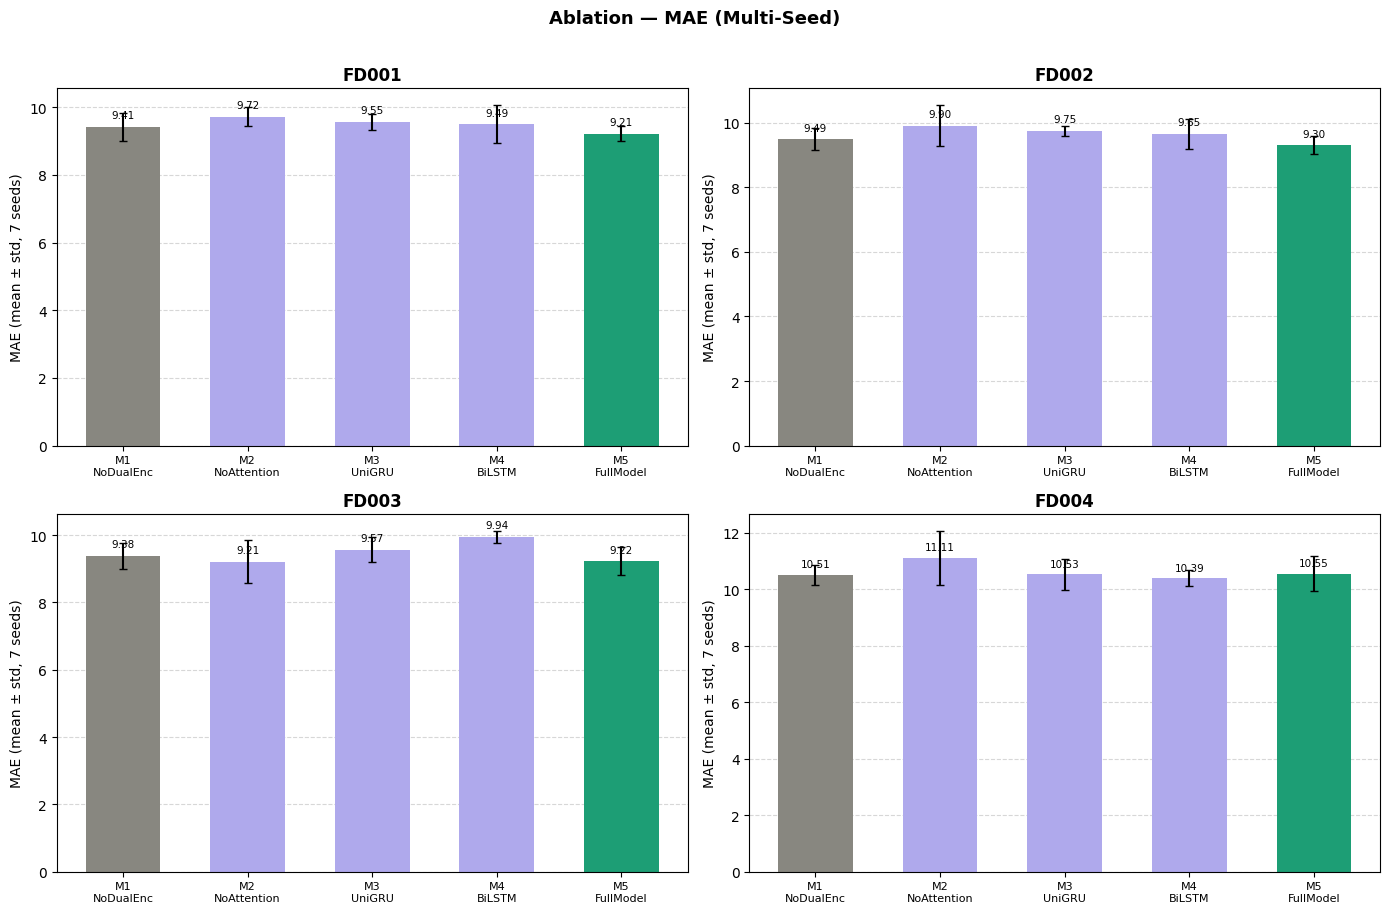

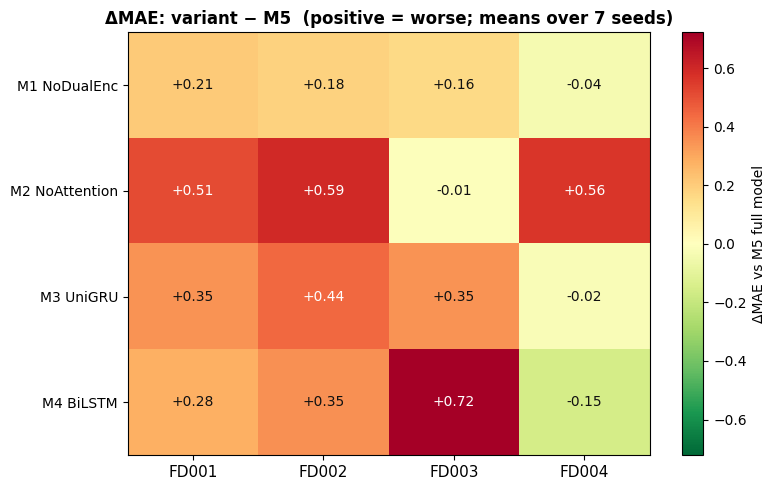

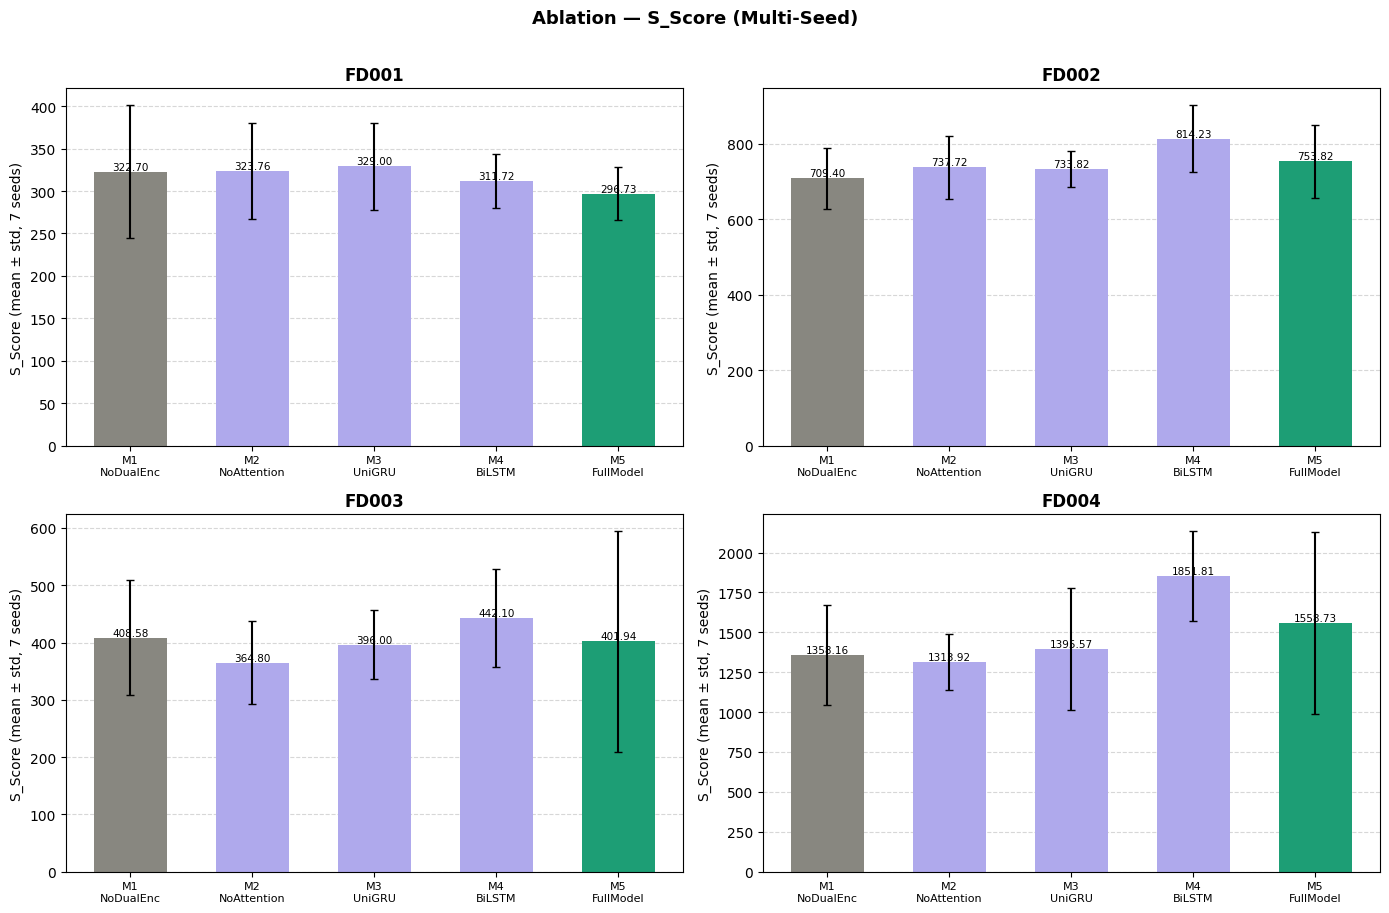

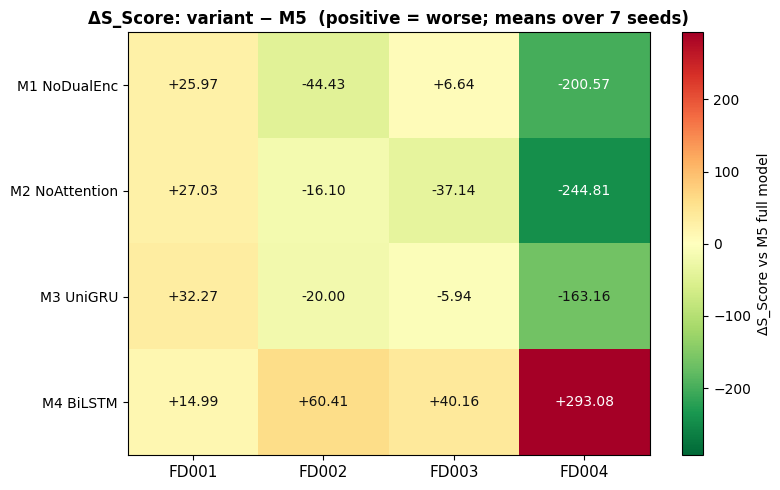

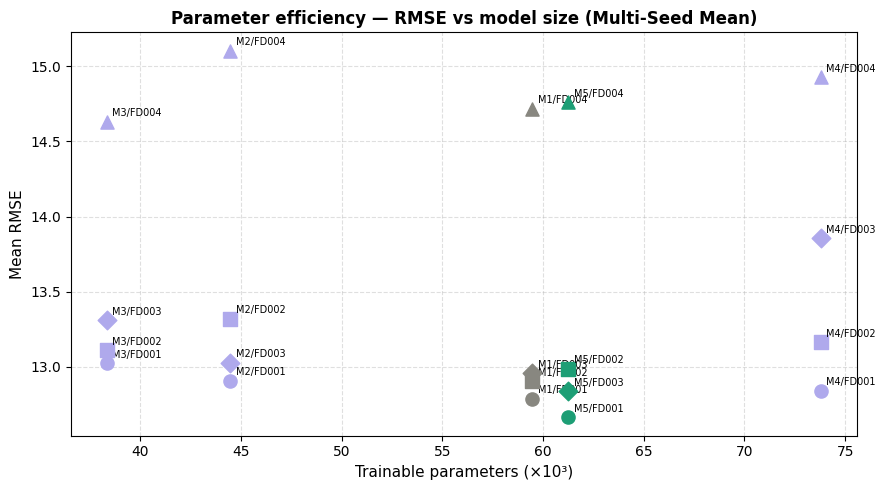


 STATISTICAL SIGNIFICANCE: Ablation Variants vs. M5_FullModel (SA-CNN-GRU-DE)
  (paired t-test & Wilcoxon signed-rank test across 7 shared seeds; * p<.05  ** p<.01  *** p<.001  n.s.=not significant)
       Variant  Metric      Dataset  M5_FullModel_mean  M1_NoDualEnc_mean  t_stat  t_pvalue  wilcoxon_stat  wilcoxon_pvalue  M2_NoAttention_mean  M3_UniGRU_mean  M4_BiLSTM_mean t_sig wilcoxon_sig
  M1_NoDualEnc    RMSE        FD001            12.6645            12.7865 -0.3906    0.7160            7.0           1.0000                  NaN             NaN             NaN  n.s.         n.s.
  M1_NoDualEnc    RMSE        FD002            12.9879            12.9035  0.4041    0.7068            7.0           1.0000                  NaN             NaN             NaN  n.s.         n.s.
  M1_NoDualEnc    RMSE        FD003            12.8372            12.9580 -0.3427    0.7490            6.0           0.8125                  NaN             NaN             NaN  n.s.         n.s.
  M1_NoDualEnc  

In [21]:
# ══════════════════════════════════════════════════════════════════════
# 5.  RUN
# ══════════════════════════════════════════════════════════════════════

agg_results, raw, ablation_seed_metrics, ablation_trained_models = run_ablation_study(
    dataset_names=['FD001', 'FD002', 'FD003', 'FD004'],
    save_dir='./ablation_results'
)

print_ablation_table(agg_results)

for metric in ['RMSE', 'MAE', 'S_Score']:
    plot_metric_comparison(raw, metric=metric)
    plot_delta_heatmap(agg_results, metric=metric)

plot_param_efficiency(raw, metric='RMSE')

ablation_sig_df = ablation_significance(ablation_seed_metrics)


## 15b. Cross-Dataset Generalisation — Ablation Variants
For each ablation variant (M1-M4), reuse the 7-seed models already trained per dataset in Section 15's ablation study (no retraining) and evaluate every (source, target) pair on all four datasets, using the exact same source-scaler-correction methodology as Section 13. M5 (the full model) reuses the models already trained in Section 8.

FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
FD002 Loaded — Train: (53759, 26), Test: (33991, 26)
FD003 Loaded — Train: (24720, 26), Test: (16596, 26)
FD004 Loaded — Train: (61249, 26), Test: (41214, 26)
Raw (unscaled) test sets loaded.

  ▸ M1_NoDualEnc: reusing {'FD001': 5, 'FD002': 5, 'FD003': 5, 'FD004': 5} seed models per dataset (no retraining)
  ▸ M2_NoAttention: reusing {'FD001': 5, 'FD002': 5, 'FD003': 5, 'FD004': 5} seed models per dataset (no retraining)
  ▸ M3_UniGRU: reusing {'FD001': 5, 'FD002': 5, 'FD003': 5, 'FD004': 5} seed models per dataset (no retraining)
  ▸ M4_BiLSTM: reusing {'FD001': 5, 'FD002': 5, 'FD003': 5, 'FD004': 5} seed models per dataset (no retraining)
  ▸ M5_FullModel: reusing {'FD001': 5, 'FD002': 5, 'FD003': 5, 'FD004': 5} seed models per dataset (no retraining)

All variant models ready for cross-dataset evaluation (reused, not retrained).


/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5  0.   0.  ...  1.   1.   1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.  -1.  -1.  ...  0.5  1.  -0.5]' has dtype incompatible with int64, please explicitly cast to a c

  ✓ Cross-dataset evaluation complete for M1_NoDualEnc


/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5  0.   0.  ...  1.   1.   1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.  -1.  -1.  ...  0.5  1.  -0.5]' has dtype incompatible with int64, please explicitly cast to a c

  ✓ Cross-dataset evaluation complete for M2_NoAttention


...

  ✓ Cross-dataset evaluation complete for M3_UniGRU


/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5  0.   0.  ...  1.   1.   1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.  -1.  -1.  ...  0.5  1.  -0.5]' has dtype incompatible with int64, please explicitly cast to a c

  ✓ Cross-dataset evaluation complete for M4_BiLSTM


/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5  0.   0.  ...  1.   1.   1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[mask, features] = scaler.transform(test_df.loc[mask, features])
/tmp/ipykernel_23/1381293705.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-1.  -1.  -1.  ...  0.5  1.  -0.5]' has dtype incompatible with int64, please explicitly cast to a c

  ✓ Cross-dataset evaluation complete for M5_FullModel

  CROSS-DATASET EVALUATION — M1_NoDualEnc  (rows = train source, cols = test target)
  mean ± std over 7 seeds; [target test data scaled with SOURCE model's scaler]

── RMSE ──
Train ↓  Test →       FD001       FD002       FD003       FD004
FD001            12.79±0.75  51.08±3.72  39.43±8.81  50.79±3.79
FD002            13.16±0.83  12.90±0.47  43.89±3.35  37.66±1.77
FD003            12.56±0.46  63.31±4.13  12.96±0.20  60.56±3.96
FD004            15.05±0.81  15.37±0.41  14.49±1.03  14.72±0.48

  CROSS-DATASET EVALUATION — M2_NoAttention  (rows = train source, cols = test target)
  mean ± std over 7 seeds; [target test data scaled with SOURCE model's scaler]

── RMSE ──
Train ↓  Test →       FD001       FD002       FD003       FD004
FD001            12.91±0.47  55.78±7.92  31.14±7.72  56.85±6.36
FD002            13.10±0.57  13.32±0.43  37.97±8.06  34.40±4.05
FD003            12.47±0.81  62.19±8.78  13.03±0.62  59.66±7.58
FD004      

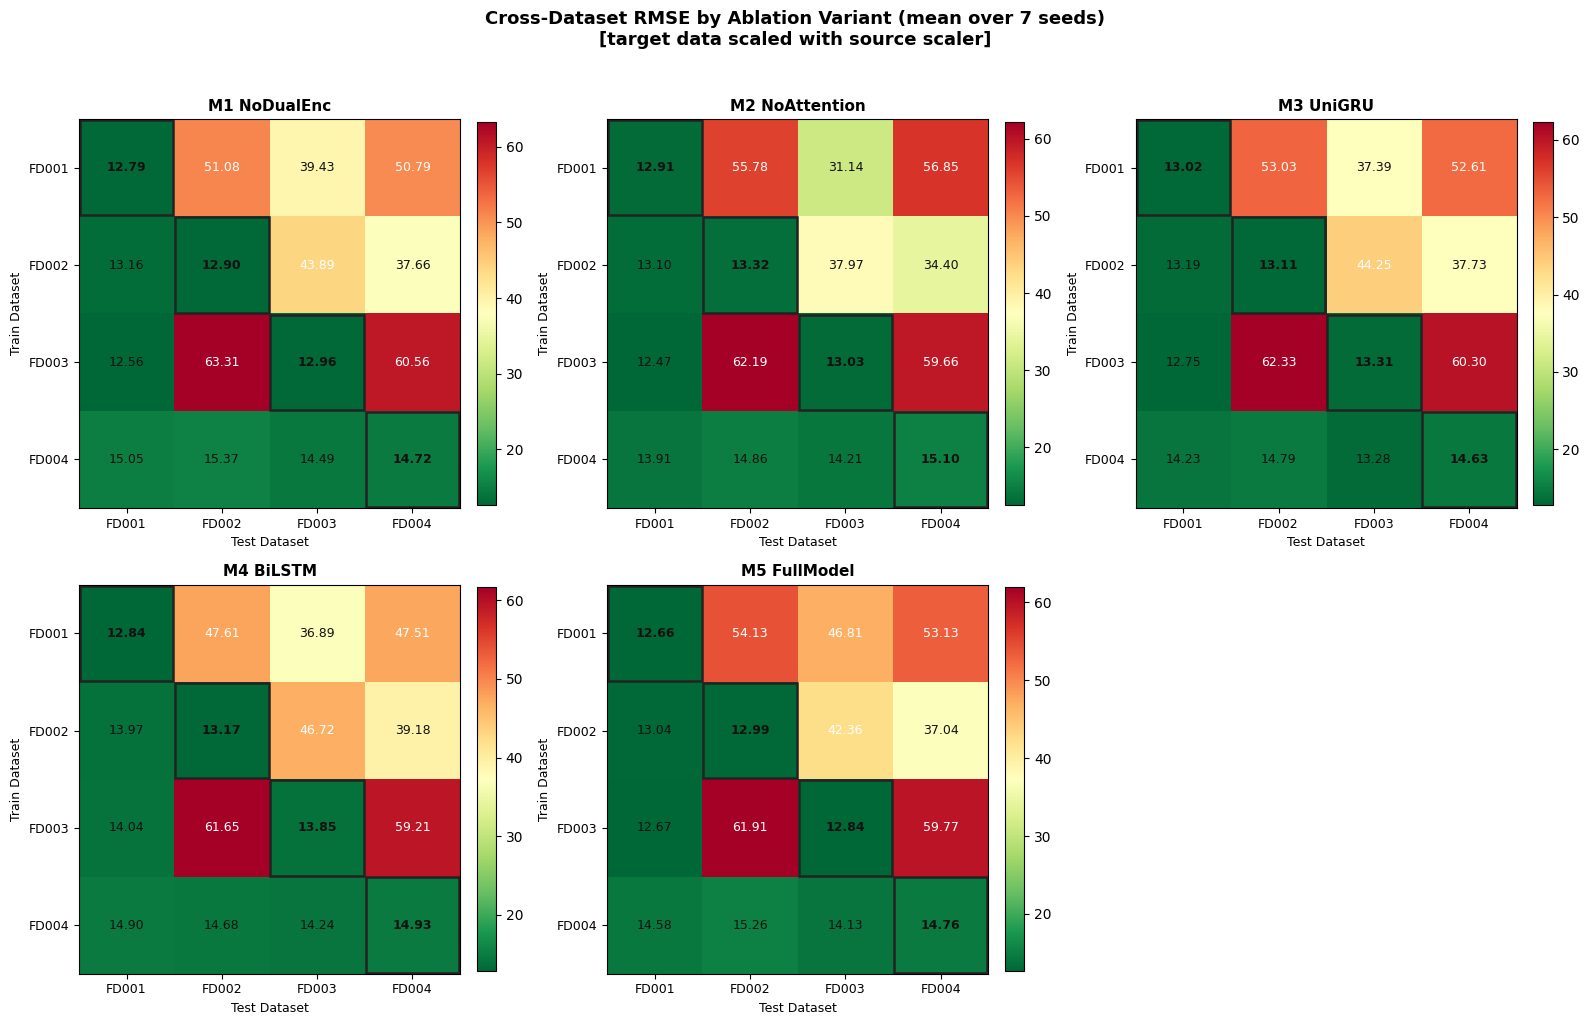


── Generalisation Gap (mean RMSE) by Variant ──
  = mean(off-diagonal RMSE) − in-distribution RMSE

  M1_NoDualEnc     | FD001:  in-dist=12.79  mean-OOD=47.10  gap=+34.32
  M1_NoDualEnc     | FD002:  in-dist=12.90  mean-OOD=31.57  gap=+18.67
  M1_NoDualEnc     | FD003:  in-dist=12.96  mean-OOD=45.48  gap=+32.52
  M1_NoDualEnc     | FD004:  in-dist=14.72  mean-OOD=14.97  gap=+0.25
  M2_NoAttention   | FD001:  in-dist=12.91  mean-OOD=47.92  gap=+35.01
  M2_NoAttention   | FD002:  in-dist=13.32  mean-OOD=28.49  gap=+15.17
  M2_NoAttention   | FD003:  in-dist=13.03  mean-OOD=44.77  gap=+31.75
  M2_NoAttention   | FD004:  in-dist=15.10  mean-OOD=14.33  gap=-0.78
  M3_UniGRU        | FD001:  in-dist=13.02  mean-OOD=47.68  gap=+34.65
  M3_UniGRU        | FD002:  in-dist=13.11  mean-OOD=31.72  gap=+18.61
  M3_UniGRU        | FD003:  in-dist=13.31  mean-OOD=45.13  gap=+31.81
  M3_UniGRU        | FD004:  in-dist=14.63  mean-OOD=14.10  gap=-0.53
  M4_BiLSTM        | FD001:  in-dist=12.84  mean-O

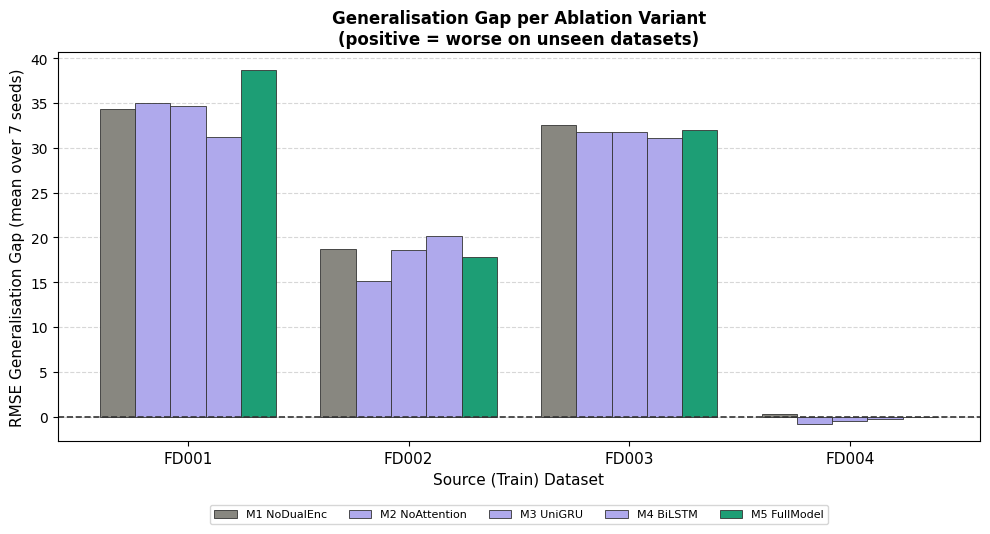

In [22]:
# ══════════════════════════════════════════════════════════════════════
# CROSS-DATASET GENERALISATION — ABLATION VARIANTS (M1-M4, M5 reused)
#   Same methodology as Section 13 (source-scaler correction, sequence-
#   length mismatch handling) but repeated for every ablation variant so
#   generalisation, not just in-distribution accuracy, can be compared
#   across architectures. No retraining happens here: M1-M4's 7-seed
#   models are reused directly from run_ablation_study()'s
#   ablation_trained_models (Section 15/cell 38), and M5's are reused
#   from Section 8's multi_seed_models -- both already trained per
#   source dataset with the same 7 seeds.
# ══════════════════════════════════════════════════════════════════════

ABLATION_CROSS_ORDER = ['M1_NoDualEnc', 'M2_NoAttention', 'M3_UniGRU', 'M4_BiLSTM', 'M5_FullModel']
CROSS_DATASETS        = ['FD001', 'FD002', 'FD003', 'FD004']
CROSS_METRIC_KEYS      = ['RMSE', 'MAE', 'R2', 'S-Score', 'Accuracy']

# ── 1. Raw (unscaled) test data + labels for every dataset (self-contained;
#       does not depend on Section 13, which may be disabled) ─────────────
ablation_raw_test_dfs      = {}
ablation_cross_test_labels = {}
for tgt in CROSS_DATASETS:
    _, test_df_raw, y_test_tmp = load_data(tgt)
    ablation_raw_test_dfs[tgt]      = test_df_raw
    ablation_cross_test_labels[tgt] = np.clip(y_test_tmp['RUL'].values, 0, 125)

print("Raw (unscaled) test sets loaded.\n")

# ── 2. Reuse already-trained 7-seed models for every variant, per source
#       dataset -- nothing is retrained here.
ablation_cross_models = {v: {} for v in ABLATION_CROSS_ORDER}

for vname in ABLATION_CROSS_ORDER:
    if vname == 'M5_FullModel':
        # Reused directly from Section 8
        for ds in CROSS_DATASETS:
            ablation_cross_models[vname][ds] = multi_seed_models['SA-CNN-GRU-DE'][ds]
    else:
        # Reused directly from run_ablation_study()'s ablation_trained_models
        # (Section 15 / cell 38) -- same variant, same 7 seeds, same datasets.
        for ds in CROSS_DATASETS:
            ablation_cross_models[vname][ds] = ablation_trained_models[vname][ds]
    n_check = {ds: len(ablation_cross_models[vname][ds]) for ds in CROSS_DATASETS}
    print(f"  \u25b8 {vname}: reusing {n_check} seed models per dataset (no retraining)")

print("\nAll variant models ready for cross-dataset evaluation (reused, not retrained).")

# ── 3. Evaluate every (variant, source, target) triple ────────────────
ablation_cross_seed_results = {}   # (variant, src, tgt) -> {metric: [7 values]}
ablation_cross_results      = {}   # (variant, src, tgt) -> {metric: {'mean','std'}}

for vname in ABLATION_CROSS_ORDER:
    for src in CROSS_DATASETS:
        src_config = DATASET_CONFIGS[src]
        src_seq    = src_config['seq_length']
        src_models = ablation_cross_models[vname][src]

        for tgt in CROSS_DATASETS:
            tgt_config = DATASET_CONFIGS[tgt]
            tgt_seq    = tgt_config['seq_length']
            y_true     = ablation_cross_test_labels[tgt]

            test_df_scaled = apply_source_scaler(
                ablation_raw_test_dfs[tgt], all_scalers[src], src_config
            )
            test_df_scaled = apply_smoothing(test_df_scaled, tgt_config['alpha'])
            X_tgt = prepare_test(test_df_scaled, tgt_seq)

            if tgt_seq != src_seq:
                if tgt_seq > src_seq:
                    X_eval = X_tgt[:, -src_seq:, :]
                else:
                    pad = np.zeros((X_tgt.shape[0], src_seq - tgt_seq, X_tgt.shape[2]), dtype=np.float32)
                    X_eval = np.concatenate([pad, X_tgt], axis=1)
            else:
                X_eval = X_tgt

            seed_metrics = {m: [] for m in CROSS_METRIC_KEYS}
            for seed_model in src_models:
                y_pred = np.clip(_infer(seed_model, X_eval), 0, 125)
                seed_metrics['RMSE'].append(float(np.sqrt(mean_squared_error(y_true, y_pred))))
                seed_metrics['MAE'].append(float(mean_absolute_error(y_true, y_pred)))
                seed_metrics['R2'].append(float(r2_score(y_true, y_pred)))
                seed_metrics['S-Score'].append(float(compute_s_score(y_true, y_pred)))
                seed_metrics['Accuracy'].append(float(compute_accuracy(y_true, y_pred)))

            ablation_cross_seed_results[(vname, src, tgt)] = seed_metrics
            ablation_cross_results[(vname, src, tgt)] = {
                m: {'mean': float(np.mean(v)), 'std': float(np.std(v, ddof=1))}
                for m, v in seed_metrics.items()
            }

    print(f"  \u2713 Cross-dataset evaluation complete for {vname}")

# ── 4. Summary tables (mean ± std over 7 seeds), one per variant ──────
os.makedirs('./ablation_results', exist_ok=True)
ablation_cross_records = []

for vname in ABLATION_CROSS_ORDER:
    print("\n" + "=" * 78)
    print(f"  CROSS-DATASET EVALUATION — {vname}  (rows = train source, cols = test target)")
    print(f"  mean ± std over {N_SEEDS} seeds; [target test data scaled with SOURCE model's scaler]")
    print("=" * 78)

    mat = pd.DataFrame(
        {tgt: {src: f"{ablation_cross_results[(vname, src, tgt)]['RMSE']['mean']:.2f}"
                     f"\u00b1{ablation_cross_results[(vname, src, tgt)]['RMSE']['std']:.2f}"
               for src in CROSS_DATASETS}
         for tgt in CROSS_DATASETS},
        index=CROSS_DATASETS
    ).rename_axis("Train \u2193  Test \u2192", axis='columns')
    print(f"\n\u2500\u2500 RMSE \u2500\u2500")
    print(mat.to_string())

    for src in CROSS_DATASETS:
        for tgt in CROSS_DATASETS:
            row = {'variant': vname, 'Train': src, 'Test': tgt}
            for m in CROSS_METRIC_KEYS:
                row[f'{m}_mean'] = ablation_cross_results[(vname, src, tgt)][m]['mean']
                row[f'{m}_std']  = ablation_cross_results[(vname, src, tgt)][m]['std']
            ablation_cross_records.append(row)

ablation_cross_df = pd.DataFrame(ablation_cross_records).set_index(['variant', 'Train', 'Test']).round(3)
ablation_cross_df.to_csv('./ablation_results/ablation_cross_dataset_results_multiseed.csv')
print("\nSaved to ./ablation_results/ablation_cross_dataset_results_multiseed.csv")

# ── 5. Heatmap grid — RMSE cross-dataset matrix per variant ───────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, vname in enumerate(ABLATION_CROSS_ORDER):
    ax = axes[idx]
    matrix = np.array([
        [ablation_cross_results[(vname, src, tgt)]['RMSE']['mean'] for tgt in CROSS_DATASETS]
        for src in CROSS_DATASETS
    ], dtype=float)

    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
    ax.set_xticks(range(4)); ax.set_xticklabels(CROSS_DATASETS, fontsize=9)
    ax.set_yticks(range(4)); ax.set_yticklabels(CROSS_DATASETS, fontsize=9)
    ax.set_xlabel('Test Dataset', fontsize=9)
    ax.set_ylabel('Train Dataset', fontsize=9)
    ax.set_title(vname.replace('_', ' '), fontsize=11, fontweight='bold')

    vmin, vmax = matrix.min(), matrix.max()
    for i in range(4):
        for j in range(4):
            val    = matrix[i, j]
            colour = 'white' if (val - vmin) / max(vmax - vmin, 1e-9) > 0.6 else '#111'
            weight = 'bold' if i == j else 'normal'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=9, color=colour, fontweight=weight)

    for d in range(4):
        ax.add_patch(mpatches.FancyBboxPatch(
            (d - 0.49, d - 0.49), 0.98, 0.98,
            boxstyle="square,pad=0", linewidth=1.8,
            edgecolor='#222', facecolor='none'
        ))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[-1].axis('off')
fig.suptitle('Cross-Dataset RMSE by Ablation Variant (mean over 7 seeds)\n[target data scaled with source scaler]',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./ablation_results/ablation_cross_dataset_rmse_grid.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 6. Generalisation gap comparison across variants ───────────────────
print("\n\u2500\u2500 Generalisation Gap (mean RMSE) by Variant \u2500\u2500")
print("  = mean(off-diagonal RMSE) \u2212 in-distribution RMSE\n")

gap_table = {vname: [] for vname in ABLATION_CROSS_ORDER}
for vname in ABLATION_CROSS_ORDER:
    for src in CROSS_DATASETS:
        in_dist  = ablation_cross_results[(vname, src, src)]['RMSE']['mean']
        off_diag = [ablation_cross_results[(vname, src, tgt)]['RMSE']['mean']
                    for tgt in CROSS_DATASETS if tgt != src]
        gap = float(np.mean(off_diag) - in_dist)
        gap_table[vname].append(gap)
        print(f"  {vname:16s} | {src}:  in-dist={in_dist:.2f}  "
              f"mean-OOD={np.mean(off_diag):.2f}  gap={gap:+.2f}")

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(CROSS_DATASETS))
width = 0.16
for i, vname in enumerate(ABLATION_CROSS_ORDER):
    offset = (i - (len(ABLATION_CROSS_ORDER) - 1) / 2) * width
    ax.bar(x + offset, gap_table[vname], width=width,
           label=vname.replace('_', ' '), color=VARIANT_COLORS[i], edgecolor='#333', linewidth=0.6)

ax.axhline(0, color='#333', linewidth=1.2, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(CROSS_DATASETS, fontsize=11)
ax.set_xlabel('Source (Train) Dataset', fontsize=11)
ax.set_ylabel('RMSE Generalisation Gap (mean over 7 seeds)', fontsize=11)
ax.set_title('Generalisation Gap per Ablation Variant\n(positive = worse on unseen datasets)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15))
plt.tight_layout()
plt.savefig('./ablation_results/ablation_cross_dataset_generalisation_gap.png', dpi=300, bbox_inches='tight')
plt.show()


## 16. Feature Attribution — Integrated Gradients + GradCAM (Seed-42 Model)
Uses the seed-42 reference model extracted in Section 11 — same single-model policy as Section 12's plots; no separate model is trained for interpretability.

Running Integrated Gradients + GradCAM …

(Increase N_SAMPLES to the full test set for final publication runs)

  [FD001]  FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
Scaling Complete
IG … 

/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 100 equal to the number of examples.
  warnings.warn(


GradCAM … done
  [FD002]  FD002 Loaded — Train: (53759, 26), Test: (33991, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5 -1.  -0.5 ...  1.5  1.5  1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
IG … 

...

GradCAM … done
  [FD004]  FD004 Loaded — Train: (61249, 26), Test: (41214, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.         -0.33333333 -0.66666667 ...  1.33333333  1.
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.66666667 -0.66666667 -0.66666667 ...  0.66666667  0.66666667
  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
IG … 

/usr/local/lib/python3.12/dist-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 200 equal to the number of examples.
  warnings.warn(


GradCAM … done

All attributions computed.



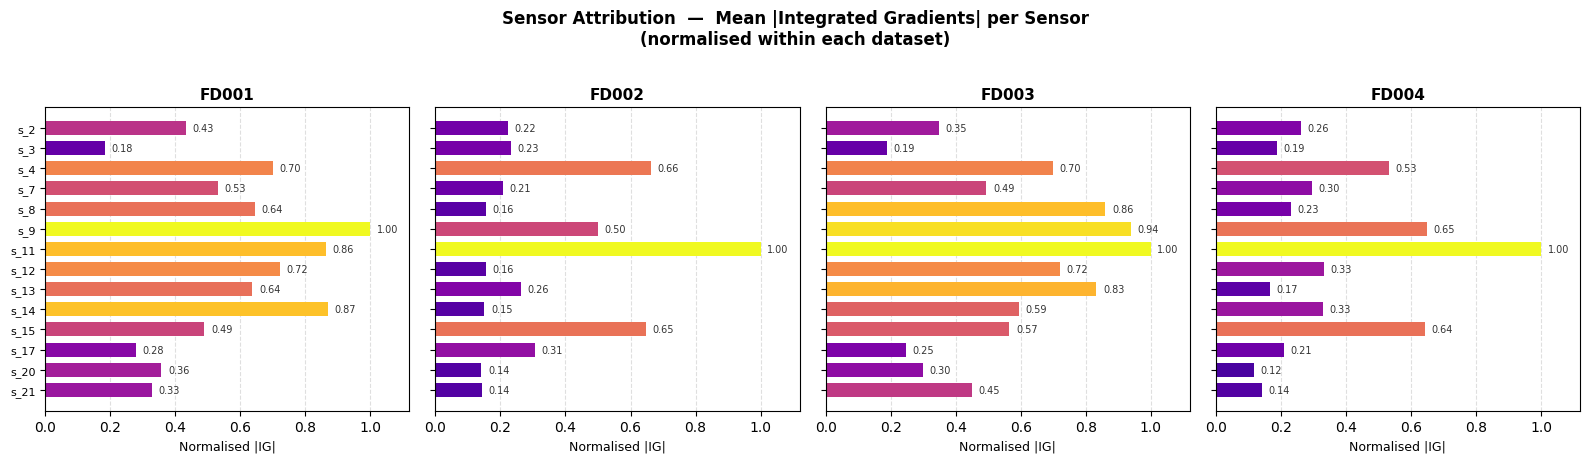

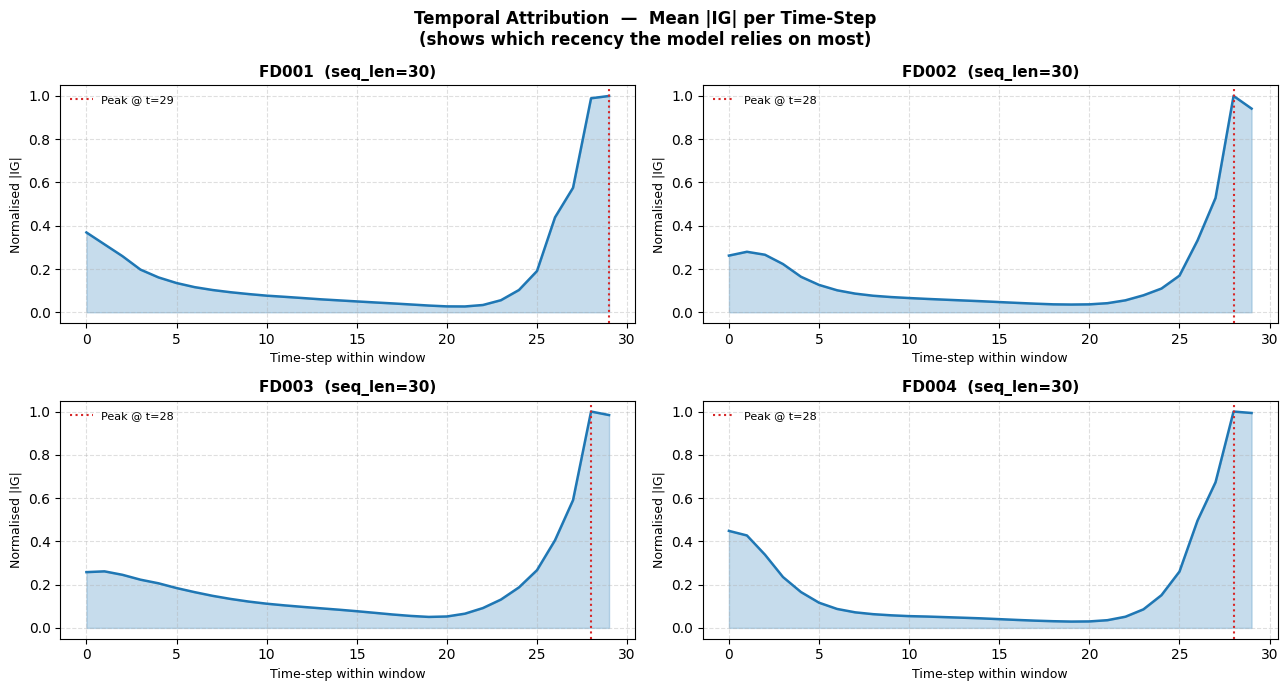

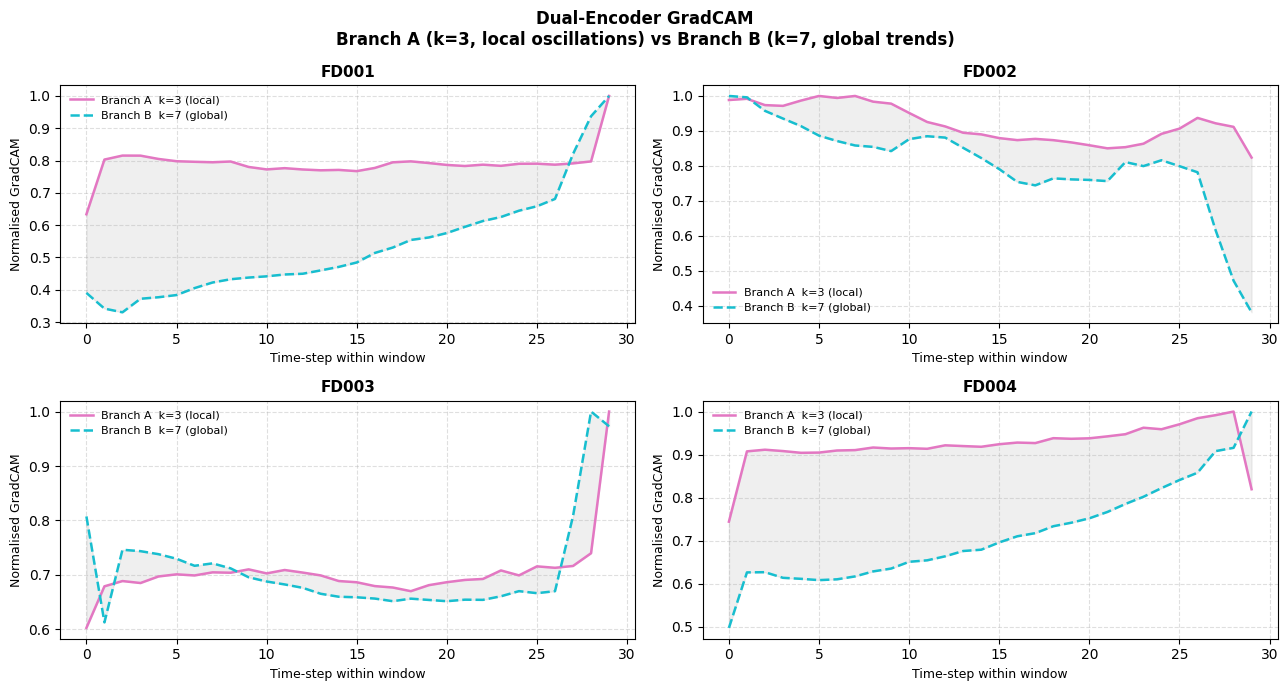

FD002 Loaded — Train: (53759, 26), Test: (33991, 26)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X d

FD002 Loaded — Train: (53759, 26), Test: (33991, 26)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X d

FD004 Loaded — Train: (61249, 26), Test: (41214, 26)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X d

FD004 Loaded — Train: (61249, 26), Test: (41214, 26)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X d

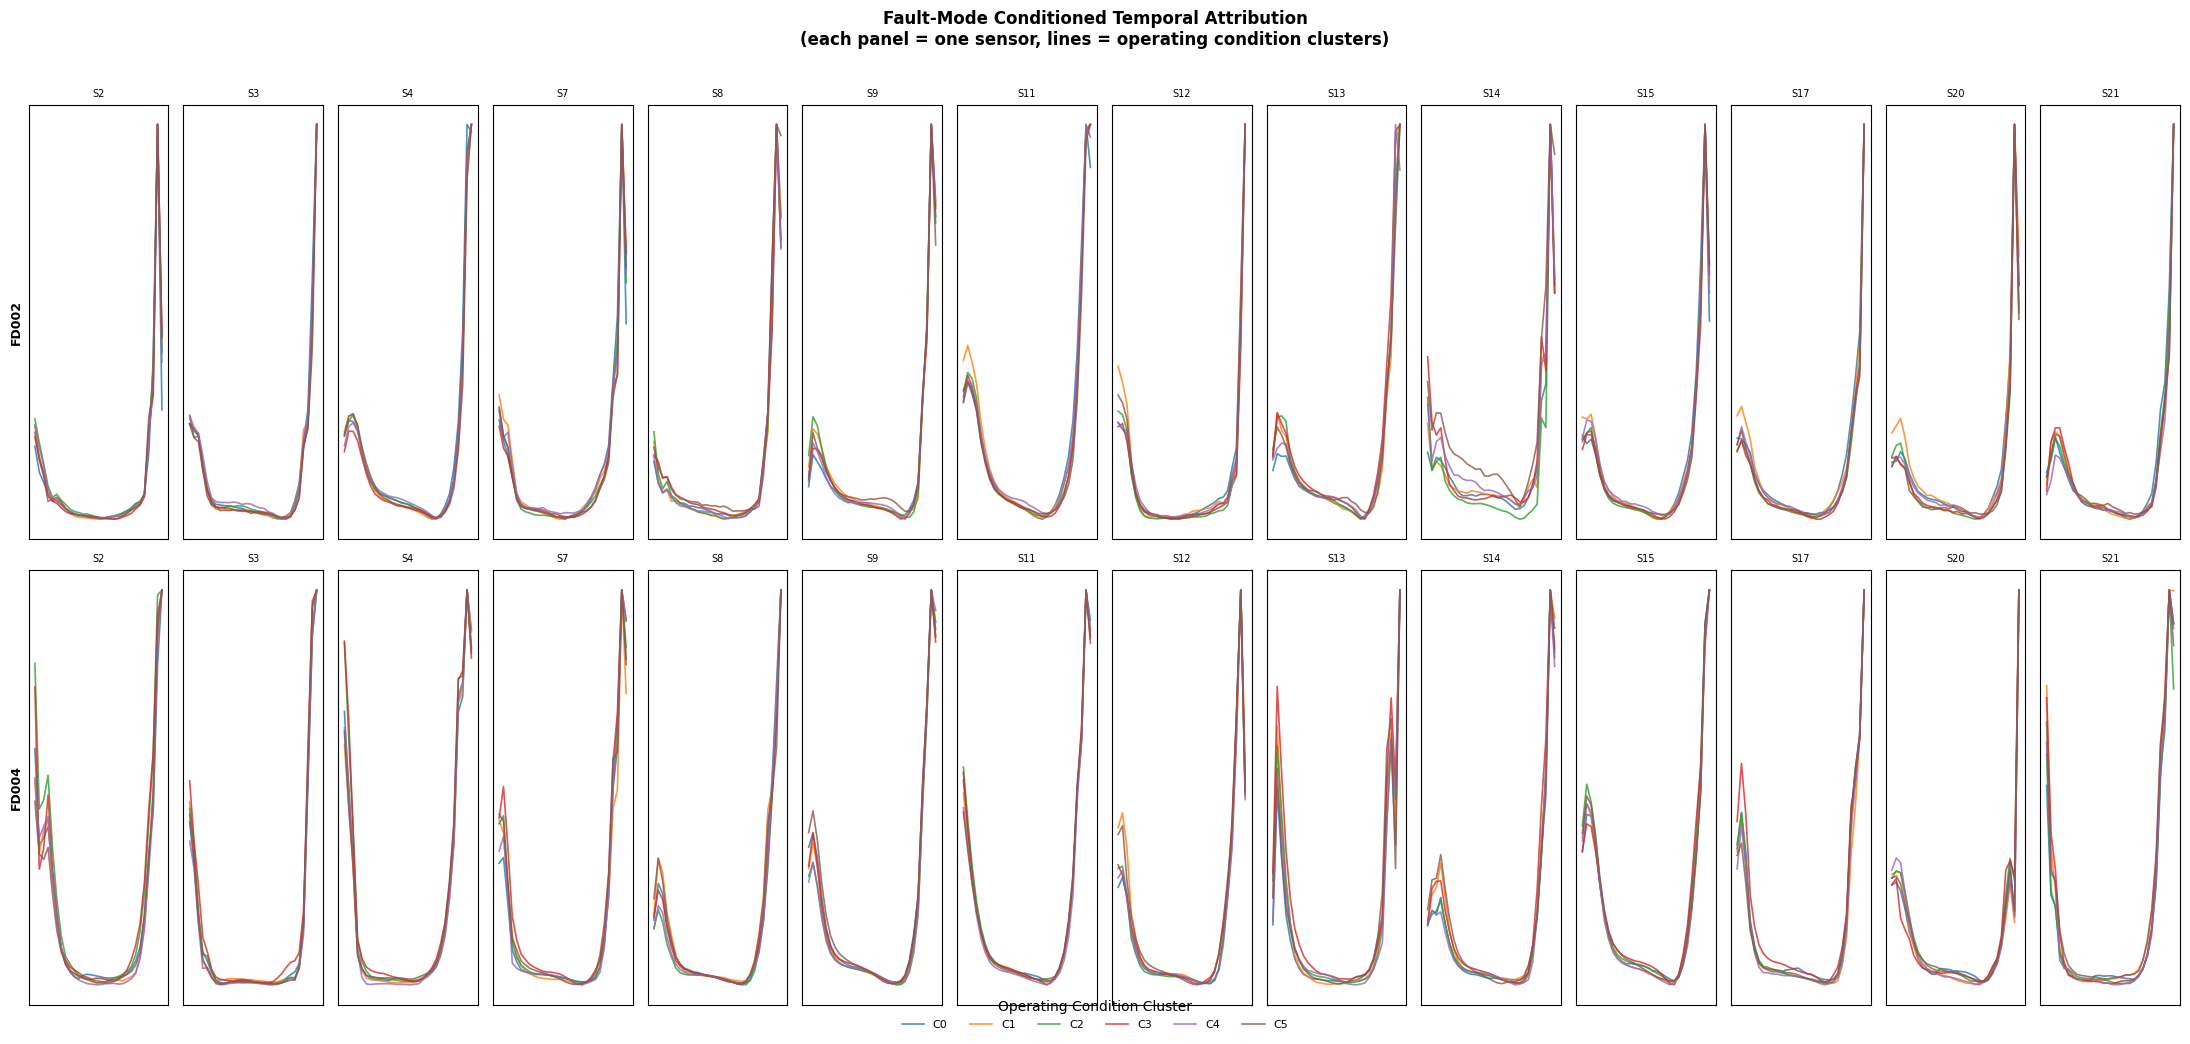

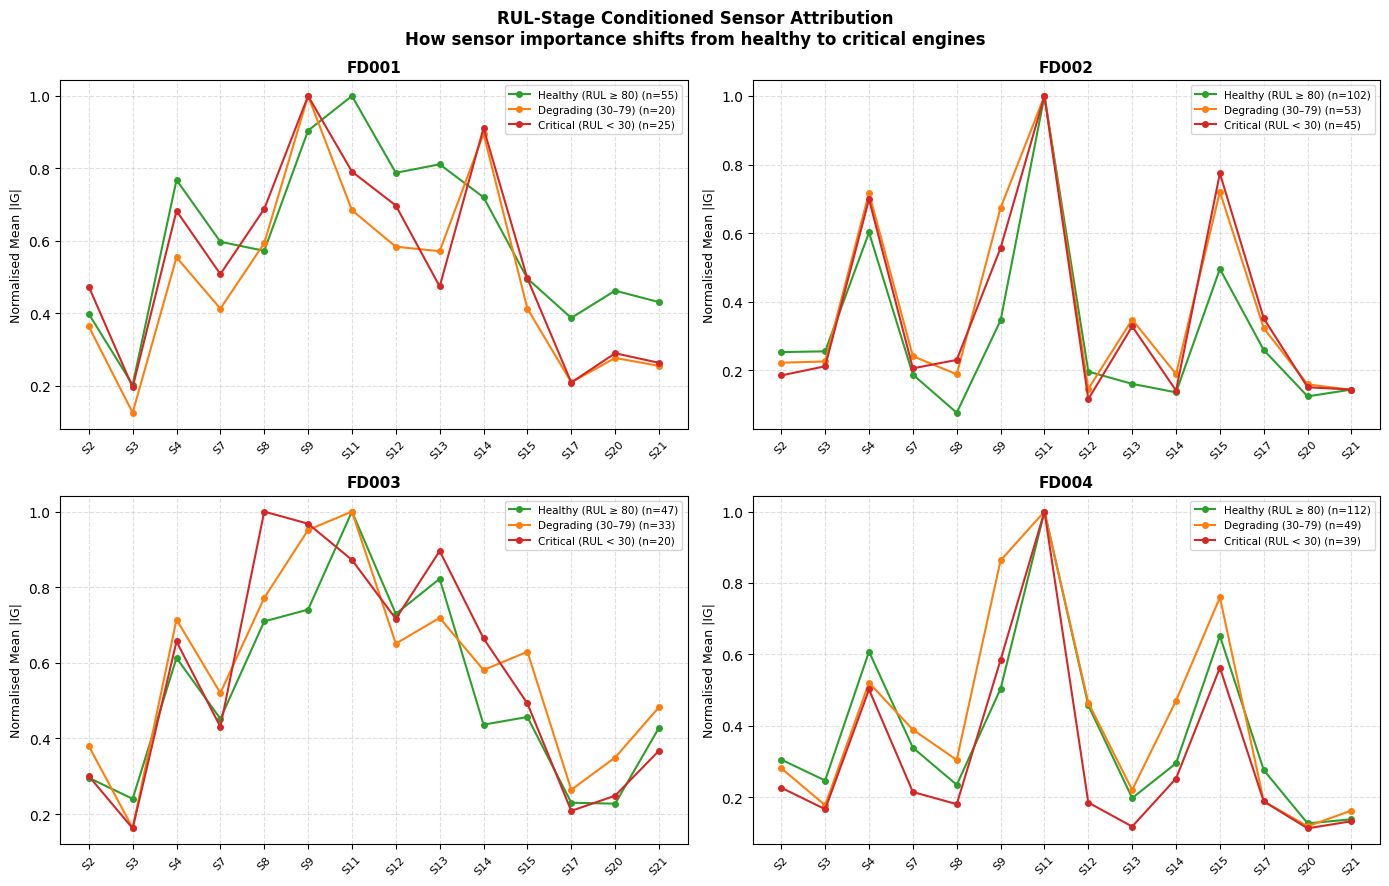

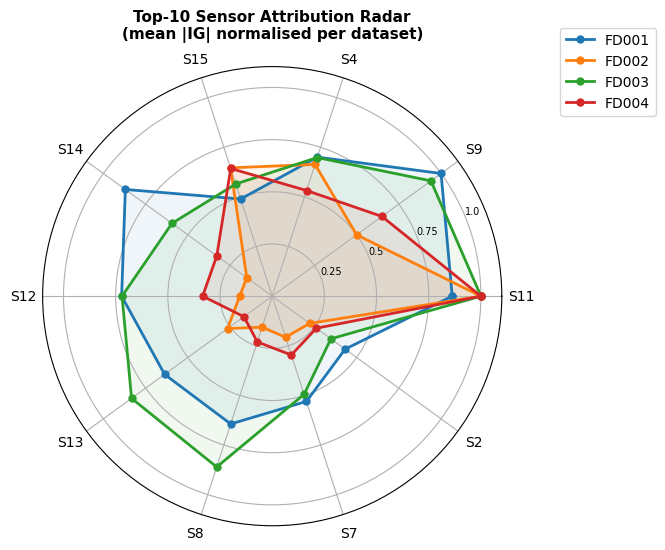

  TOP-5 MOST ATTRIBUTED SENSORS PER DATASET

  FD001
      s_9  ██████████████████████████████  1.000
     s_14  ██████████████████████████░░░░  0.870
     s_11  █████████████████████████░░░░░  0.863
     s_12  █████████████████████░░░░░░░░░  0.722
      s_4  █████████████████████░░░░░░░░░  0.700

  FD002
     s_11  ██████████████████████████████  1.000
      s_4  ███████████████████░░░░░░░░░░░  0.664
     s_15  ███████████████████░░░░░░░░░░░  0.647
      s_9  ███████████████░░░░░░░░░░░░░░░  0.500
     s_17  █████████░░░░░░░░░░░░░░░░░░░░░  0.306

  FD003
     s_11  ██████████████████████████████  1.000
      s_9  ████████████████████████████░░  0.940
      s_8  █████████████████████████░░░░░  0.861
     s_13  ████████████████████████░░░░░░  0.833
     s_12  █████████████████████░░░░░░░░░  0.720

  FD004
     s_11  ██████████████████████████████  1.000
      s_9  ███████████████████░░░░░░░░░░░  0.650
     s_15  ███████████████████░░░░░░░░░░░  0.643
      s_4  ███████████████░░░░░░░░░░░░

In [23]:
# ══════════════════════════════════════════════════════════════════════
# FEATURE ATTRIBUTION  —  Integrated Gradients + GradCAM (Captum)
# ──────────────────────────────────────────────────────────────────────

ATTR_SEED = 0
DATASETS  = ['FD001', 'FD002', 'FD003', 'FD004']

# Sensor display labels  (s_1..s_21, only the 14 used features matter)
SENSOR_LABELS = {f's_{i}': f'S{i}' for i in range(1, 22)}

# ── 1. Helper: build a baseline & run IG on a batch ──────────────────

def _ig_attributions(model, X_np, n_steps=50, internal_batch=32, baseline='zero'):
    """
    Compute Integrated Gradients for a batch of sequences.

    Parameters
    ----------
    model        : SaCnnGruDE (or any variant), already in eval mode
    X_np         : np.ndarray  shape (N, seq_len, n_feat)
    n_steps      : IG approximation steps (50 is standard; 100 for publication)
    internal_batch: how many (step × sample) rows to feed the model at once
    baseline     : 'zero' | 'mean'  — reference input

    Returns
    -------
    attrs : np.ndarray shape (N, seq_len, n_feat)  — signed attributions
    """
    model.eval()
    ig   = IntegratedGradients(model)

    X_t  = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    if baseline == 'zero':
        base = torch.zeros_like(X_t)
    else:   # mean across the batch
        base = X_t.mean(dim=0, keepdim=True).expand_as(X_t)

    # IG returns a tuple (one tensor per input); our model has one input
    attrs = ig.attribute(
        X_t,
        baselines=base,
        n_steps=n_steps,
        internal_batch_size=internal_batch,
        return_convergence_delta=False,
    )                                       # (N, seq_len, n_feat)
    return attrs.detach().cpu().numpy()


# ── 2. Helper: GradCAM on the dual-encoder conv branches ─────────────

def _gradcam_dual_encoder(model, X_np, batch_size=128):
    """
    Compute GradCAM activations for branch A (conv_a, k=3) and
    branch B (conv_b, k=7) of the DualEncoderBlock.

    Returns
    -------
    cam_a : np.ndarray  (N, seq_len)  — branch A activation map
    cam_b : np.ndarray  (N, seq_len)  — branch B activation map
    """
    model.eval()

    # Target layers inside dual_enc
    layer_a = model.dual_enc.conv_a   # Conv1d  (local / short-range)
    layer_b = model.dual_enc.conv_b   # Conv1d  (global / long-range)

    def _run(layer):
        gc   = LayerGradCam(model, layer)
        X_t  = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
        cams = []
        for i in range(0, len(X_t), batch_size):
            Xb = X_t[i:i+batch_size]
            # LayerGradCam returns (N, C, T) for Conv1d — relu_attributions
            attr = gc.attribute(Xb, relu_attributions=True)   # (N, C, T)
            # Pool channels → (N, T)
            cams.append(attr.mean(dim=1).detach().cpu().numpy())
        return np.concatenate(cams, axis=0)      # (N, T)

    return _run(layer_a), _run(layer_b)


# ── 3. Helper: cluster labels for multi-condition datasets ────────────

def _cluster_labels(dataset_name):
    """Return per-engine cluster labels for FD002 / FD004, else all zeros."""
    config = DATASET_CONFIGS[dataset_name]
    if not config['multi_condition']:
        return None
    train_df_tmp, test_df_tmp, _ = load_data(dataset_name)
    from sklearn.cluster import KMeans
    km = KMeans(n_clusters=config['n_clusters'], n_init=10, random_state=SEED)
    km.fit(train_df_tmp[setting_names])
    # One label per test engine (last row's settings)
    labels = []
    for unit in sorted(test_df_tmp['unit_number'].unique()):
        row = test_df_tmp[test_df_tmp['unit_number'] == unit].iloc[-1]
        labels.append(km.predict(row[setting_names].values.reshape(1, -1))[0])
    return np.array(labels)


# ── 4. Main attribution loop across all datasets ──────────────────────

attr_store  = {}   # dataset -> attrs  (N, seq, feat)
cam_store_a = {}   # dataset -> cam_a  (N, seq)
cam_store_b = {}   # dataset -> cam_b  (N, seq)
true_rul_store = {}

N_SAMPLES = 200    # cap per dataset to keep runtime manageable

print("Running Integrated Gradients + GradCAM …\n")
print("(Increase N_SAMPLES to the full test set for final publication runs)\n")

for ds in DATASETS:
    print(f"  [{ds}]", end='  ')
    config = DATASET_CONFIGS[ds]
    model  = all_models[ds]

    # Rebuild test set exactly as in Section 7
    train_df_tmp, test_df_tmp, y_test_tmp = load_data(ds)
    train_df_tmp = add_rul(train_df_tmp)
    train_df_tmp, test_df_tmp, _ = scale_data_strict(train_df_tmp, test_df_tmp, config)
    test_df_tmp = apply_smoothing(test_df_tmp, config['alpha'])
    X_test = prepare_test(test_df_tmp, config['seq_length'])   # (N, T, F)
    y_true = np.clip(y_test_tmp['RUL'].values, 0, 125)

    # Subsample for speed
    np.random.seed(ATTR_SEED)
    idx = np.random.choice(len(X_test), min(N_SAMPLES, len(X_test)), replace=False)
    X_sub = X_test[idx].astype(np.float32)
    y_sub = y_true[idx]

    print("IG …", end=' ')
    torch.backends.cudnn.enabled = False
    attrs = _ig_attributions(model, X_sub, n_steps=50)
    print("GradCAM …", end=' ')
    cam_a, cam_b = _gradcam_dual_encoder(model, X_sub)
    torch.backends.cudnn.enabled = True
    print("done")

    attr_store[ds]    = attrs
    cam_store_a[ds]   = cam_a
    cam_store_b[ds]   = cam_b
    true_rul_store[ds] = y_sub

print("\nAll attributions computed.\n")


# ══════════════════════════════════════════════════════════════════════
# ── PLOT A: Sensor importance heatmap  (mean |IG| per sensor) ─────────
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)

for ax, ds in zip(axes, DATASETS):
    # Mean absolute IG across samples and time-steps → (n_feat,)
    sensor_imp = np.abs(attr_store[ds]).mean(axis=(0, 1))
    sensor_imp /= sensor_imp.max()   # normalise to [0, 1]
    colours = plt.cm.plasma(sensor_imp)

    bars = ax.barh(features[::-1], sensor_imp[::-1], color=colours[::-1], height=0.7)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('Normalised |IG|', fontsize=9)
    ax.set_title(ds, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    # Label bars
    for bar, val in zip(bars, sensor_imp[::-1]):
        ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=7, color='#333')

fig.suptitle('Sensor Attribution  —  Mean |Integrated Gradients| per Sensor\n'
             '(normalised within each dataset)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('attr_sensor_importance.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════
# ── PLOT B: Temporal attribution map  (mean |IG| per time-step) ───────
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for ax, ds in zip(axes, DATASETS):
    # Mean |IG| per time-step, averaged over sensors and samples → (T,)
    temp_imp = np.abs(attr_store[ds]).mean(axis=(0, 2))   # (T,)
    temp_imp /= temp_imp.max()
    T = len(temp_imp)

    ax.fill_between(range(T), temp_imp, alpha=0.25, color='#1f77b4')
    ax.plot(range(T), temp_imp, color='#1f77b4', linewidth=1.8)
    ax.set_title(f'{ds}  (seq_len={T})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time-step within window', fontsize=9)
    ax.set_ylabel('Normalised |IG|', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    # Annotate the peak
    peak = np.argmax(temp_imp)
    ax.axvline(peak, color='#d62728', linestyle=':', linewidth=1.5,
               label=f'Peak @ t={peak}')
    ax.legend(fontsize=8, frameon=False)

fig.suptitle('Temporal Attribution  —  Mean |IG| per Time-Step\n'
             '(shows which recency the model relies on most)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('attr_temporal.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════
# ── PLOT C: GradCAM dual-encoder comparison  (branch A vs branch B) ───
# ══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for ax, ds in zip(axes, DATASETS):
    cam_a_mean = cam_store_a[ds].mean(axis=0)   # (T,)
    cam_b_mean = cam_store_b[ds].mean(axis=0)   # (T,)
    # Normalise each branch independently for visibility
    cam_a_norm = cam_a_mean / (cam_a_mean.max() + 1e-9)
    cam_b_norm = cam_b_mean / (cam_b_mean.max() + 1e-9)
    T = len(cam_a_norm)

    ax.plot(range(T), cam_a_norm, color='#e377c2', linewidth=1.8,
            label='Branch A  k=3 (local)')
    ax.plot(range(T), cam_b_norm, color='#17becf', linewidth=1.8,
            linestyle='--', label='Branch B  k=7 (global)')
    ax.fill_between(range(T), cam_a_norm, cam_b_norm, alpha=0.12, color='gray')
    ax.set_title(f'{ds}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time-step within window', fontsize=9)
    ax.set_ylabel('Normalised GradCAM', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Dual-Encoder GradCAM\n'
             'Branch A (k=3, local oscillations) vs Branch B (k=7, global trends)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('attr_gradcam_dual_encoder.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════
# ── PLOT D: Fault-mode conditioned (FD002 & FD004 only) ───────────────
# ══════════════════════════════════════════════════════════════════════

MULTI_DS = ['FD002', 'FD004']
fig, axes = plt.subplots(len(MULTI_DS), len(features), figsize=(22, 5 * len(MULTI_DS)))

for row_idx, ds in enumerate(MULTI_DS):
    labels = _cluster_labels(ds)
    # Subsample the same way we subsampled attrs
    np.random.seed(ATTR_SEED)
    n_total = len(_cluster_labels(ds))   # full test set
    idx = np.random.choice(n_total, min(N_SAMPLES, n_total), replace=False)
    sub_labels = labels[idx]
    n_clusters = DATASET_CONFIGS[ds]['n_clusters']
    attrs_ds   = attr_store[ds]          # (N_sub, T, F)

    for feat_idx, feat_name in enumerate(features):
        ax = axes[row_idx, feat_idx] if len(MULTI_DS) > 1 else axes[feat_idx]
        for c in range(n_clusters):
            mask = (sub_labels == c)
            if mask.sum() == 0:
                continue
            # Mean |IG| over time per cluster for this sensor
            cluster_temp = np.abs(attrs_ds[mask, :, feat_idx]).mean(axis=0)
            cluster_temp /= cluster_temp.max() + 1e-9
            ax.plot(cluster_temp, linewidth=1.2, alpha=0.8, label=f'C{c}')
        ax.set_title(SENSOR_LABELS.get(feat_name, feat_name), fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        ax.grid(True, linestyle=':', alpha=0.3)
        if feat_idx == 0:
            ax.set_ylabel(ds, fontsize=9, fontweight='bold')

# Shared legend
handles, lbls = axes[0, 0].get_legend_handles_labels() if len(MULTI_DS) > 1 \
                else axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc='lower center', ncol=6,
           title='Operating Condition Cluster', fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Fault-Mode Conditioned Temporal Attribution\n'
             '(each panel = one sensor, lines = operating condition clusters)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('attr_fault_mode_conditioned.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════
# ── PLOT E: RUL-stage conditioned attribution ─────────────────────────
# ══════════════════════════════════════════════════════════════════════

RUL_STAGES = {
    'Healthy (RUL ≥ 80)':    lambda r: r >= 80,
    'Degrading (30–79)':     lambda r: (r >= 30) & (r < 80),
    'Critical (RUL < 30)':   lambda r: r < 30,
}
STAGE_COLORS = {'Healthy (RUL ≥ 80)': '#2ca02c',
                'Degrading (30–79)':  '#ff7f0e',
                'Critical (RUL < 30)':'#d62728'}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, ds in zip(axes, DATASETS):
    attrs_ds = attr_store[ds]           # (N, T, F)
    y_sub    = true_rul_store[ds]

    for stage_name, stage_fn in RUL_STAGES.items():
        mask = stage_fn(y_sub)
        if mask.sum() < 3:
            continue
        # Mean |IG| per sensor for this stage → (F,)
        sensor_imp = np.abs(attrs_ds[mask]).mean(axis=(0, 1))
        sensor_imp /= sensor_imp.max() + 1e-9
        ax.plot(range(len(features)), sensor_imp, marker='o', markersize=4,
                linewidth=1.5, label=f'{stage_name} (n={mask.sum()})',
                color=STAGE_COLORS[stage_name])

    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([SENSOR_LABELS.get(f, f) for f in features],
                       rotation=45, fontsize=8)
    ax.set_ylabel('Normalised Mean |IG|', fontsize=9)
    ax.set_title(ds, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7.5, frameon=True, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

fig.suptitle('RUL-Stage Conditioned Sensor Attribution\n'
             'How sensor importance shifts from healthy to critical engines',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('attr_rul_stage.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════
# ── PLOT F: Radar / spider chart — top-10 sensor ranking across datasets
# ══════════════════════════════════════════════════════════════════════

# Global mean |IG| per sensor averaged over all 4 datasets
global_imp = np.stack(
    [np.abs(attr_store[ds]).mean(axis=(0, 1)) for ds in DATASETS], axis=0
)   # (4, F)
global_imp_norm = global_imp / global_imp.max(axis=1, keepdims=True)

# Pick top-10 sensors by mean across datasets
mean_global = global_imp_norm.mean(axis=0)
top10_idx   = np.argsort(mean_global)[::-1][:10]
top10_labels = [SENSOR_LABELS.get(features[i], features[i]) for i in top10_idx]

angles = np.linspace(0, 2 * np.pi, len(top10_idx), endpoint=False).tolist()
angles += angles[:1]   # close the loop

ds_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for ds, color in zip(DATASETS, ds_colors):
    values = global_imp_norm[DATASETS.index(ds), top10_idx].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, markersize=5, label=ds)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top10_labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=7)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.set_title('Top-10 Sensor Attribution Radar\n'
             '(mean |IG| normalised per dataset)',
             fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('attr_sensor_radar.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════════════
# ── SUMMARY TABLE: Top-5 sensors per dataset ──────────────────────────
# ══════════════════════════════════════════════════════════════════════

print("=" * 55)
print("  TOP-5 MOST ATTRIBUTED SENSORS PER DATASET")
print("=" * 55)
for ds in DATASETS:
    imp = np.abs(attr_store[ds]).mean(axis=(0, 1))
    top5 = np.argsort(imp)[::-1][:5]
    names = [features[i] for i in top5]
    vals  = [imp[i] / imp.max() for i in top5]
    print(f"\n  {ds}")
    for n, v in zip(names, vals):
        bar = '█' * int(v * 30) + '░' * (30 - int(v * 30))
        print(f"    {n:>5}  {bar}  {v:.3f}")

print()
print("Saved figures:")
for fname in [
    'attr_sensor_importance.png',
    'attr_temporal.png',
    'attr_gradcam_dual_encoder.png',
    'attr_fault_mode_conditioned.png',
    'attr_rul_stage.png',
    'attr_sensor_radar.png',
]:
    print(f"  {fname}")

*The section below (Uncertainty Quantification Comparison) is retained exactly as originally
written, per request — including its internal references to "Section 7" and "Section 12", which are
the **original** section numbers. In the reorganised numbering used in this notebook they correspond
to Section 11 (seed-42 reference model / MC-Dropout) and Section 8 (multi-seed training), respectively
— see the mapping table above.*

## 13. Uncertainty Quantification Comparison — MC Dropout vs. Deep Ensembles vs. Heteroscedastic NN

**Reviewer comment:** *"The Monte Carlo Dropout results show only weak-to-moderate correlations between uncertainty estimates and prediction errors, indicating that uncertainty calibration remains limited. The authors should consider comparing MC Dropout with alternative approaches such as deep ensembles or heteroscedastic neural networks."*

We compare three uncertainty-quantification strategies on every dataset, using the same trained backbone wherever possible:

- **MC Dropout** — the existing method (Section 7), 50 stochastic forward passes with dropout left active at inference.
- **Deep Ensemble** — the 5 independently-seeded SA-CNN-GRU-DE models already trained in Section 12 (no extra training cost); ensemble mean/std replace the MC-Dropout mean/std.
- **Heteroscedastic Neural Network** — a two-headed variant of the same backbone that predicts a mean and a log-variance directly, trained end-to-end with a Gaussian negative-log-likelihood loss, giving aleatoric uncertainty without any sampling at inference time.

For each method we report the RMSE of the point prediction, the Pearson/Spearman correlation between predicted uncertainty (σ) and absolute error (calibration proxy used in the original submission), the Gaussian negative log-likelihood (NLL, lower = better), the 95% prediction-interval coverage probability (PICP, closer to 0.95 = better calibrated), and sharpness (mean interval width, lower = more informative for a given coverage).


In [24]:
# ══════════════════════════════════════════════════════════════════════
# 13a. HETEROSCEDASTIC NEURAL NETWORK — same backbone, two-headed output
#      (predicted mean RUL + predicted log-variance), trained with a
#      Gaussian negative-log-likelihood loss.
# ══════════════════════════════════════════════════════════════════════
class SaCnnGruDEHeteroscedastic(nn.Module):
    """SA-CNN-GRU-DE backbone with a two-headed output: predicted mean RUL
    and predicted log-variance (aleatoric uncertainty). Architecture is
    otherwise identical to SaCnnGruDE."""
    def __init__(self, seq_length: int, n_features: int,
                 cnn_channels: int = 32, attn_heads: int = 4,
                 gru_hidden: int = 32, fc_hidden: int = 32,
                 spatial_drop: float = 0.3, attn_drop: float = 0.2,
                 gru_drop: float = 0.3, fc_drop: float = 0.5):
        super().__init__()
        d_model = cnn_channels * 2
        self.dual_enc = DualEncoderBlock(n_features, cnn_channels, spatial_drop)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=attn_heads,
            dropout=attn_drop, batch_first=True,
        )
        self.norm = nn.LayerNorm(d_model)
        self.gru = nn.GRU(
            input_size=d_model, hidden_size=gru_hidden, num_layers=2,
            batch_first=True, dropout=0, bidirectional=True,
        )
        self.gru_drop = nn.Dropout(p=gru_drop)
        gru_out_dim = gru_hidden * 2
        self.fc1 = nn.Linear(gru_out_dim, fc_hidden)
        self.bn  = nn.BatchNorm1d(fc_hidden)
        self.drop = nn.Dropout(p=fc_drop)
        self.fc_mean   = nn.Linear(fc_hidden, 1)
        self.fc_logvar = nn.Linear(fc_hidden, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.dual_enc(x)
        attn_out, _ = self.attn(x, x, x)
        x = self.norm(x + attn_out)
        x, _ = self.gru(x)
        x = self.gru_drop(x)
        x = x[:, -1, :]
        x = self.relu(self.bn(self.fc1(x)))
        x = self.drop(x)
        mean   = self.fc_mean(x)
        logvar = self.fc_logvar(x)
        logvar = torch.clamp(logvar, min=-6.0, max=6.0)   # numerical stability
        return mean, logvar


def train_heteroscedastic(
    model, optimizer, X_train, y_train,
    epochs=100, batch_size=32, val_split=0.2,
    patience=20, lr_patience=10, lr_factor=0.5, min_lr=1e-7,
):
    """Same train-loop structure as train_model(), but optimises the
    Gaussian NLL loss jointly over the (mean, log-variance) heads."""
    gauss_nll = nn.GaussianNLLLoss(full=True, reduction='mean')
    X_t = torch.tensor(X_train)
    y_t = torch.tensor(y_train).unsqueeze(1)
    dataset = TensorDataset(X_t, y_t)
    n_val   = int(len(dataset) * val_split)
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(SEED)
    )
    # drop_last=True on the TRAINING loader only -- see Section 5's
    # train_model() for why (BatchNorm1d cannot train on a final batch
    # of size 1).
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=lr_patience, min_lr=min_lr
    )
    best_val, best_wts, patience_ctr = float('inf'), None, 0

    for epoch in range(epochs):
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            mean, logvar = model(Xb)
            loss = gauss_nll(mean, yb, torch.exp(logvar))
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                mean, logvar = model(Xb)
                val_loss += gauss_nll(mean, yb, torch.exp(logvar)).item() * len(Xb)
        val_loss /= n_val
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_wts is not None:
        model.load_state_dict(best_wts)
    return model


@torch.no_grad()
def predict_heteroscedastic(model, X_np, batch_size=256):
    """Return (mean, std) predicted directly by the heteroscedastic head."""
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32)
    means, stds = [], []
    for i in range(0, len(X_t), batch_size):
        Xb = X_t[i:i + batch_size].to(DEVICE)
        mean, logvar = model(Xb)
        means.append(mean.cpu().numpy())
        stds.append(torch.sqrt(torch.exp(logvar)).cpu().numpy())
    return np.concatenate(means).flatten(), np.concatenate(stds).flatten()


def predict_deep_ensemble(models, X_np, batch_size=256):
    """Ensemble mean/std across a list of independently-trained models."""
    preds = np.stack(
        [np.clip(predict(m, X_np, batch_size), 0, 125) for m in models], axis=0
    )
    return preds.mean(axis=0), preds.std(axis=0), preds


def gaussian_nll_numpy(y_true, mean, std, eps=1e-6):
    std = np.clip(std, eps, None)
    return float(np.mean(0.5 * np.log(2 * np.pi * std ** 2) + 0.5 * ((y_true - mean) / std) ** 2))


def picp_and_sharpness(y_true, mean, std, z=1.96):
    """95% Prediction Interval Coverage Probability and interval sharpness."""
    lower, upper = mean - z * std, mean + z * std
    picp = float(np.mean((y_true >= lower) & (y_true <= upper)))
    sharpness = float(np.mean(upper - lower))
    return picp, sharpness

print("Heteroscedastic NN, Deep-Ensemble and calibration-metric helpers defined.")


Heteroscedastic NN, Deep-Ensemble and calibration-metric helpers defined.


In [25]:
# ══════════════════════════════════════════════════════════════════════
# 13b. RUN ALL THREE UQ METHODS ON EVERY DATASET
# ══════════════════════════════════════════════════════════════════════
uq_comparison_rows = []
hetero_models = {}

for dataset_name, config in DATASET_CONFIGS.items():
    print(f"\n--- Uncertainty comparison: {dataset_name} ---")

    # Rebuild data (identical preprocessing pipeline as Section 7)
    train_df, test_df, y_test_df = load_data(dataset_name)
    train_df = add_rul(train_df)
    train_df, test_df, _fitted_scalers = scale_data_strict(train_df, test_df, config)
    train_df = apply_smoothing(train_df, config['alpha'])
    test_df  = apply_smoothing(test_df,  config['alpha'])
    seq_length = config['seq_length']
    X_train, y_train = create_sequences(train_df, seq_length)
    X_test_final   = prepare_test(test_df, seq_length)
    y_true_clipped = np.clip(y_test_df['RUL'].values, 0, 125)

    # (i) MC Dropout — already computed for the SEED-42 model in Section 7
    mc_mean = all_predictions[dataset_name]['mc_mean']
    mc_std  = all_predictions[dataset_name]['mc_std']

    # (ii) Deep Ensemble — the 5 independently-seeded models from Section 12
    ens_models = multi_seed_models['SA-CNN-GRU-DE'][dataset_name]
    ens_mean, ens_std, _ = predict_deep_ensemble(ens_models, X_test_final)

    # (iii) Heteroscedastic NN — trained once per dataset with Gaussian NLL loss
    reset_seeds(SEED)
    hetero_model = SaCnnGruDEHeteroscedastic(seq_length, len(features)).to(DEVICE)
    hetero_opt   = optim.Adam(hetero_model.parameters(), lr=0.0005)
    hetero_model = train_heteroscedastic(
        hetero_model, hetero_opt, X_train, y_train,
        epochs=100, batch_size=config['batch_size'],
        val_split=0.2, patience=20, lr_patience=10,
    )
    het_mean, het_std = predict_heteroscedastic(hetero_model, X_test_final)
    het_mean = np.clip(het_mean, 0, 125)
    hetero_models[dataset_name] = hetero_model

    methods = {
        'MC Dropout':      (mc_mean,  mc_std),
        'Deep Ensemble':   (ens_mean, ens_std),
        'Heteroscedastic': (het_mean, het_std),
    }

    for method_name, (mean_pred, std_pred) in methods.items():
        abs_err       = np.abs(y_true_clipped - mean_pred)
        pearson_r, _  = stats.pearsonr(std_pred, abs_err)
        spearman_r, _ = stats.spearmanr(std_pred, abs_err)
        nll           = gaussian_nll_numpy(y_true_clipped, mean_pred, std_pred)
        picp, sharp   = picp_and_sharpness(y_true_clipped, mean_pred, std_pred)
        rmse          = np.sqrt(mean_squared_error(y_true_clipped, mean_pred))

        uq_comparison_rows.append({
            'Dataset': dataset_name, 'Method': method_name, 'RMSE': rmse,
            'Pearson_r(unc,err)': pearson_r, 'Spearman_rho(unc,err)': spearman_r,
            'NLL': nll, 'PICP_95%': picp, 'Sharpness': sharp,
        })
        print(f"  {method_name:16s} RMSE={rmse:.2f}  r={pearson_r:.3f}  rho={spearman_r:.3f}  "
              f"NLL={nll:.3f}  PICP={picp:.3f}  Sharpness={sharp:.2f}")

uq_comparison_df = pd.DataFrame(uq_comparison_rows)
print("\nUNCERTAINTY QUANTIFICATION METHOD COMPARISON")
print(uq_comparison_df.round(3).to_string(index=False))
uq_comparison_df.to_csv('uncertainty_method_comparison.csv', index=False)
print("\nSaved -> uncertainty_method_comparison.csv")



--- Uncertainty comparison: FD001 ---
FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
Scaling Complete
  MC Dropout       RMSE=12.40  r=0.357  rho=0.422  NLL=3.877  PICP=0.970  Sharpness=59.58
  Deep Ensemble    RMSE=12.17  r=0.189  rho=0.222  NLL=13.730  PICP=0.510  Sharpness=12.61
  Heteroscedastic  RMSE=12.99  r=0.300  rho=0.403  NLL=4.045  PICP=0.980  Sharpness=74.81

--- Uncertainty comparison: FD002 ---
FD002 Loaded — Train: (53759, 26), Test: (33991, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5 -1.  -0.5 ...  1.5  1.5  1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
  MC Dropout       RMSE=12.90  r=0.269  rho=0.213  NLL=3.912  PICP=0.977  Sharpness=60.16
  Deep Ensemble    RMSE=12.56  r=0.172  rho=0.110  NLL=378378380306.484  PICP=0.459  Sharpness=11.36
  Heteroscedastic  RMSE=13.39  r=0.188  rho=0.216  NLL=4.106  PICP=0.992  Sharpness=76.53

--- Uncertainty comparison: FD003 ---
FD003 Loaded — Train: (24720, 26), Test: (16596, 26)
Scaling Complete
  MC Dropout       RMSE=13.31  r=0.265  rho=0.278  NLL=3.895  PICP=0.980  Sharpness=57.61
  Deep Ensemble    RMSE=12.13  r=0.173  rho=0.128  NLL=15.994  PICP=0.530  Sharpness=14.20
  Heteroscedastic  RMSE=13.47  r=0.178  rho=0.280  NLL=4.106  PICP=0.980  Sharpness=76.60

--- Uncertainty comparison: FD004 ---
FD004 Loaded — Train: (61249, 26), Test: (41214, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.         -0.33333333 -0.66666667 ...  1.33333333  1.
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.66666667 -0.66666667 -0.66666667 ...  0.66666667  0.66666667
  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
  MC Dropout       RMSE=15.23  r=0.147  rho=0.226  NLL=4.197  PICP=0.931  Sharpness=58.26
  Deep Ensemble    RMSE=14.17  r=0.384  rho=0.328  NLL=15.511  PICP=0.375  Sharpness=13.83
  Heteroscedastic  RMSE=15.32  r=0.060  rho=0.087  NLL=4.209  PICP=0.972  Sharpness=78.66

UNCERTAINTY QUANTIFICATION METHOD COMPARISON
Dataset          Method   RMSE  Pearson_r(unc,err)  Spearman_rho(unc,err)          NLL  PICP_95%  Sharpness
  FD001      MC Dropout 12.401               0.357                  0.422 3.877000e+00     0.970     59.583
  FD001   Deep Ensemble 12.166               0.189                  0.222 1.373000e+01     0.510     12.615
  FD001 Heteroscedastic 12.994               0.300                  0.403 4.045000e+00     0.980     74.806
  FD002      MC Dropout 12.897               0.269                  0.213 3.912000e+00     0.977     60.155
  FD002   Deep Ensemble 12.559               0.172                  0.110 3.783784e+11     0.459     11.358
  FD002 Heterosced

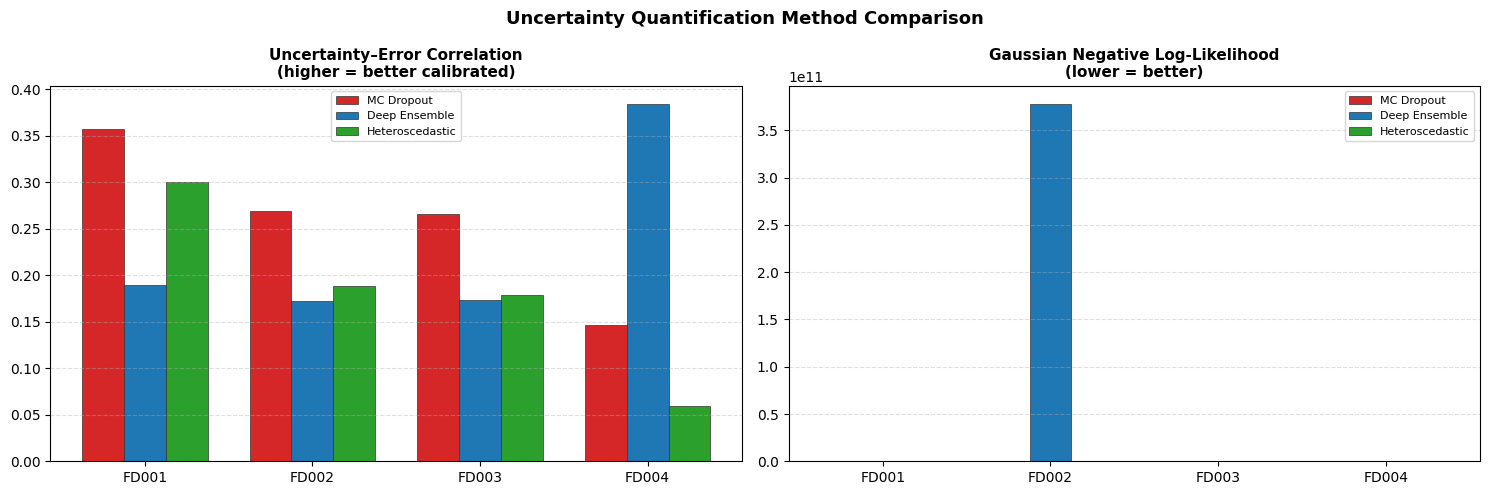

Saved -> uq_method_comparison.png


In [26]:
# ══════════════════════════════════════════════════════════════════════
# 13c. PLOT — UQ method comparison across datasets
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
methods_order = ['MC Dropout', 'Deep Ensemble', 'Heteroscedastic']
ds_order      = list(DATASET_CONFIGS.keys())
colours_uq = {'MC Dropout': '#d62728', 'Deep Ensemble': '#1f77b4', 'Heteroscedastic': '#2ca02c'}

for ax, metric, title in zip(
    axes,
    ['Pearson_r(unc,err)', 'NLL'],
    ['Uncertainty–Error Correlation\n(higher = better calibrated)',
     'Gaussian Negative Log-Likelihood\n(lower = better)']
):
    x = np.arange(len(ds_order))
    width = 0.25
    for i, method in enumerate(methods_order):
        vals = [uq_comparison_df[(uq_comparison_df.Dataset == ds) &
                                  (uq_comparison_df.Method == method)][metric].values[0]
                for ds in ds_order]
        ax.bar(x + i * width, vals, width=width, label=method,
               color=colours_uq[method], edgecolor='#333', linewidth=0.5)
    ax.set_xticks(x + width)
    ax.set_xticklabels(ds_order)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Uncertainty Quantification Method Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('uq_method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved -> uq_method_comparison.png")


## 18. Quantitative Explainability Evaluation

**Reviewer comment:** *"Quantitative evaluation of explainability methods, beyond visual attribution analysis, would provide stronger evidence that the identified sensors and temporal patterns are truly meaningful for prognostics decision-making."*

We add two quantitative, numeric tests that complement the visual Integrated-Gradients / GradCAM plots from Section 8:

1. **Deletion (perturbation) faithfulness test.** Sensors are masked (set to zero) in order of their IG-ranked importance, and we track how quickly test RMSE degrades. We report the **AUC of the RMSE-vs-fraction-masked curve** for (a) the IG-ranked order, (b) the reverse (least-important-first) order, and (c) the average over `N_RANDOM_CONTROLS` random orders. If IG attributions are faithful, masking the most-important sensors first should degrade performance markedly faster than a random or reversed ordering — i.e. `Deletion_AUC_IG_order` should sit clearly below `Deletion_AUC_least_important_order` and the `Faithfulness_gap` (IG AUC − random AUC) should be large and negative.
2. **Domain-relevance rank correlation.** We compute each sensor's raw Pearson correlation with the true RUL label in the training data (a data-driven, label-grounded relevance signal that is independent of the model) and compute the **Spearman rank correlation** between this and the model's IG-based sensor-importance ranking. A high, significant correlation indicates the network is attending to sensors that are genuinely informative about degradation, not spurious or noisy channels.


In [27]:
# ══════════════════════════════════════════════════════════════════════
# 14a. DELETION / FAITHFULNESS TEST  +  DOMAIN-RELEVANCE RANK CORRELATION
# ══════════════════════════════════════════════════════════════════════
_trapz = getattr(np, 'trapezoid', np.trapz)   # numpy>=2.0 renamed trapz -> trapezoid


def deletion_curve(model, X_sub, y_sub, importance_order, n_steps=10, baseline_value=0.0):
    """
    Perturbation-based faithfulness test — a numeric analogue of the visual
    attribution maps. Progressively zero out the sensors listed in
    `importance_order` (most-important-first for a faithfulness check) and
    record how fast the model's predictive error grows. A steep, early rise
    in RMSE indicates the ranked sensors are truly driving the model's
    predictions. Returns the AUC of the RMSE-vs-fraction-removed curve.
    """
    n_feat = X_sub.shape[2]
    fracs, rmses = [], []
    for step in range(n_steps + 1):
        k = int(round(step / n_steps * n_feat))
        X_pert = X_sub.copy()
        remove_idx = importance_order[:k]
        if k > 0:
            X_pert[:, :, remove_idx] = baseline_value
        y_pred = np.clip(predict(model, X_pert.astype(np.float32)), 0, 125)
        rmse = np.sqrt(mean_squared_error(y_sub, y_pred))
        fracs.append(k / n_feat)
        rmses.append(rmse)
    auc = _trapz(rmses, fracs)
    return np.array(fracs), np.array(rmses), auc


N_RANDOM_CONTROLS = 10
explain_quant_rows = []

for ds in DATASETS:
    model  = all_models[ds]
    config = DATASET_CONFIGS[ds]

    # Recreate the exact same test subsample used for attribution (Section 8)
    train_df_tmp, test_df_tmp, y_test_tmp = load_data(ds)
    train_df_tmp = add_rul(train_df_tmp)
    train_df_tmp, test_df_tmp, _ = scale_data_strict(train_df_tmp, test_df_tmp, config)
    test_df_tmp = apply_smoothing(test_df_tmp, config['alpha'])
    X_test = prepare_test(test_df_tmp, config['seq_length'])
    y_true = np.clip(y_test_tmp['RUL'].values, 0, 125)
    np.random.seed(ATTR_SEED)
    idx = np.random.choice(len(X_test), min(N_SAMPLES, len(X_test)), replace=False)
    X_sub, y_sub = X_test[idx].astype(np.float32), y_true[idx]

    # --- (a) IG-ranked deletion (most-important-first) ---
    ig_importance = np.abs(attr_store[ds]).mean(axis=(0, 1))   # (n_feat,)
    ig_order = np.argsort(ig_importance)[::-1]
    _, _, auc_ig = deletion_curve(model, X_sub, y_sub, ig_order)

    # --- (b) Random-order deletion controls (averaged over N_RANDOM_CONTROLS) ---
    rng = np.random.RandomState(ATTR_SEED)
    random_aucs = []
    for _ in range(N_RANDOM_CONTROLS):
        rand_order = rng.permutation(len(features))
        _, _, auc_rand = deletion_curve(model, X_sub, y_sub, rand_order)
        random_aucs.append(auc_rand)
    auc_random_mean = float(np.mean(random_aucs))
    auc_random_std  = float(np.std(random_aucs))

    # --- (c) Least-important-first deletion (sanity-check control:
    #      should degrade the model *slower* than the IG-ranked order
    #      if the attributions are meaningful) ---
    _, _, auc_least = deletion_curve(model, X_sub, y_sub, ig_order[::-1])

    # --- (d) Domain-relevance correlation: does IG importance agree with
    #      each sensor's raw (label-grounded) correlation with true RUL? ---
    train_rul_corr = np.array([
        abs(np.corrcoef(train_df_tmp[feat].values, train_df_tmp['RUL'].values)[0, 1])
        for feat in features
    ])
    domain_rho, domain_p = stats.spearmanr(ig_importance, train_rul_corr)

    explain_quant_rows.append({
        'Dataset': ds,
        'Deletion_AUC_IG_order': auc_ig,
        'Deletion_AUC_random_mean': auc_random_mean,
        'Deletion_AUC_random_std': auc_random_std,
        'Deletion_AUC_least_important_order': auc_least,
        'Faithfulness_gap (IG - random)': auc_ig - auc_random_mean,
        'Domain_relevance_Spearman_rho': domain_rho,
        'Domain_relevance_pvalue': domain_p,
    })

    print(f"[{ds}] Deletion-AUC  IG-order={auc_ig:.2f}  "
          f"random={auc_random_mean:.2f}±{auc_random_std:.2f}  "
          f"least-important-order={auc_least:.2f}  |  "
          f"Domain-relevance rho={domain_rho:.3f} (p={domain_p:.4f})")

explain_quant_df = pd.DataFrame(explain_quant_rows).round(4)
print("\nQUANTITATIVE EXPLAINABILITY EVALUATION SUMMARY")
print(explain_quant_df.to_string(index=False))
explain_quant_df.to_csv('quantitative_explainability_evaluation.csv', index=False)
print("\nSaved -> quantitative_explainability_evaluation.csv")


FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
Scaling Complete
[FD001] Deletion-AUC  IG-order=32.70  random=31.55±1.41  least-important-order=31.34  |  Domain-relevance rho=-0.051 (p=0.8637)
FD002 Loaded — Train: (53759, 26), Test: (33991, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5 -1.  -0.5 ...  1.5  1.5  1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
[FD002] Deletion-AUC  IG-order=44.33  random=33.84±2.00  least-important-order=22.54  |  Domain-relevance rho=0.613 (p=0.0197)
FD003 Loaded — Train: (24720, 26), Test: (16596, 26)
Scaling Complete
[FD003] Deletion-AUC  IG-order=42.26  random=33.21±4.88  least-important-order=22.00  |  Domain-relevance rho=0.165 (p=0.5733)
FD004 Loaded — Train: (61249, 26), Test: (41214, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.         -0.33333333 -0.66666667 ...  1.33333333  1.
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.66666667 -0.66666667 -0.66666667 ...  0.66666667  0.66666667
  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
[FD004] Deletion-AUC  IG-order=43.87  random=38.23±2.82  least-important-order=26.22  |  Domain-relevance rho=0.310 (p=0.2809)

QUANTITATIVE EXPLAINABILITY EVALUATION SUMMARY
Dataset  Deletion_AUC_IG_order  Deletion_AUC_random_mean  Deletion_AUC_random_std  Deletion_AUC_least_important_order  Faithfulness_gap (IG - random)  Domain_relevance_Spearman_rho  Domain_relevance_pvalue
  FD001                32.7007                   31.5480                   1.4063                             31.3394                          1.1527                        -0.0505                   0.8637
  FD002                44.3272                   33.8438                   2.0011                             22.5396                         10.4833                         0.6132                   0.0197
  FD003                42.2625                   33.2127                   4.8848                             21.9956                          9.0498                         0.1648          

FD001 Loaded — Train: (20631, 26), Test: (13096, 26)
Scaling Complete
FD002 Loaded — Train: (53759, 26), Test: (33991, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.5 -1.  -0.5 ...  1.5  1.5  1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.5 -0.5 -0.5 ...  0.5  0.   0. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete
FD003 Loaded — Train: (24720, 26), Test: (16596, 26)
Scaling Complete
FD004 Loaded — Train: (61249, 26), Test: (41214, 26)


/tmp/ipykernel_23/1381293705.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.         -0.33333333 -0.66666667 ...  1.33333333  1.
  1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[train_mask, features] = scaler.fit_transform(train_df.loc[train_mask, features])
/tmp/ipykernel_23/1381293705.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.66666667 -0.66666667 -0.66666667 ...  0.66666667  0.66666667
  0.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[test_mask, features] = scalers[i].transform(test_df.loc[test_mask, features])


Scaling Complete


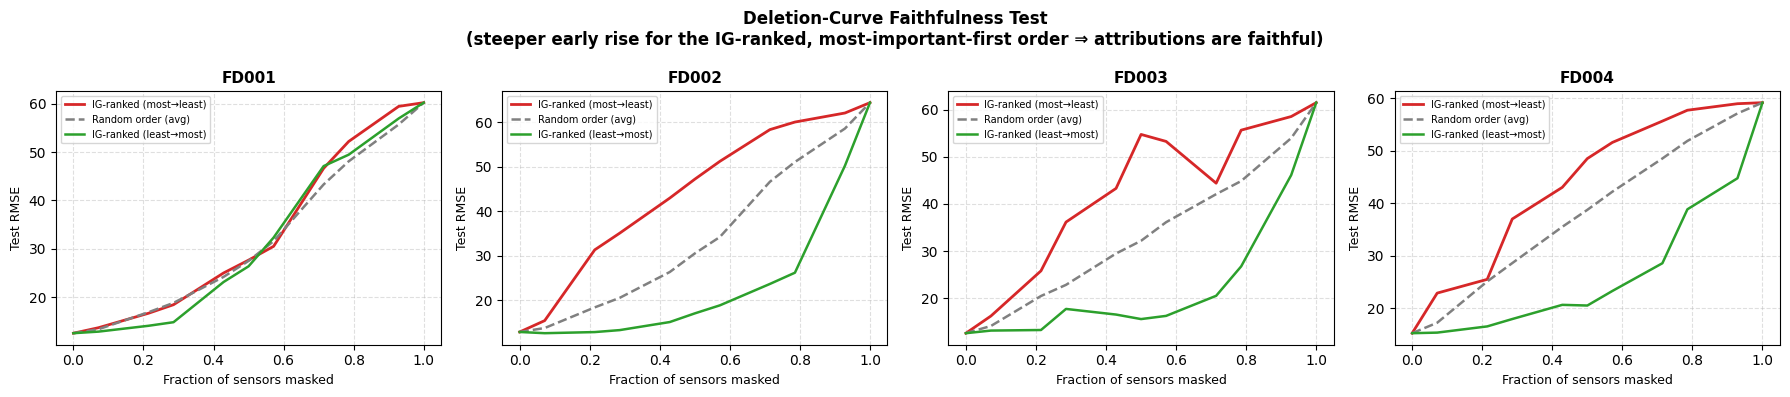

Saved -> explainability_deletion_curves.png


In [28]:
# ══════════════════════════════════════════════════════════════════════
# 14b. PLOT — Deletion curves: IG-ranked vs random vs reversed order
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for ax, ds in zip(axes, DATASETS):
    model  = all_models[ds]
    config = DATASET_CONFIGS[ds]

    train_df_tmp, test_df_tmp, y_test_tmp = load_data(ds)
    train_df_tmp = add_rul(train_df_tmp)
    train_df_tmp, test_df_tmp, _ = scale_data_strict(train_df_tmp, test_df_tmp, config)
    test_df_tmp = apply_smoothing(test_df_tmp, config['alpha'])
    X_test = prepare_test(test_df_tmp, config['seq_length'])
    y_true = np.clip(y_test_tmp['RUL'].values, 0, 125)
    np.random.seed(ATTR_SEED)
    idx = np.random.choice(len(X_test), min(N_SAMPLES, len(X_test)), replace=False)
    X_sub, y_sub = X_test[idx].astype(np.float32), y_true[idx]

    ig_importance = np.abs(attr_store[ds]).mean(axis=(0, 1))
    ig_order = np.argsort(ig_importance)[::-1]
    fracs_ig, rmses_ig, _ = deletion_curve(model, X_sub, y_sub, ig_order)
    fracs_lo, rmses_lo, _ = deletion_curve(model, X_sub, y_sub, ig_order[::-1])

    rng = np.random.RandomState(ATTR_SEED)
    rand_curves = [
        deletion_curve(model, X_sub, y_sub, rng.permutation(len(features)))[1]
        for _ in range(N_RANDOM_CONTROLS)
    ]
    rand_mean = np.mean(rand_curves, axis=0)

    ax.plot(fracs_ig, rmses_ig, color='#d62728', linewidth=2, label='IG-ranked (most→least)')
    ax.plot(fracs_ig, rand_mean, color='gray', linestyle='--', linewidth=1.8, label='Random order (avg)')
    ax.plot(fracs_lo, rmses_lo, color='#2ca02c', linewidth=1.8, label='IG-ranked (least→most)')
    ax.set_title(ds, fontsize=11, fontweight='bold')
    ax.set_xlabel('Fraction of sensors masked', fontsize=9)
    ax.set_ylabel('Test RMSE', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=7)

fig.suptitle(
    'Deletion-Curve Faithfulness Test\n'
    '(steeper early rise for the IG-ranked, most-important-first order ⇒ attributions are faithful)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('explainability_deletion_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved -> explainability_deletion_curves.png")
